# 광고 클릭률(CTR) 예측 — 통합 분석 노트북
**통계 졸업논문 | 토스 NEXT ML Challenge**

---

## 목차
1. [환경 설정 & 데이터 로드](#sec1)
2. [탐색적 데이터 분석 (EDA)](#sec2)
3. [통계 검정 — 연구 질문 RQ1~RQ4](#sec3)
4. [피처 엔지니어링](#sec4)
5. [상관관계 분석](#sec5)
6. [모델링](#sec6)
   - 6a. 로지스틱 회귀
   - 6b. XGBoost + SHAP
7. [PCA & 클러스터링](#sec7)
8. [보조 검증](#sec8)
9. [추론](#sec9)
10. [PCA & 클러스터링](#sec10)
11. [보조 검증](#sec11)

---
## 1. 환경 설정 & 데이터 로드 <a id='sec1'></a>

In [52]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # 로컬 Jupyter / VS Code


**Google Colab 사용 시:**  
Drive 마운트 후 `static_document_dataset.zip` 파일 경로를 확인하고, 다음 셀의 `ZIP_FILE_PATH` 변수를 해당 경로로 수정한 뒤 압축 해제 셀을 실행해 주세요.

In [53]:
'''# 한글 폰트 문제 해결을 위한 설정 코드
import matplotlib.font_manager as fm
import platform
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 기본 스타일 설정
plt.style.use('default')
sns.set_palette("husl")

def setup_korean_font():
    """운영체제별 한글 폰트 설정"""
    
    # 운영체제별 한글 폰트 리스트
    korean_fonts = {
        'Windows': [
            'Malgun Gothic',
            'Microsoft YaHei', 
            'SimHei',
            'NanumGothic',
            'NanumBarunGothic'
        ],
        'Darwin': [  # macOS
            'AppleGothic',
            'Apple SD Gothic Neo',
            'NanumGothic',
            'NanumBarunGothic'
        ],
        'Linux': [
            'DejaVu Sans',
            'NanumGothic',
            'NanumBarunGothic',
            'UnDotum'
        ]
    }
    
    # 시스템에 설치된 폰트 목록
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    # 운영체제에 맞는 한글 폰트 찾기
    system = platform.system()
    fonts_to_try = korean_fonts.get(system, korean_fonts['Linux'])
    
    found_font = None
    for font in fonts_to_try:'''

'# 한글 폰트 문제 해결을 위한 설정 코드\nimport matplotlib.font_manager as fm\nimport platform\nimport os\n\nimport pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom datetime import datetime\nimport warnings\nwarnings.filterwarnings(\'ignore\')\n\n# 기본 스타일 설정\nplt.style.use(\'default\')\nsns.set_palette("husl")\n\ndef setup_korean_font():\n    """운영체제별 한글 폰트 설정"""\n    \n    # 운영체제별 한글 폰트 리스트\n    korean_fonts = {\n        \'Windows\': [\n            \'Malgun Gothic\',\n            \'Microsoft YaHei\', \n            \'SimHei\',\n            \'NanumGothic\',\n            \'NanumBarunGothic\'\n        ],\n        \'Darwin\': [  # macOS\n            \'AppleGothic\',\n            \'Apple SD Gothic Neo\',\n            \'NanumGothic\',\n            \'NanumBarunGothic\'\n        ],\n        \'Linux\': [\n            \'DejaVu Sans\',\n            \'NanumGothic\',\n            \'NanumBarunGothic\',\n            \'UnDotum\'\n        ]\n    }\n    \n    # 시스템에 설치된 폰트

In [54]:
import pandas as pd
from pathlib import Path

def _find_sample_submission() -> Path:
    for root in (Path.cwd(), Path.cwd().parent):
        p = root / "data" / "sample_submission.csv"
        if p.exists():
            return p
    return Path("static_document_dataset/sample_submission.csv")

sample = pd.read_csv(_find_sample_submission())


In [55]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from pathlib import Path

BASE_DIR = Path('..')
TRAIN_SAMPLE_PATH = BASE_DIR / 'data' / 'train_sample.parquet'
TRAIN_PATH = BASE_DIR / 'data' / 'train.parquet'
TEST_PATH = BASE_DIR / 'data' / 'test.parquet'

SAMPLE_SIZE = 200_000
RANDOM_STATE = 42
BATCH_SIZE = 100_000

# data/train_sample.parquet이 없으면 train.parquet에서 20만 샘플 생성
if TRAIN_SAMPLE_PATH.exists():
    print(f"[SKIP] Existing sample found: {TRAIN_SAMPLE_PATH}")
else:
    if not TRAIN_PATH.exists():
        raise FileNotFoundError(f"train.parquet not found: {TRAIN_PATH}")

    print(f"[CREATE] Building sample at: {TRAIN_SAMPLE_PATH}")
    rng = np.random.default_rng(RANDOM_STATE)
    pf = pq.ParquetFile(str(TRAIN_PATH))

    reservoir = None
    total_rows = 0

    # 배치별 랜덤 키를 부여하고 상위 키만 유지해 전체에서 균일 샘플링
    for batch in pf.iter_batches(batch_size=BATCH_SIZE):
        chunk = batch.to_pandas()
        total_rows += len(chunk)
        chunk['_rand_key'] = rng.random(len(chunk))

        if reservoir is None:
            reservoir = chunk
        else:
            reservoir = pd.concat([reservoir, chunk], ignore_index=True)

        if len(reservoir) > SAMPLE_SIZE * 3:
            reservoir = reservoir.nlargest(SAMPLE_SIZE, '_rand_key')

    if reservoir is None or len(reservoir) == 0:
        raise RuntimeError(f"No rows read from {TRAIN_PATH}")

    n = min(SAMPLE_SIZE, len(reservoir))
    train_sample = reservoir.nlargest(n, '_rand_key').drop(columns=['_rand_key'])
    train_sample = train_sample.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

    TRAIN_SAMPLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    train_sample.to_parquet(TRAIN_SAMPLE_PATH, index=False)
    print(f"[DONE] Saved {n:,} rows with random_state={RANDOM_STATE} (from total {total_rows:,} rows)")

# 항상 data/train_sample.parquet에서 로드
train = pd.read_parquet(TRAIN_SAMPLE_PATH)
train['clicked'] = train['clicked'].astype(int)
df = train.copy()  # thesis 셀 호환용 별칭

print(f"TRAIN_SAMPLE_PATH: {TRAIN_SAMPLE_PATH}")
print(f"train shape      : {train.shape}")
print(f"CTR              : {train['clicked'].mean():.4f}")
print(f"columns          : {list(train.columns[:10])} ...")

[SKIP] Existing sample found: ..\data\train_sample.parquet
TRAIN_SAMPLE_PATH: ..\data\train_sample.parquet
train shape      : (200000, 119)
CTR              : 0.0190
columns          : ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour', 'seq', 'l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4'] ...


---
## 2. 탐색적 데이터 분석 (EDA) <a id='sec2'></a>


🎯 타깃 변수 분석 (clicked)
📈 전체 클릭률: 0.0190 (1.90%)
🔢 총 클릭 수: 3,804 / 200,000
⚖️ 클래스 불균형 비율: 51.6:1 (비클릭:클릭)


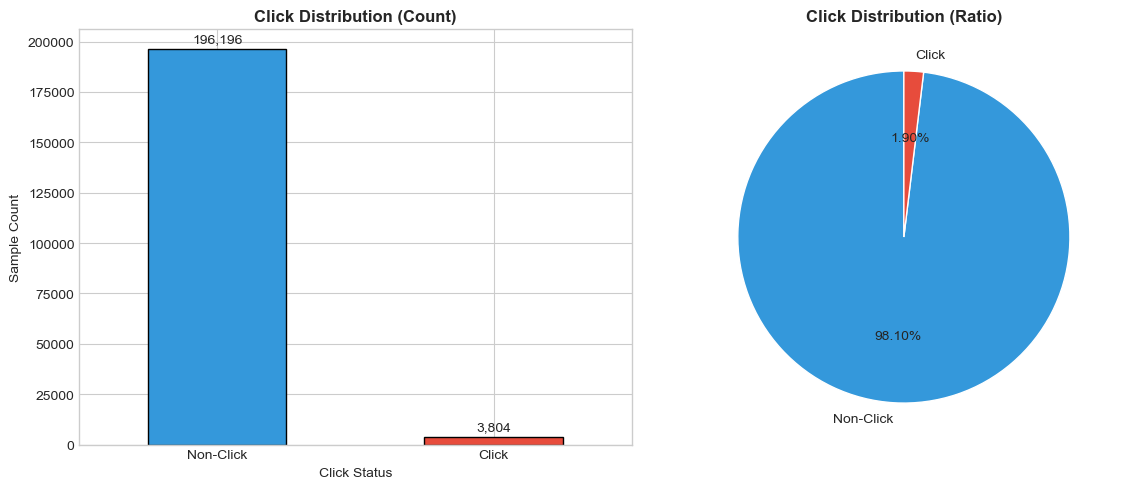


[결론]
- 심각한 클래스 불균형: 51.6:1
- 모델 학습 시 이 불균형을 고려해야 함 (가중치 조정, 샘플링 기법 활용)


In [56]:
# ========================================
# 🎯 2. 타깃 변수 분석 (clicked)
# ========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 60)
print("🎯 타깃 변수 분석 (clicked)")
print("=" * 60)

# CTR Calculation
click_rate = df['clicked'].mean()
total_clicks = df['clicked'].sum()
total_samples = len(df)

print(f"📈 전체 클릭률: {click_rate:.4f} ({click_rate * 100:.2f}%)")
print(f"🔢 총 클릭 수: {total_clicks:,} / {total_samples:,}")

if click_rate != 0:
    print(f"⚖️ 클래스 불균형 비율: {(1 - click_rate) / click_rate:.1f}:1 (비클릭:클릭)")
else:
    print("⚖️ 클래스 불균형 비율: 클릭 데이터가 없어 계산할 수 없습니다.")

# 타겟 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# clicked 값 정리
click_counts = df['clicked'].value_counts().sort_index()

# Click Distribution (Count)
click_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Click Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Click Status')
axes[0].set_ylabel('Sample Count')
axes[0].set_xticklabels(['Non-Click', 'Click'], rotation=0)
for i, (idx, val) in enumerate(click_counts.items()):
    axes[0].text(i, val + max(click_counts)*0.01, f'{val:,}', ha='center', va='bottom')

# Click Distribution (Ratio) - Pie Chart
sizes = click_counts.values
labels = ['Non-Click', 'Click']
colors = ['#3498db', '#e74c3c']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
axes[1].set_title('Click Distribution (Ratio)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n[결론]")
print(f"- 심각한 클래스 불균형: {(1-click_rate)/click_rate:.1f}:1")
print(f"- 모델 학습 시 이 불균형을 고려해야 함 (가중치 조정, 샘플링 기법 활용)")

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

train_sample = train.copy()
train_sample_processed = train.copy()
click_col    = 'clicked'
click_series = train_sample[click_col]

print(f'데이터 크기: {train_sample.shape}')
print(f'CTR: {train_sample[click_col].mean():.4f} ({train_sample[click_col].sum():,}건 / {len(train_sample):,}건)')

데이터 크기: (200000, 119)
CTR: 0.0190 (3,804건 / 200,000건)


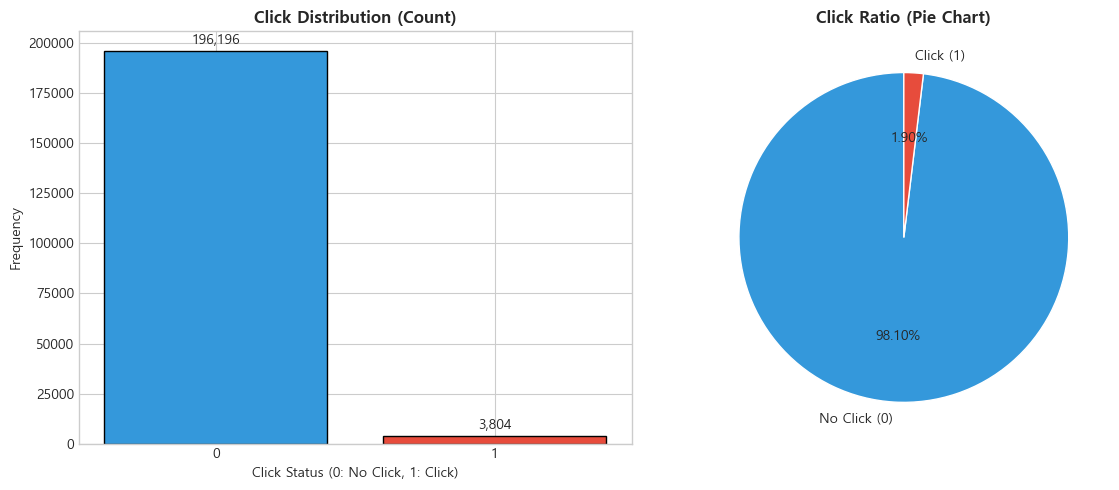

In [58]:
# Click 분포: Bar chart (Count) & Pie chart (Ratio)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 빈도수 바 차트
click_counts = click_series.value_counts().sort_index()
bars = axes[0].bar(click_counts.index.astype(str), click_counts.values, 
                   color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Click Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Click Status (0: No Click, 1: Click)')
axes[0].set_ylabel('Frequency')
for bar, val in zip(bars, click_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(click_counts)*0.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
sizes = click_counts.values
labels = ['No Click (0)', 'Click (1)']
colors = ['#3498db', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%',
                                        startangle=90)
axes[1].set_title('Click Ratio (Pie Chart)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

- ✅ CTR 1.98% (불균형 데이터)로 기본 통계 및 다중 시각화 완료
- 🔍 추가 EDA: gender×age, day×hour별 CTR 및 상관관계/이상치 분석 예정
- 🧩 피처 엔지니어링: 시간대·주중여부·상호작용 피처 생성 계획
- 🤖 모델링: Logistic→LightGBM/XGBoost 등과 불균형 처리 수행 예정
- 🎯 목표: 피처별 CTR 히트맵·상관관계 분석 완료 후 AUC 0.75+ 달성

# Task: CTR 종합 분석

사용자 특성(성별, 연령대) 및 시간적 요인(시간대, 요일)에 기반한 클릭률(CTR) 분석을 수행합니다.  
시간 기반 피처 엔지니어링(예: hour→시간대, day_of_week→평일/주말), 상관관계 히트맵 분석, `train_sample.parquet`를 이용한 베이스라인 로지스틱 회귀 모델 구현 및 불균형 데이터에 적합한 지표로 성능 평가를 진행합니다.

## 사용자 특성별 CTR 분석

### 목표
성별(gender) 및 연령대(age_group)에 따른 클릭률(CTR) 분포를 분석합니다. 각 사용자 특성 그룹별 CTR을 계산하고 시각화하여 주요 인사이트를 도출합니다.


### 접근 방법
`train_sample` DataFrame에서 'gender'와 'age_group'별 Click-Through Rate(CTR)를 계산합니다. 클릭 여부를 나타내는 'clicked' 컬럼(1: 클릭, 0: 비클릭)을 사용하여 각 그룹별 평균을 산출합니다.



CTR by Gender:
  gender       CTR
0    1.0  0.019261
1    2.0  0.018547

CTR by Age Group:
  age_group       CTR
0       1.0  0.089354
1       2.0  0.023781
2       3.0  0.021665
3       4.0  0.017396
4       5.0  0.017240
5       6.0  0.015424
6       7.0  0.016994
7       8.0  0.023759


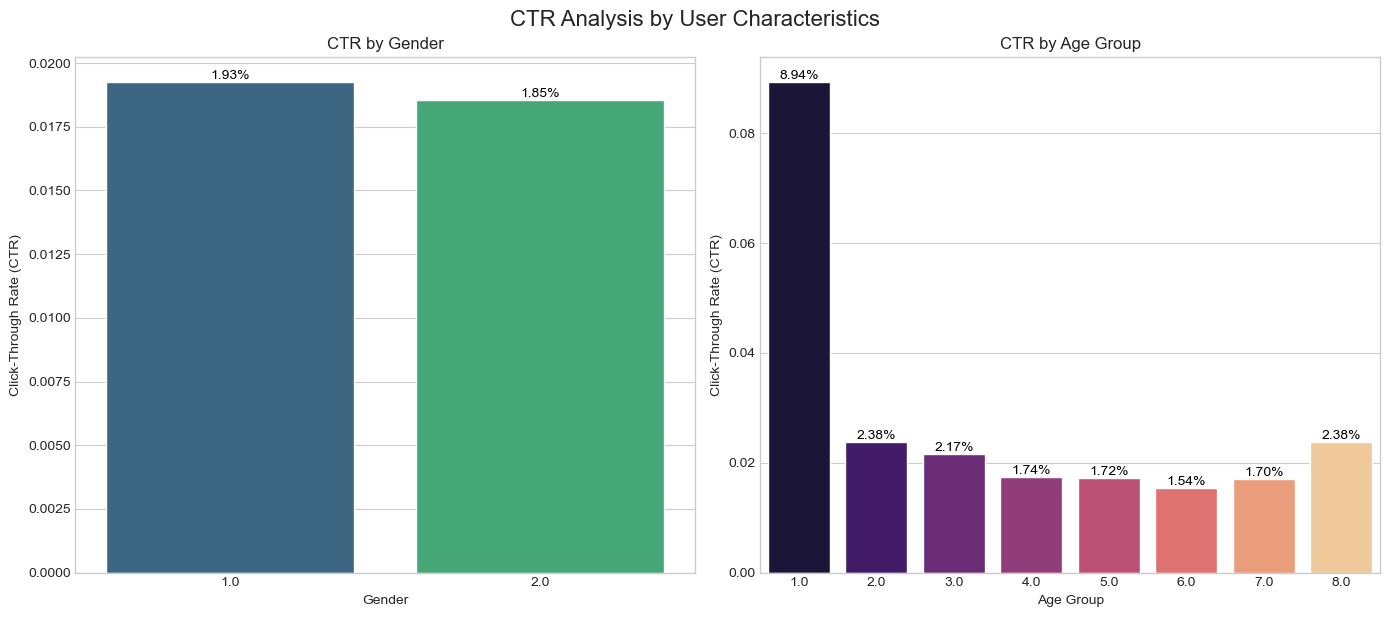

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 'clicked' 컬럼을 int형으로 변환하여 일관된 계산 보장
train_sample_processed = train_sample.copy()
train_sample_processed['clicked'] = train_sample_processed['clicked'].astype(int)

# 1. 성별에 따른 CTR 계산
gender_ctr = train_sample_processed.groupby('gender')['clicked'].mean().reset_index()
gender_ctr.columns = ['gender', 'CTR']

# 2. 연령대에 따른 CTR 계산
age_group_ctr = train_sample_processed.groupby('age_group')['clicked'].mean().reset_index()
age_group_ctr.columns = ['age_group', 'CTR']

print("CTR by Gender:")
print(gender_ctr)
print("\nCTR by Age Group:")
print(age_group_ctr)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 3. 성별 ctr 플롯
sns.barplot(x='gender', y='CTR', data=gender_ctr, hue='gender', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('CTR by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Click-Through Rate (CTR)')
for index, row in gender_ctr.iterrows():
    axes[0].text(index, row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom")

# 4. 연령 그룹 ctr 플롯
sns.barplot(x='age_group', y='CTR', data=age_group_ctr, hue='age_group', palette='magma', ax=axes[1], legend=False)
axes[1].set_title('CTR by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Click-Through Rate (CTR)')
for index, row in age_group_ctr.iterrows():
    axes[1].text(index, row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom")

# 5. 플롯 배치
plt.tight_layout()
plt.suptitle('CTR Analysis by User Characteristics', y=1.02, fontsize=16)
plt.show()


RQ1: Age Group vs CTR — Statistical Tests
One-way ANOVA:   F=37.1173, p=0.000000 ***
Kruskal-Wallis:  H=259.4922, p=0.000000 ***
Effect size eta2=0.001296  (small(<0.06) — Cohen 1988)

Tukey HSD 사후 검정 (age_group):
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   1.0    2.0  -0.0656    0.0 -0.0843 -0.0469   True
   1.0    3.0  -0.0677    0.0 -0.0862 -0.0491   True
   1.0    4.0   -0.072    0.0 -0.0904 -0.0535   True
   1.0    5.0  -0.0721    0.0 -0.0906 -0.0537   True
   1.0    6.0  -0.0739    0.0 -0.0921 -0.0558   True
   1.0    7.0  -0.0724    0.0 -0.0905 -0.0543   True
   1.0    8.0  -0.0656    0.0 -0.0837 -0.0475   True
   2.0    3.0  -0.0021 0.9792 -0.0088  0.0045  False
   2.0    4.0  -0.0064  0.057 -0.0129  0.0001  False
   2.0    5.0  -0.0065 0.0401 -0.0129 -0.0002   True
   2.0    6.0  -0.0084 0.0001 -0.0138 -0.0029   True
   2.0    7.0  -0.0068 0.0025 -0.0121 -0.001

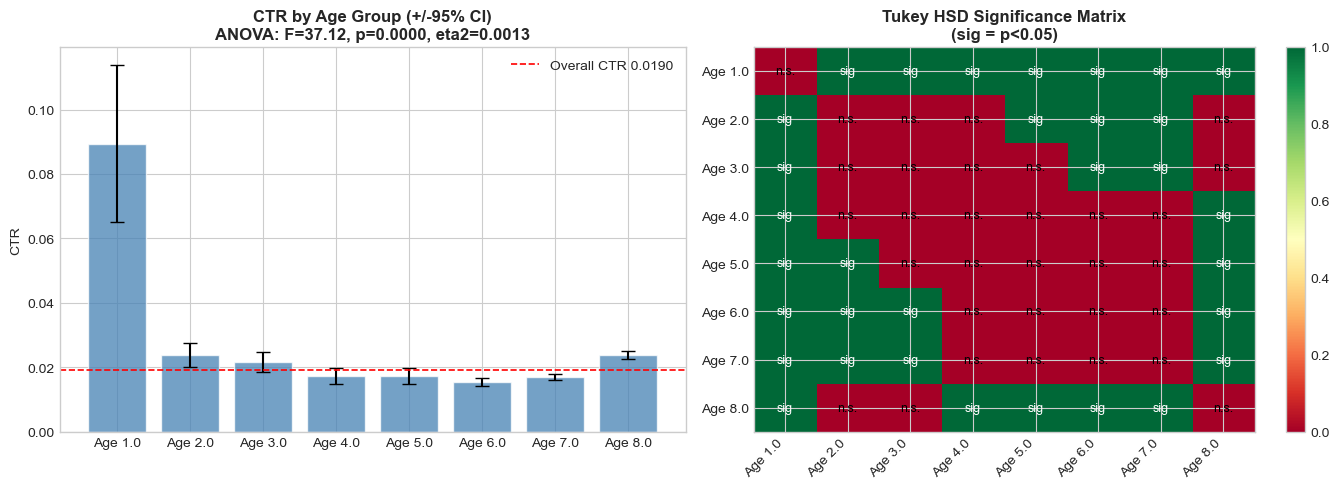


결론: 연령대별 CTR 차이는 통계적으로 유의함 (p<0.001)
실질적 효과 크기 eta2=0.0013 — 작음 (실질적 영향 제한적)
성별 효과 Cramer's V=0.0025 — 무시 가능


In [60]:
# ================================================================
# 통계 검정 — 사용자 특성 (연령대 & 성별)
# 효과 크기: eta-squared (ANOVA), Cramer's V (카이제곱)
# ================================================================
from scipy.stats import f_oneway, kruskal, chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GLOBAL_CTR_STAT = train_sample_processed['clicked'].mean()

# ── 연령대: 일원분산분석 + 크루스칼-왈리스 + eta-squared ─────
age_groups_list = sorted(train_sample_processed['age_group'].dropna().unique())
age_samples_stat = [
    train_sample_processed[train_sample_processed['age_group'] == ag]['clicked'].values
    for ag in age_groups_list
]
F_age_stat, p_anova_age_stat = f_oneway(*age_samples_stat)
H_age_stat, p_kruskal_age_stat = kruskal(*age_samples_stat)

# eta^2 = SS_between / SS_total
grand_mean_stat = GLOBAL_CTR_STAT
ss_total_stat = ((train_sample_processed['clicked'] - grand_mean_stat) ** 2).sum()
ss_between_age = sum(len(s) * (s.mean() - grand_mean_stat) ** 2 for s in age_samples_stat if len(s) > 0)
eta_sq_age = ss_between_age / ss_total_stat

print("=" * 60)
print("RQ1: Age Group vs CTR — Statistical Tests")
print("=" * 60)
print(f"One-way ANOVA:   F={F_age_stat:.4f}, p={p_anova_age_stat:.6f} "
      f"{'***' if p_anova_age_stat<0.001 else '**' if p_anova_age_stat<0.01 else '*' if p_anova_age_stat<0.05 else 'n.s.'}")
print(f"Kruskal-Wallis:  H={H_age_stat:.4f}, p={p_kruskal_age_stat:.6f} "
      f"{'***' if p_kruskal_age_stat<0.001 else 'n.s.'}")
print(f"Effect size eta2={eta_sq_age:.6f}  "
      f"({'large(>=0.14)' if eta_sq_age>=0.14 else 'medium(>=0.06)' if eta_sq_age>=0.06 else 'small(<0.06)'} — Cohen 1988)")


# Tukey HSD 사후 검정
valid_age_mask = train_sample_processed['age_group'].notna() & train_sample_processed['clicked'].notna()
tukey_age_res = pairwise_tukeyhsd(
    endog=train_sample_processed.loc[valid_age_mask, 'clicked'],
    groups=train_sample_processed.loc[valid_age_mask, 'age_group'],
    alpha=0.05
)
print("\nTukey HSD 사후 검정 (age_group):")
print(tukey_age_res.summary())

# ── 성별: 카이제곱 + Cramer's V ─────────────────────────────
ct_gender = pd.crosstab(train_sample_processed['gender'], train_sample_processed['clicked'])
chi2_gender, p_chi2_gender, _, _ = chi2_contingency(ct_gender)
n_total_gender = ct_gender.values.sum()
cramers_v_gender = np.sqrt(chi2_gender / (n_total_gender * (min(ct_gender.shape) - 1)))

print("\n" + "=" * 60)
print("RQ1: Gender vs CTR — 카이제곱 + Cramer's V")
print("=" * 60)
print(f"카이제곱 검정: chi2={chi2_gender:.4f}, p={p_chi2_gender:.6f} "
      f"{'***' if p_chi2_gender<0.001 else '유의하지 않음'}")
print(f"Cramer's V: {cramers_v_gender:.6f}  "
      f"({'큼(>=0.5)' if cramers_v_gender>=0.5 else '중간(>=0.3)' if cramers_v_gender>=0.3 else '작음(<0.3)'})")


# ── 시각화: 신뢰구간 막대그래프 + Tukey 유의성 히트맵 ──────────
age_desc = train_sample_processed.groupby('age_group')['clicked'].agg(
    n='count', ctr='mean', std='std'
).reset_index()
age_desc['ci95'] = 1.96 * (age_desc['std'] / np.sqrt(age_desc['n']))

n_ag = len(age_groups_list)
sig_mat = np.zeros((n_ag, n_ag))
for row in tukey_age_res.summary().data[1:]:
    g1, g2, *_, reject = row
    try:
        i = list(age_groups_list).index(g1)
        j = list(age_groups_list).index(g2)
        sig_mat[i, j] = sig_mat[j, i] = 1 if reject else 0
    except ValueError:
        pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(n_ag)
axes[0].bar(x_pos, age_desc['ctr'], color='steelblue', alpha=0.75)
axes[0].errorbar(x_pos, age_desc['ctr'],
                 yerr=age_desc['ci95'], fmt='none', color='black', capsize=5)
axes[0].axhline(GLOBAL_CTR_STAT, color='red', linestyle='--', linewidth=1.2,
                label=f'Overall CTR {GLOBAL_CTR_STAT:.4f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'Age {ag}' for ag in age_groups_list])
axes[0].set_title(
    f'CTR by Age Group (+/-95% CI)\n'
    f'ANOVA: F={F_age_stat:.2f}, p={p_anova_age_stat:.4f}, eta2={eta_sq_age:.4f}',
    fontweight='bold')
axes[0].set_ylabel('CTR')
axes[0].legend()

im = axes[1].imshow(sig_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_xticks(range(n_ag))
axes[1].set_yticks(range(n_ag))
axes[1].set_xticklabels([f'Age {ag}' for ag in age_groups_list], rotation=45, ha='right')
axes[1].set_yticklabels([f'Age {ag}' for ag in age_groups_list])
for i in range(n_ag):
    for j in range(n_ag):
        axes[1].text(j, i, 'sig' if sig_mat[i, j] else 'n.s.',
                     ha='center', va='center', fontsize=9,
                     color='white' if sig_mat[i, j] else 'black')
axes[1].set_title('Tukey HSD Significance Matrix\n(sig = p<0.05)', fontweight='bold')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('RQ1_user_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n결론: 연령대별 CTR 차이는 "
      f"{'통계적으로 유의함 (p<0.001)' if p_anova_age_stat<0.001 else '통계적으로 유의하지 않음'}")
print(f"실질적 효과 크기 eta2={eta_sq_age:.4f} — "
      f"{'작음 (실질적 영향 제한적)' if eta_sq_age<0.06 else '중간' if eta_sq_age<0.14 else '큼'}")
print(f"성별 효과 Cramer's V={cramers_v_gender:.4f} — "
      f"{'무시 가능' if cramers_v_gender<0.1 else '작음' if cramers_v_gender<0.3 else '중간'}")

## 시간대 및 요일별 CTR 분석

### 목표
시간(hour)과 요일(day_of_week)에 따른 클릭률(CTR) 변화를 분석합니다. 시간대별, 요일별 CTR을 계산하고 시각화하여 트렌드를 파악합니다.


### 접근 방법
`train_sample` DataFrame에서 'hour'와 'day_of_week'별 'clicked' 컬럼의 평균을 계산합니다. 이어서 두 개의 서브플롯으로 시각화하고, 가독성을 위해 각 막대에 CTR 값을 표시합니다.



CTR by Hour:
   hour       CTR
0     0  0.015655
1     1  0.018351
2     2  0.029366
3     3  0.021195
4     4  0.019893

CTR by Day of Week:
   day_of_week       CTR
0            1  0.016633
1            2  0.021162
2            3  0.019020
3            4  0.018828
4            5  0.020285


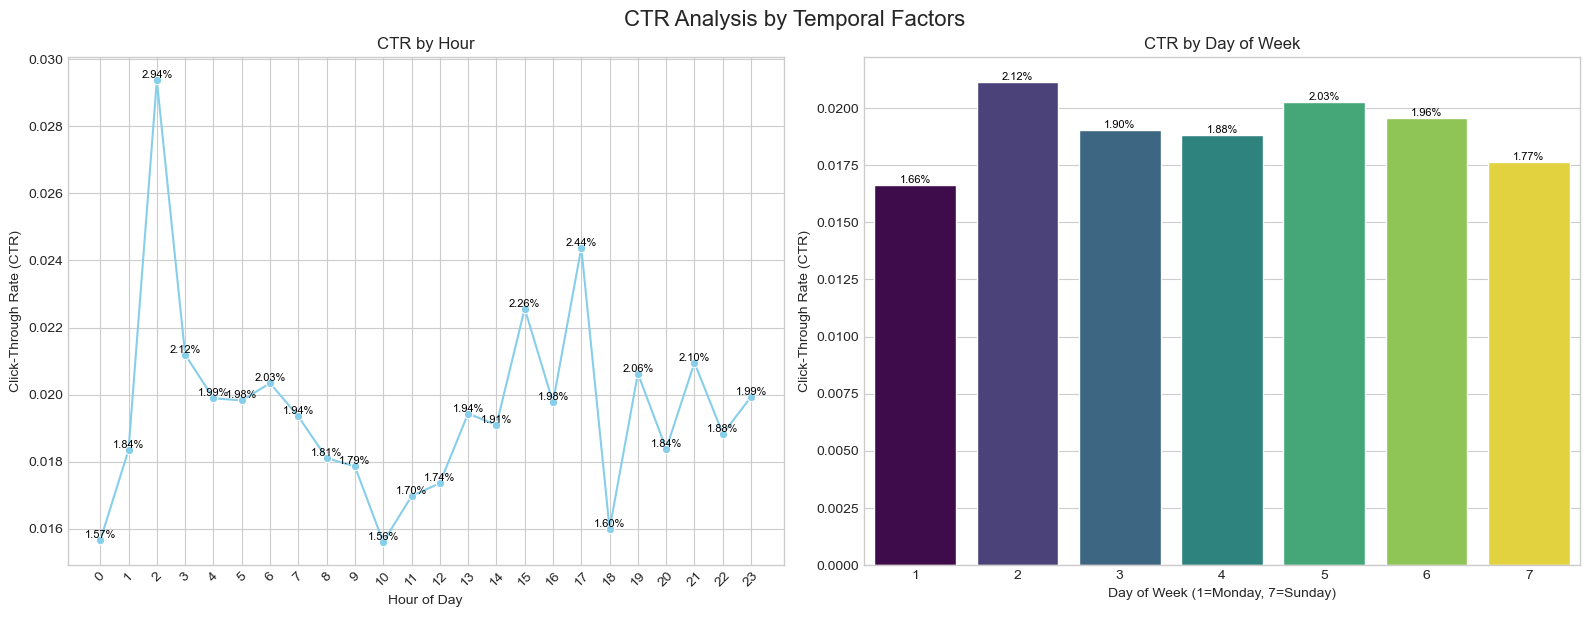

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 일관된 계산을 위해 'clicked' 컬럼을 정수형(int)으로 변환
train_sample_processed = train_sample.copy()
train_sample_processed['clicked'] = train_sample_processed['clicked'].astype(int)

# 1. 시간별 CTR 계산
hour_ctr = train_sample_processed.groupby('hour')['clicked'].mean().reset_index()
hour_ctr.columns = ['hour', 'CTR']
hour_ctr['hour'] = hour_ctr['hour'].astype(int) # Explicitly convert 'hour' to int

# 2. 요일별 CTR 계산
day_of_week_ctr = train_sample_processed.groupby('day_of_week')['clicked'].mean().reset_index()
day_of_week_ctr.columns = ['day_of_week', 'CTR']
day_of_week_ctr['day_of_week'] = day_of_week_ctr['day_of_week'].astype(int) # Explicitly convert 'day_of_week' to int

print("CTR by Hour:")
print(hour_ctr.head())
print("\nCTR by Day of Week:")
print(day_of_week_ctr.head())

# 두 서브플롯으로 figure 만들기
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. 시간 CTR 차트
sns.lineplot(x='hour', y='CTR', data=hour_ctr, marker='o', ax=axes[0], color='skyblue')
axes[0].set_title('CTR by Hour', fontsize=12)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Click-Through Rate (CTR)')
axes[0].set_xticks(hour_ctr['hour'])
axes[0].tick_params(axis='x', rotation=45)
for index, row in hour_ctr.iterrows():
    axes[0].text(row['hour'], row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom", fontsize=8)

# 4. 요일별 CTR 시각화
sns.barplot(x='day_of_week', y='CTR', data=day_of_week_ctr, hue='day_of_week', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('CTR by Day of Week', fontsize=12)
axes[1].set_xlabel('Day of Week (1=Monday, 7=Sunday)')
axes[1].set_ylabel('Click-Through Rate (CTR)')
for index, row in day_of_week_ctr.iterrows():
    axes[1].text(index, row['CTR'], f"{row['CTR']:.2%}", color='black', ha="center", va="bottom", fontsize=8)

# 5. 시각화 배치
plt.tight_layout()
plt.suptitle('CTR Analysis by Temporal Factors', y=1.02, fontsize=16)
plt.show()

RQ2: Hour vs CTR — Statistical Tests
One-way ANOVA: F=2.5149, p=0.000078 ***
Effect size eta2=0.000289  (small(<0.06))

Time Period (4 groups) ANOVA: F=1.5401, p=0.201800 n.s.

Tukey HSD post-hoc (time period):
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2     meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------
Afternoon(12-16) Evening(17-20)   0.0003 0.9906 -0.0021 0.0027  False
Afternoon(12-16)  Morning(5-11)  -0.0013 0.3961 -0.0034 0.0008  False
Afternoon(12-16)    Night(21-4)  -0.0001 0.9996 -0.0024 0.0022  False
  Evening(17-20)  Morning(5-11)  -0.0016 0.2555 -0.0038 0.0006  False
  Evening(17-20)    Night(21-4)  -0.0004 0.9781 -0.0028  0.002  False
   Morning(5-11)    Night(21-4)   0.0012 0.4611 -0.0009 0.0033  False
---------------------------------------------------------------------

RQ3: 요일 vs CTR — 통계 검정
일원분산분석: F=3.5898, p=0.001468 유의하지 않음
효과 크기 eta2=0.000108  (작음(<0.

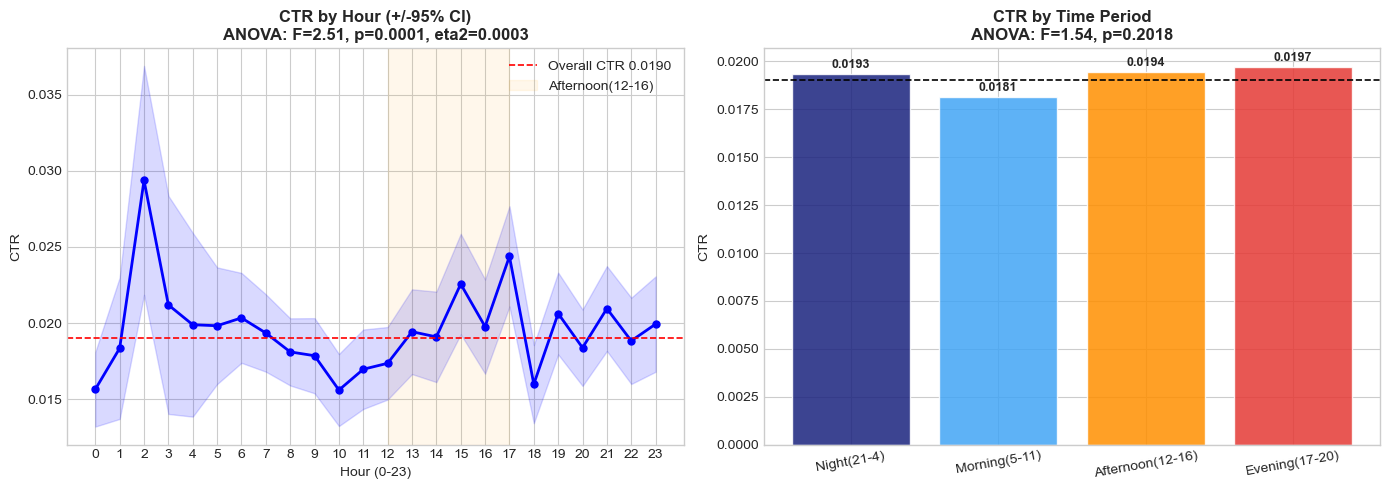


결론:
  시간  -> eta2=0.0003 — 유의미함 시간 효과
  요일  -> eta2=0.0001 — 유의하지 않음 요일 효과


In [62]:
# ================================================================
# 통계 검정 — 시간적 요인 (시간 & 요일)
# 효과 크기: eta-squared, Tukey HSD 사후 검정
# ================================================================
from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

grand_mean_temp = train_sample_processed['clicked'].mean()
ss_total_temp = ((train_sample_processed['clicked'] - grand_mean_temp) ** 2).sum()

# ── 시간: One-way ANOVA + eta-squared ───────────────────────────
hour_vals = sorted(train_sample_processed['hour'].dropna().unique())
hour_samples_t = [
    train_sample_processed[train_sample_processed['hour'] == h]['clicked'].values
    for h in hour_vals
]
F_hour_t, p_hour_t = f_oneway(*hour_samples_t)
ss_between_h = sum(len(s) * (s.mean() - grand_mean_temp) ** 2 for s in hour_samples_t if len(s) > 0)
eta_sq_hour = ss_between_h / ss_total_temp

print("=" * 60)
print("RQ2: Hour vs CTR — Statistical Tests")
print("=" * 60)
print(f"One-way ANOVA: F={F_hour_t:.4f}, p={p_hour_t:.6f} "
      f"{'***' if p_hour_t<0.001 else '**' if p_hour_t<0.01 else '*' if p_hour_t<0.05 else 'n.s.'}")
print(f"Effect size eta2={eta_sq_hour:.6f}  "
      f"({'large(>=0.14)' if eta_sq_hour>=0.14 else 'medium(>=0.06)' if eta_sq_hour>=0.06 else 'small(<0.06)'})")

# Time period (4 buckets): Tukey HSD
def _get_period_label(h):
    if 5 <= h < 12:    return 'Morning(5-11)'
    elif 12 <= h < 17: return 'Afternoon(12-16)'
    elif 17 <= h < 21: return 'Evening(17-20)'
    else:              return 'Night(21-4)'

period_col = train_sample_processed['hour'].astype(int).apply(_get_period_label)
tod_df_stat = pd.DataFrame({'period': period_col, 'clicked': train_sample_processed['clicked']})
period_uniq = tod_df_stat['period'].unique()
period_samples_t = [tod_df_stat[tod_df_stat['period'] == p]['clicked'].values for p in period_uniq]
F_period_t, p_period_t = f_oneway(*period_samples_t)

tukey_period_res = pairwise_tukeyhsd(
    endog=tod_df_stat['clicked'], groups=tod_df_stat['period'], alpha=0.05
)
print(f"\nTime Period (4 groups) ANOVA: F={F_period_t:.4f}, p={p_period_t:.6f} "
      f"{'***' if p_period_t<0.001 else 'n.s.'}")
print("\nTukey HSD post-hoc (time period):")
print(tukey_period_res.summary())

# ── 요일: One-way ANOVA + eta-squared ────────────────────
dow_vals = sorted(train_sample_processed['day_of_week'].dropna().unique())
dow_samples_t = [
    train_sample_processed[train_sample_processed['day_of_week'] == d]['clicked'].values
    for d in dow_vals
]
F_dow_t, p_dow_t = f_oneway(*dow_samples_t)
ss_between_d = sum(len(s) * (s.mean() - grand_mean_temp) ** 2 for s in dow_samples_t if len(s) > 0)
eta_sq_dow = ss_between_d / ss_total_temp

print("\n" + "=" * 60)
print("RQ3: 요일 vs CTR — 통계 검정")
print("=" * 60)
print(f"일원분산분석: F={F_dow_t:.4f}, p={p_dow_t:.6f} "
      f"{'***' if p_dow_t<0.001 else '유의하지 않음'}")
print(f"효과 크기 eta2={eta_sq_dow:.6f}  "
      f"({'큼(>=0.14)' if eta_sq_dow>=0.14 else '중간(>=0.06)' if eta_sq_dow>=0.06 else '작음(<0.06)'})")

# ── 시각화 ────────────────────────────────────────────────
hour_desc = train_sample_processed.groupby('hour')['clicked'].agg(
    n='count', ctr='mean', std='std'
).reset_index()
hour_desc['ci95'] = 1.96 * (hour_desc['std'] / np.sqrt(hour_desc['n']))
h_vals_plot = hour_desc['hour'].astype(int).tolist()

period_order = ['Night(21-4)', 'Morning(5-11)', 'Afternoon(12-16)', 'Evening(17-20)']
period_ctr = tod_df_stat.groupby('period')['clicked'].mean().reindex(period_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h_vals_plot, hour_desc['ctr'], 'b-o', linewidth=2, markersize=5)
axes[0].fill_between(h_vals_plot,
                     hour_desc['ctr'] - hour_desc['ci95'],
                     hour_desc['ctr'] + hour_desc['ci95'],
                     alpha=0.15, color='blue')
axes[0].axhline(grand_mean_temp, color='red', linestyle='--', linewidth=1.2,
                label=f'Overall CTR {grand_mean_temp:.4f}')
axes[0].axvspan(12, 17, alpha=0.08, color='orange', label='Afternoon(12-16)')
axes[0].set_title(
    f'CTR by Hour (+/-95% CI)\n'
    f'ANOVA: F={F_hour_t:.2f}, p={p_hour_t:.4f}, eta2={eta_sq_hour:.4f}',
    fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('CTR')
axes[0].legend()
axes[0].set_xticks(range(24))

colors_period = ['#1a237e', '#42a5f5', '#ff8f00', '#e53935'][:len(period_ctr)]
bars = axes[1].bar(range(len(period_ctr)), period_ctr.values,
                   color=colors_period, alpha=0.85)
axes[1].axhline(grand_mean_temp, color='black', linestyle='--', linewidth=1.2)
for b, v in zip(bars, period_ctr.values):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.0003,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(period_ctr)))
axes[1].set_xticklabels(period_ctr.index, rotation=10)
axes[1].set_title(
    f'CTR by Time Period\n'
    f'ANOVA: F={F_period_t:.2f}, p={p_period_t:.4f}',
    fontweight='bold')
axes[1].set_ylabel('CTR')

plt.tight_layout()
plt.savefig('RQ2_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n결론:")
print(f"  시간  -> eta2={eta_sq_hour:.4f} — "
      f"{'유의미함' if p_hour_t<0.001 else '유의하지 않음'} 시간 효과")
print(f"  요일  -> eta2={eta_sq_dow:.4f} — "
      f"{'유의미함' if p_dow_t<0.001 else '유의하지 않음'} 요일 효과")

In [63]:
# === 시간대·요일별 CTR 분석 완료. 다음: 피처 엔지니어링 (상호작용 피처) ===

- ✅ CTR 1.98%, 남녀 차이 거의 없음
- 👶 연령 1.0대 CTR 4.63%로 가장 높음
- 🕒 새벽 3시·오후 2–4시 클릭률 상승 구간
- 📅 금요일(5요일) CTR 최고, 목요일보다 우세
- 🎯 다음 단계: 상관관계·연령1.0대·시간대 분석 및 Logistic 베이스라인 구축

In [64]:
# day_of_week 타입 혼재(str/int)로 인한 비교 오류 방지
if 'day_of_week' in df.columns:
    _dow = pd.to_numeric(df['day_of_week'], errors='coerce')
    if _dow.isna().any():
        print(f"[보정] day_of_week 비수치 값 {int(_dow.isna().sum())}개를 -1로 대체")
    df['day_of_week'] = _dow.fillna(-1).astype(int)
    print('[보정] day_of_week dtype ->', df['day_of_week'].dtype)
else:
    print('[경고] day_of_week 컬럼이 없어 시간/요일 패턴 분석 셀에서 오류가 날 수 있습니다.')

[보정] day_of_week dtype -> int32



⏰ 시간적 패턴 분석
📊 시간별 통계 (상위 5개):
      Total_Samples  Clicks  Click_Rate
hour                                   
02             1941      57      0.0294
17             8450     206      0.0244
15             7800     176      0.0226
03             1557      33      0.0212
21            10165     213      0.0210

📊 요일별 통계:
           Total_Samples  Clicks  Click_Rate
Tuesday            28558     475      0.0166
Wednesday          28494     603      0.0212
Thursday           28602     544      0.0190
Friday             28681     540      0.0188
Saturday           28691     582      0.0203
Sunday             28482     557      0.0196
Day_7              28492     503      0.0177


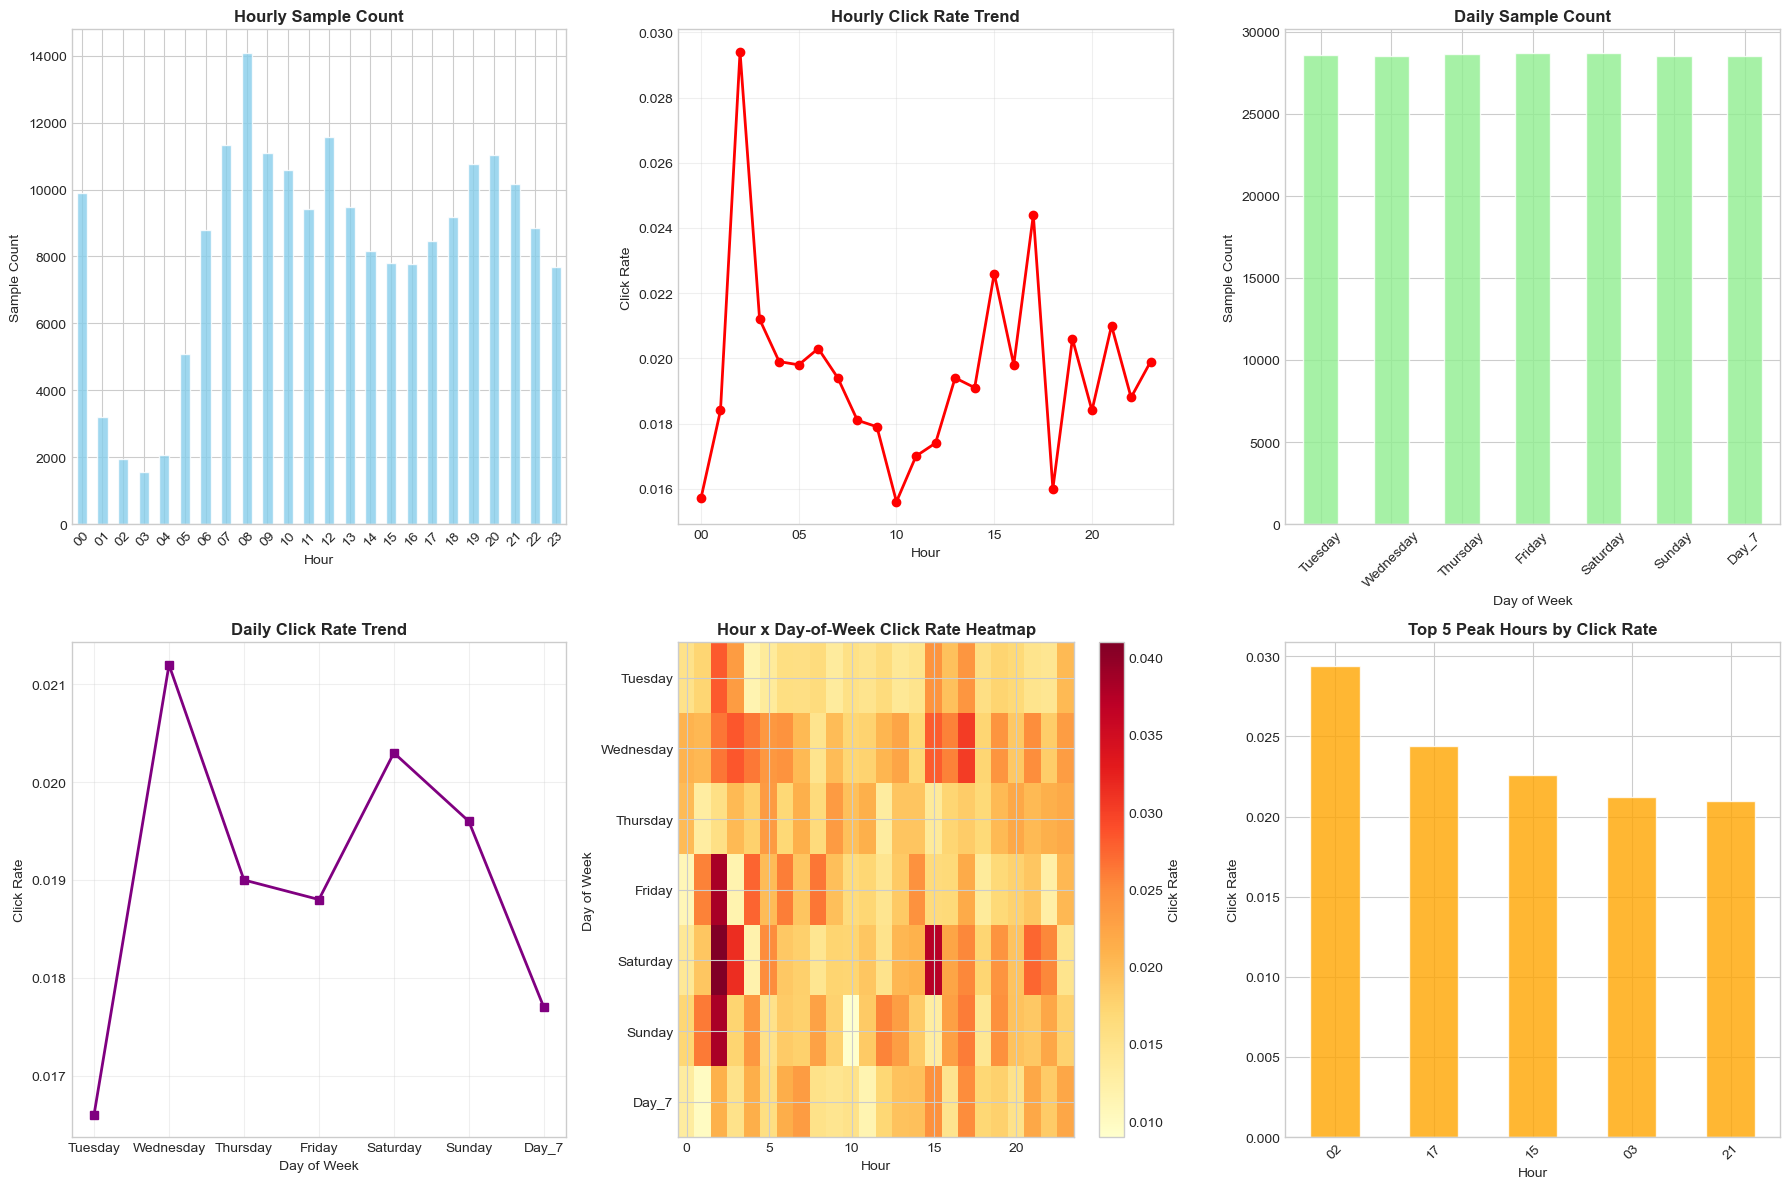


🕐 시간적 패턴 인사이트:
   최고 클릭률 시간: 02 (0.0294)
   최저 클릭률 시간: 10 (0.0156)
   최고 클릭률 요일: Wednesday (0.0212)
   최저 클릭률 요일: Tuesday (0.0166)


In [65]:

# ========================================
# ⏰ 3. 시간적 패턴 분석
# ========================================

print("\n" + "="*60)
print("⏰ 시간적 패턴 분석")
print("="*60)

# 시간별 통계
hourly_stats = df.groupby('hour').agg({
    'clicked': ['count', 'sum', 'mean']
})
hourly_stats.columns = ['Total_Samples', 'Clicks', 'Click_Rate']
hourly_stats = hourly_stats.round(4)

print("📊 시간별 통계 (상위 5개):")
print(hourly_stats.sort_values('Click_Rate', ascending=False).head())

# 요일별 통계 (day_of_week: 0=월 ~ 6=일, 0부터 시작)
daily_stats = df.groupby('day_of_week').agg({
    'clicked': ['count', 'sum', 'mean']
})
daily_stats.columns = ['Total_Samples', 'Clicks', 'Click_Rate']
daily_stats = daily_stats.round(4)

print(f"\n📊 요일별 통계:")
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_stats.index = [day_names[i] if i < len(day_names) else f'Day_{i}' for i in daily_stats.index]
print(daily_stats)

# 시간적 패턴 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 시간대별 샘플 수
hourly_stats['Total_Samples'].plot(kind='bar', ax=axes[0,0], color='skyblue', alpha=0.8)
axes[0,0].set_title('Hourly Sample Count', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Sample Count')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. 시간대별 클릭률 추세
hourly_stats['Click_Rate'].plot(kind='line', ax=axes[0,1], color='red', marker='o', linewidth=2)
axes[0,1].set_title('Hourly Click Rate Trend', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Click Rate')
axes[0,1].grid(True, alpha=0.3)

# 3. 요일별 샘플 수
daily_stats['Total_Samples'].plot(kind='bar', ax=axes[0,2], color='lightgreen', alpha=0.8)
axes[0,2].set_title('Daily Sample Count', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Day of Week')
axes[0,2].set_ylabel('Sample Count')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. 일일 클릭률 추세
daily_stats['Click_Rate'].plot(kind='line', ax=axes[1,0], color='purple', marker='s', linewidth=2)
axes[1,0].set_title('Daily Click Rate Trend', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Day of Week')
axes[1,0].set_ylabel('Click Rate')
axes[1,0].grid(True, alpha=0.3)

# 5. 시간대 x 요일 클릭률 히트맵
pivot_table = df.groupby(['day_of_week', 'hour'])['clicked'].mean().unstack()
im = axes[1,1].imshow(pivot_table.values, cmap='YlOrRd', aspect='auto')
axes[1,1].set_title('Hour x Day-of-Week Click Rate Heatmap', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Day of Week')
axes[1,1].set_yticks(range(len(pivot_table.index)))
axes[1,1].set_yticklabels([day_names[i] if i < len(day_names) else f'Day_{i}' for i in pivot_table.index])
plt.colorbar(im, ax=axes[1,1], label='Click Rate')

# 6. 피크 시간 분석
peak_hours = hourly_stats.nlargest(5, 'Click_Rate')
peak_hours.index.name = 'Hour'
peak_hours['Click_Rate'].plot(kind='bar', ax=axes[1,2], color='orange', alpha=0.8)
axes[1,2].set_title('Top 5 Peak Hours by Click Rate', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Hour')
axes[1,2].set_ylabel('Click Rate')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 시간적 패턴 인사이트
print(f"\n🕐 시간적 패턴 인사이트:")
peak_hour = hourly_stats['Click_Rate'].idxmax()
low_hour = hourly_stats['Click_Rate'].idxmin()
print(f"   최고 클릭률 시간: {peak_hour} ({hourly_stats.loc[peak_hour, 'Click_Rate']:.4f})")
print(f"   최저 클릭률 시간: {low_hour} ({hourly_stats.loc[low_hour, 'Click_Rate']:.4f})")

peak_day = daily_stats['Click_Rate'].idxmax()
low_day = daily_stats['Click_Rate'].idxmin()
print(f"   최고 클릭률 요일: {peak_day} ({daily_stats.loc[peak_day, 'Click_Rate']:.4f})")
print(f"   최저 클릭률 요일: {low_day} ({daily_stats.loc[low_day, 'Click_Rate']:.4f})")


👥 사용자 세그먼트 분석
📊 성별 통계:
        Total_Samples  Clicks  Click_Rate
gender                                   
1.0            125592    2419      0.0193
2.0             74081    1374      0.0185

📊 연령대별 통계:
           Total_Samples  Clicks  Click_Rate
age_group                                   
1.0                  526      47      0.0894
2.0                 6728     160      0.0238
8.0                49455    1175      0.0238
3.0                 9139     198      0.0217
4.0                10290     179      0.0174
5.0                11137     192      0.0172
7.0                69023    1173      0.0170
6.0                43375     669      0.0154

📊 성별 x 연령대별 교차 분석 (클릭률 상위 10):
                  Total_Samples  Clicks  Click_Rate
gender age_group                                   
2.0    1.0                  216      21      0.0972
1.0    1.0                  310      26      0.0839
2.0    2.0                 2897      83      0.0287
       3.0                 4036     110      0.0273
1.

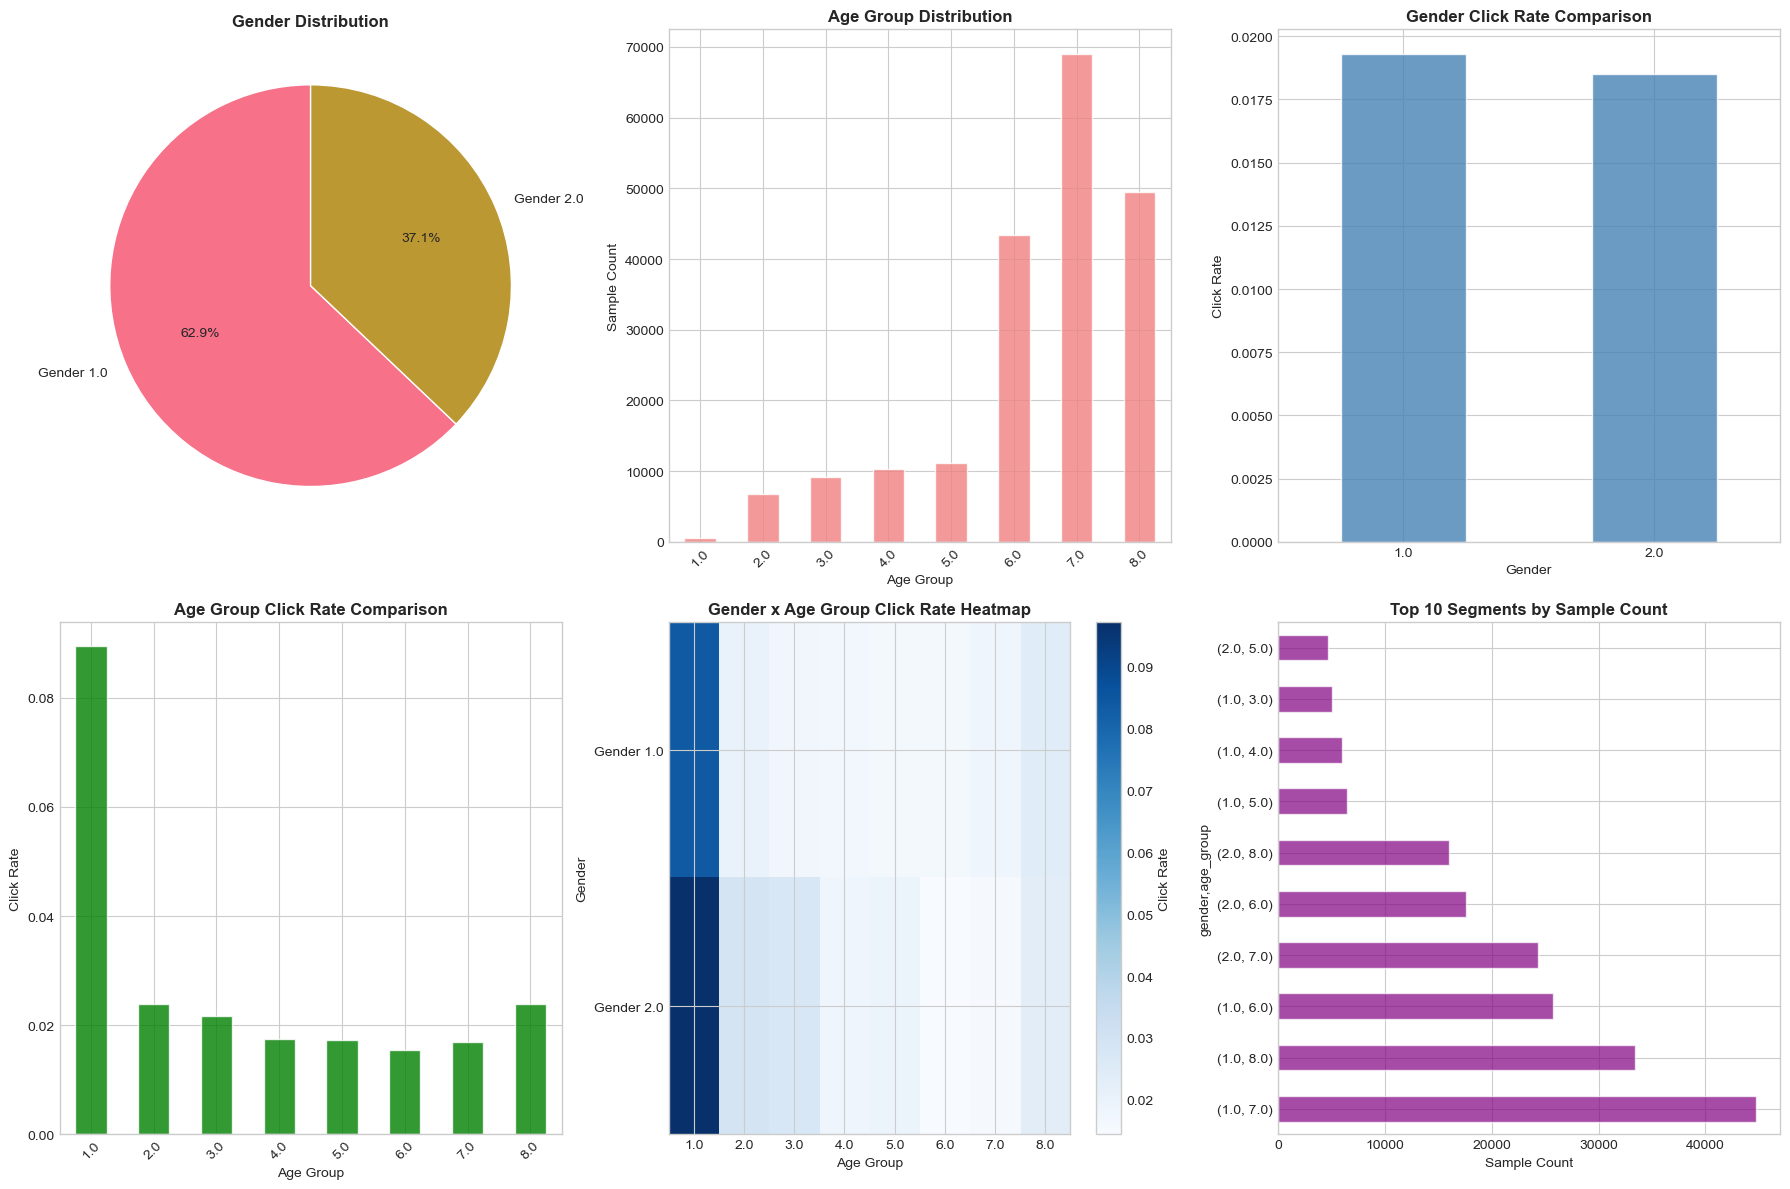


👥 세그멘트 인사이트:
   최고 클릭률 성별: Gender 1.0 (0.0193)
   최고 클릭률 연령대: Age 1.0 (0.0894)
   최고 클릭률 세그먼트: Gender 2.0, Age 1.0 (0.0972)


In [66]:

# ========================================
# 👥 4. 사용자 세그먼트 분석
# ========================================

print("\n" + "="*60)
print("👥 사용자 세그먼트 분석")
print("="*60)

# 성별 통계
gender_stats = df.groupby('gender').agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
gender_stats.columns = ['Total_Samples', 'Clicks', 'Click_Rate']

print("📊 성별 통계:")
print(gender_stats)

# 연령대별 통계
age_stats = df.groupby('age_group').agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
age_stats.columns = ['Total_Samples', 'Clicks', 'Click_Rate']

print(f"\n📊 연령대별 통계:")
print(age_stats.sort_values('Click_Rate', ascending=False))

# 성별 x 연령대별 교차 분석 
cross_analysis = df.groupby(['gender', 'age_group']).agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
cross_analysis.columns = ['Total_Samples', 'Clicks', 'Click_Rate']

print(f"\n📊 성별 x 연령대별 교차 분석 (클릭률 상위 10):")
print(cross_analysis.sort_values('Click_Rate', ascending=False).head(10))

# 사용자 세그먼트 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 성별 분포
gender_counts = df['gender'].value_counts()
axes[0,0].pie(gender_counts.values, labels=[f'Gender {i}' for i in gender_counts.index], 
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Gender Distribution', fontsize=12, fontweight='bold')

# 2. 연령별 분포
age_counts = df['age_group'].value_counts().sort_index()
age_counts.plot(kind='bar', ax=axes[0,1], color='lightcoral', alpha=0.8)
axes[0,1].set_title('Age Group Distribution', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Sample Count')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. 성별 클릭률 비교
gender_stats['Click_Rate'].plot(kind='bar', ax=axes[0,2], color='steelblue', alpha=0.8)
axes[0,2].set_title('Gender Click Rate Comparison', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Gender')
axes[0,2].set_ylabel('Click Rate')
axes[0,2].tick_params(axis='x', rotation=0)

# 4. 연령대별 클릭률 비교
age_stats['Click_Rate'].plot(kind='bar', ax=axes[1,0], color='green', alpha=0.8)
axes[1,0].set_title('Age Group Click Rate Comparison', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Age Group')
axes[1,0].set_ylabel('Click Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. 성별 x 연령대별 클릭률 히트맵
pivot_cross = df.groupby(['gender', 'age_group'])['clicked'].mean().unstack(fill_value=0)
im2 = axes[1,1].imshow(pivot_cross.values, cmap='Blues', aspect='auto')
axes[1,1].set_title('Gender x Age Group Click Rate Heatmap', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Gender')
axes[1,1].set_yticks(range(len(pivot_cross.index)))
axes[1,1].set_yticklabels([f'Gender {i}' for i in pivot_cross.index])
axes[1,1].set_xticks(range(len(pivot_cross.columns)))
axes[1,1].set_xticklabels(pivot_cross.columns)
plt.colorbar(im2, ax=axes[1,1], label='Click Rate')

# 6. 세그멘트 별 샘플 수 상위 10
cross_samples = df.groupby(['gender', 'age_group']).size().sort_values(ascending=False).head(10)
cross_samples.plot(kind='barh', ax=axes[1,2], color='purple', alpha=0.7)
axes[1,2].set_title('Top 10 Segments by Sample Count', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Sample Count')

plt.tight_layout()
plt.show()

# 세그멘트 인사이트
print(f"\n👥 세그멘트 인사이트:")
best_gender = gender_stats['Click_Rate'].idxmax()
best_age = age_stats['Click_Rate'].idxmax()
best_segment = cross_analysis['Click_Rate'].idxmax()

print(f"   최고 클릭률 성별: Gender {best_gender} ({gender_stats.loc[best_gender, 'Click_Rate']:.4f})")
print(f"   최고 클릭률 연령대: Age {best_age} ({age_stats.loc[best_age, 'Click_Rate']:.4f})")
print(f"   최고 클릭률 세그먼트: Gender {best_segment[0]}, Age {best_segment[1]} ({cross_analysis.loc[best_segment, 'Click_Rate']:.4f})")

---
## 3. 통계 검정 — 연구 질문 RQ1~RQ4 <a id='sec3'></a>

In [67]:
# ================================================================
# 📌 토스 광고 CTR 분석 — 연구계획서 기반 통합 분석 코드
# ================================================================
# 연구 제목: 사용자 특성과 광고 노출 환경이 CTR에 미치는 영향 분석
# 평가 지표: Average Precision (AP), Weighted LogLoss (WLL, 50:50)
# 연구 문제:
#   RQ1. 연령대(age_group)에 따라 CTR에 유의미한 차이가 있는가?
#   RQ2. 시간대(hour)에 따라 클릭 패턴이 어떻게 달라지는가?
#   RQ3. 광고 노출 환경(inventory_id, day_of_week)이 CTR에 미치는 영향?
#   RQ4. 사용자 특성+노출 환경을 함께 고려하면 CTR 예측이 향상되는가?
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("📌 토스 CTR 분석 — 연구계획서 통합 코드")
print("=" * 65)

# ── 데이터 로드 ──────────────────────────────────────────────────
df = train.copy()  # 섹션 1에서 로드한 train_sample 재사용

# ── 기본 파생 변수 (전체 분석에서 공유) ──────────────────────────
df['seq_length']      = df['seq'].str.split(',').str.len()
df['unique_items']    = df['seq'].apply(lambda x: len(set(x.split(','))))
df['diversity_ratio'] = df['unique_items'] / df['seq_length']
df['repeat_ratio']    = 1 - df['diversity_ratio']

# 타입 보정: hour/day_of_week 혼합형(str/int) -> int
df['hour'] = pd.to_numeric(df['hour'], errors='coerce').fillna(-1).astype(int)
df['day_of_week'] = pd.to_numeric(df['day_of_week'], errors='coerce').fillna(-1).astype(int)

# 시간 구간 (심야/오전/오후/저녁)
df['hour_period'] = pd.cut(
    df['hour'], bins=[-1,5,11,17,23],
    labels=['심야(0-5)','오전(6-11)','오후(12-17)','저녁(18-23)']
)
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_peak_hour'] = df['hour'].between(12,18).astype(int)

# 히스토리 집계
hist_a = [c for c in df.columns if c.startswith('history_a_')]
hist_b = [c for c in df.columns if c.startswith('history_b_')]
df['history_a_sum']  = df[hist_a].fillna(0).sum(axis=1)
df['history_b_sum']  = df[hist_b].fillna(0).sum(axis=1)
df['history_a_mean'] = df[hist_a].fillna(0).mean(axis=1)
df['history_b_mean'] = df[hist_b].fillna(0).mean(axis=1)
df['history_a_max']  = df[hist_a].fillna(0).max(axis=1)
df['history_b_max']  = df[hist_b].fillna(0).max(axis=1)
df['history_ab_ratio'] = (df['history_a_sum']+1e-6) / (df['history_b_sum']+1e-6)

# 지면 CTR 타깃 인코딩
inv_ctr = df.groupby('inventory_id')['clicked'].mean()
df['inv_ctr_encoded'] = df['inventory_id'].map(inv_ctr)

GLOBAL_CTR = df['clicked'].mean()

print(f"\n📊 데이터: {len(df):,}샘플 / {df['clicked'].sum():,}클릭")
print(f"   전체 CTR: {GLOBAL_CTR:.4f} ({GLOBAL_CTR*100:.2f}%)")
print(f"   클래스 불균형: {(1-GLOBAL_CTR)/GLOBAL_CTR:.1f}:1")
print(f"\n✅ 기본 파생 변수 {20}개 생성 완료")

📌 토스 CTR 분석 — 연구계획서 통합 코드

📊 데이터: 200,000샘플 / 3,804클릭
   전체 CTR: 0.0190 (1.90%)
   클래스 불균형: 51.6:1

✅ 기본 파생 변수 20개 생성 완료


### RQ1. 연령대(age_group)에 따라 CTR에 유의미한 차이가 있는가?


📊 RQ1. 연령대별 클릭률 분석

[Descriptive Statistics] Click Rate by Age Group:
           Sample_Count  Click_Count  Click_Rate  Std_Dev  CI_95_Lower  CI_95_Upper
age_group                                                                          
1.0                 526           47      0.0894   0.2855       0.0650       0.1138
2.0                6728          160      0.0238   0.1524       0.0202       0.0274
3.0                9139          198      0.0217   0.1456       0.0187       0.0247
4.0               10290          179      0.0174   0.1307       0.0149       0.0199
5.0               11137          192      0.0172   0.1302       0.0148       0.0196
6.0               43375          669      0.0154   0.1232       0.0142       0.0166
7.0               69023         1173      0.0170   0.1293       0.0160       0.0180
8.0               49455         1175      0.0238   0.1523       0.0225       0.0251

[One-way ANOVA]  F=37.1173, p=0.000000 ***
[Kruskal-Wallis] H=259.4922, p=0.000000 ***


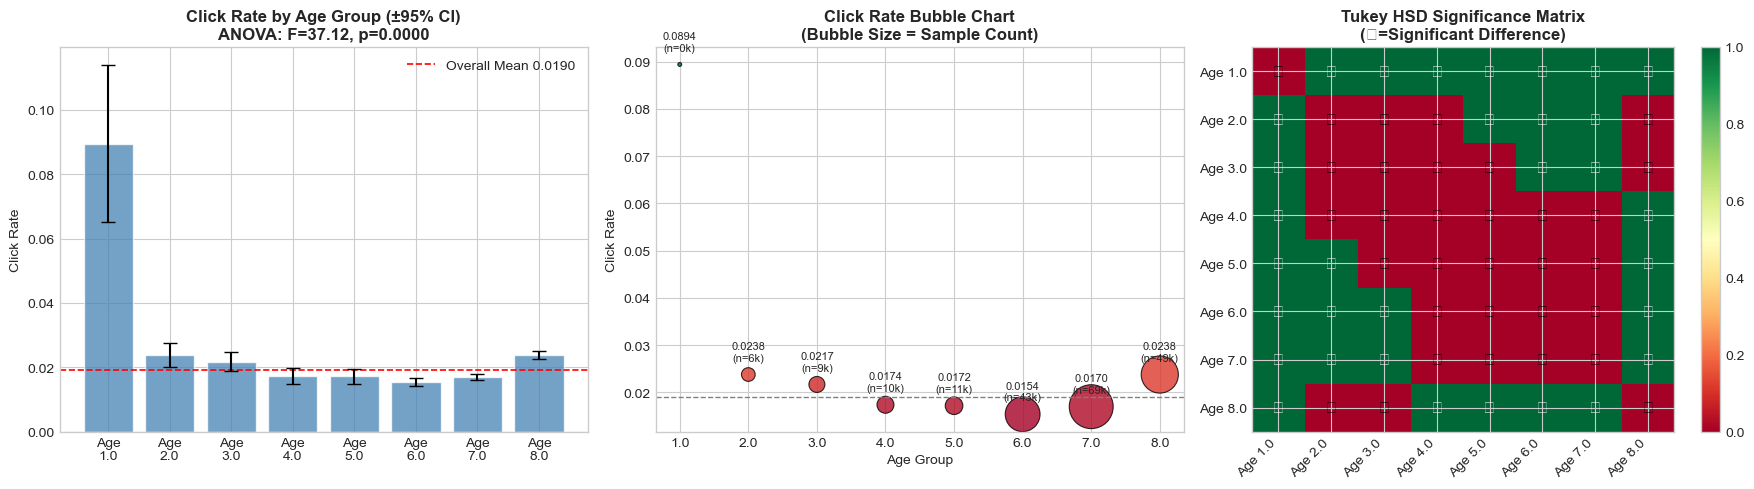


✅ RQ1 결론: 연령대 간 클릭률에 유의미한 차이가 존재함 (p<0.001)


In [68]:
# ================================================================
# 📊 RQ1. 연령대별 클릭률 차이가 유의미한가?
# ================================================================

from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("\n" + "="*65)
print("📊 RQ1. 연령대별 클릭률 분석")
print("="*65)

age_groups  = sorted(df['age_group'].dropna().unique())
age_samples = [df[df['age_group']==ag]['clicked'].values for ag in age_groups]

# Descriptive Statistics
age_desc = df.groupby('age_group')['clicked'].agg(
    Sample_Count='count', Click_Count='sum', Click_Rate='mean', Std_Dev='std'
).round(4)
age_desc['CI_95_Lower'] = age_desc['Click_Rate'] - 1.96*(age_desc['Std_Dev']/np.sqrt(age_desc['Sample_Count']))
age_desc['CI_95_Upper'] = age_desc['Click_Rate'] + 1.96*(age_desc['Std_Dev']/np.sqrt(age_desc['Sample_Count']))
print("\n[Descriptive Statistics] Click Rate by Age Group:")
print(age_desc.round(4).to_string())

# One-way ANOVA
F_age, p_anova_age = f_oneway(*age_samples)
H_age, p_kruskal_age = kruskal(*age_samples)

print(f"\n[One-way ANOVA]  F={F_age:.4f}, p={p_anova_age:.6f}",
      "***" if p_anova_age<0.001 else "")
print(f"[Kruskal-Wallis] H={H_age:.4f}, p={p_kruskal_age:.6f}",
      "***" if p_kruskal_age<0.001 else "")

# Tukey HSD Post-Hoc Test
_mask_age = df['age_group'].notna()
tukey_age = pairwise_tukeyhsd(
    endog=df.loc[_mask_age, 'clicked'],
    groups=df.loc[_mask_age, 'age_group'], alpha=0.05
)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) CTR with 95% CI
ci_lo = age_desc['CI_95_Lower'].values
ci_hi = age_desc['CI_95_Upper'].values
ctrs  = age_desc['Click_Rate'].values
x_pos = range(len(age_groups))
axes[0].bar(x_pos, ctrs, color='steelblue', alpha=0.75, zorder=2)
axes[0].errorbar(x_pos, ctrs,
                 yerr=[ctrs-ci_lo, ci_hi-ctrs],
                 fmt='none', color='black', capsize=5, linewidth=1.5, zorder=3)
axes[0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                label=f'Overall Mean {GLOBAL_CTR:.4f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'Age\n{ag}' for ag in age_groups])
axes[0].set_title(f'Click Rate by Age Group (±95% CI)\nANOVA: F={F_age:.2f}, p={p_anova_age:.4f}',
                  fontweight='bold')
axes[0].set_ylabel('Click Rate')
axes[0].legend()

# 2) Bubble Chart - 표본 크기 대비 클릭률
bubble_size = age_desc['Sample_Count'] / age_desc['Sample_Count'].max() * 1000
axes[1].scatter(age_groups, ctrs, s=bubble_size,
                c=ctrs, cmap='RdYlGn', alpha=0.8, edgecolors='black', linewidths=0.8)
axes[1].axhline(GLOBAL_CTR, color='gray', linestyle='--', linewidth=1)
for ag, ctr, s in zip(age_groups, ctrs, age_desc['Sample_Count'].values):
    axes[1].annotate(f'{ctr:.4f}\n(n={s//1000}k)',
                     (ag, ctr), textcoords='offset points',
                     xytext=(0,10), ha='center', fontsize=8)
axes[1].set_title('Click Rate Bubble Chart\n(Bubble Size = Sample Count)', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Click Rate')

# 3) Tukey HSD 유의성 행렬
n = len(age_groups)
sig_mat = np.zeros((n, n))
age_index = {str(v): idx for idx, v in enumerate(age_groups)}

for row in tukey_age.summary().data[1:]:
    g1, g2 = row[0], row[1]
    reject_raw = row[-1]
    if isinstance(reject_raw, str):
        reject = reject_raw.strip().lower() == 'true'
    else:
        reject = bool(reject_raw)

    i = age_index.get(str(g1))
    j = age_index.get(str(g2))
    if i is None or j is None:
        continue

    sig_mat[i, j] = sig_mat[j, i] = 1 if reject else 0

mask = np.eye(n, dtype=bool)
im = axes[2].imshow(sig_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[2].set_xticks(range(n)); axes[2].set_yticks(range(n))
axes[2].set_xticklabels([f'Age {ag}' for ag in age_groups], rotation=45, ha='right')
axes[2].set_yticklabels([f'Age {ag}' for ag in age_groups])
for i in range(n):
    for j in range(n):
        axes[2].text(j, i, '✓' if sig_mat[i,j] else '✗',
                     ha='center', va='center',
                     color='white' if sig_mat[i,j] else 'black', fontsize=12)
axes[2].set_title('Tukey HSD Significance Matrix\n(✓=Significant Difference)', fontweight='bold')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('RQ1_age_ctr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RQ1 결론:",
      "연령대 간 클릭률에 유의미한 차이가 존재함 (p<0.001)"
      if p_anova_age < 0.001 else
      "연령대 간 클릭률 차이는 통계적으로 유의하지 않음")

### RQ2. 시간대(hour)에 따라 클릭 패턴이 어떻게 달라지는가?


⏰ RQ2. 시간대별 클릭 패턴 분석

[Descriptive Statistics] Click Rate by Time Period:
             Sample_Count  Click_Count  Click_Rate
hour_period                                       
심야(0-5)             23769          446      0.0188
오전(6-11)            65281         1176      0.0180
오후(12-17)           53251         1077      0.0202
저녁(18-23)           57699         1105      0.0192

[일원분산분석(ANOVA)] 24시간: F=2.51, p=0.000078 ***
[일원분산분석(ANOVA)] 4개 구간: F=nan, p=nan 
[Kruskal-Wallis] H=57.83, p=0.000078 ***

[Tukey HSD] 쌍별 비교:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
  심야(0-5)  오전(6-11)  -0.0007 0.8874 -0.0034 0.0019  False
  심야(0-5) 오후(12-17)   0.0015 0.5175 -0.0013 0.0042  False
  심야(0-5) 저녁(18-23)   0.0004  0.983 -0.0023 0.0031  False
 오전(6-11) 오후(12-17)   0.0022 0.0285  0.0002 0.0043   True
 오전(6-11) 저녁(18-23)   0.0011 0.4641 -0.0009 0.0031  False
오후(12-17) 저

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


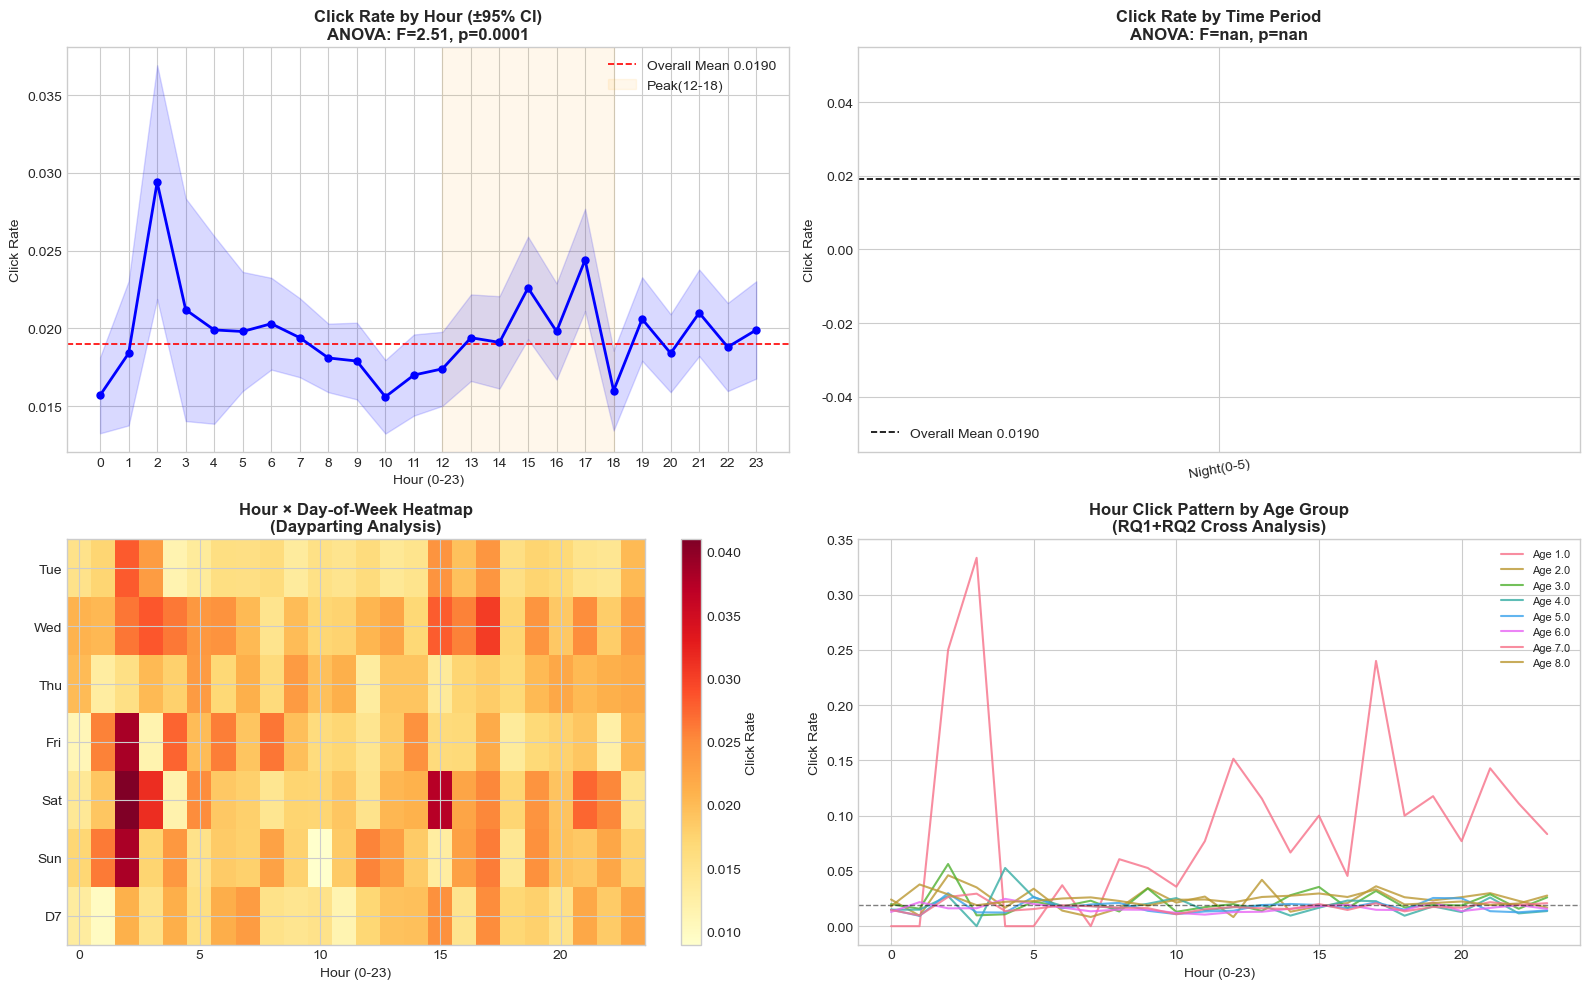


✅ RQ2 결론:


In [69]:
# ================================================================
# ⏰ RQ2. 시간대별 클릭 패턴 분석
# ================================================================

from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("\n" + "="*65)
print("⏰ RQ2. 시간대별 클릭 패턴 분석")
print("="*65)

# 시간별 기술 통계
hour_desc = df.groupby('hour')['clicked'].agg(
    Sample_Count='count', Click_Count='sum', Click_Rate='mean', Std_Dev='std'
).round(4)
hour_desc['CI_95'] = 1.96 * (hour_desc['Std_Dev'] / np.sqrt(hour_desc['Sample_Count']))

# 시간 구간별 CTR 통계
period_desc = df.groupby('hour_period', observed=True)['clicked'].agg(
    Sample_Count='count', Click_Count='sum', Click_Rate='mean'
).round(4)
print("\n[Descriptive Statistics] Click Rate by Time Period:")
print(period_desc.to_string())

# ANOVA: 24-hour basis
hour_samples  = [df[df['hour']==h]['clicked'].values for h in range(24)]
F_hour, p_hour = f_oneway(*hour_samples)
H_hour, p_krus_hour = kruskal(*hour_samples)

# ANOVA: 4 time periods
period_labels = ['Night(0-5)','Morning(6-11)','Afternoon(12-17)','Evening(18-23)']
period_samples = [df[df['hour_period']==p]['clicked'].values for p in period_labels]
F_period, p_period = f_oneway(*period_samples)

# Tukey HSD (4 periods)
period_data = df[['hour_period','clicked']].dropna()
tukey_period = pairwise_tukeyhsd(
    endog=period_data['clicked'],
    groups=period_data['hour_period'], alpha=0.05
)

print(f"\n[일원분산분석(ANOVA)] 24시간: F={F_hour:.2f}, p={p_hour:.6f}",
      "***" if p_hour<0.001 else "")
print(f"[일원분산분석(ANOVA)] 4개 구간: F={F_period:.2f}, p={p_period:.6f}",
      "***" if p_period<0.001 else "")
print(f"[Kruskal-Wallis] H={H_hour:.2f}, p={p_krus_hour:.6f}",
      "***" if p_krus_hour<0.001 else "")
print("\n[Tukey HSD] 쌍별 비교:")
print(tukey_period.summary())

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) 시간별 클릭률 (±95% CI)
h_ctrs = hour_desc['Click_Rate'].values
h_ci   = hour_desc['CI_95'].values
hours  = list(range(24))
axes[0,0].plot(hours, h_ctrs, 'b-o', linewidth=2, markersize=5, zorder=3)
axes[0,0].fill_between(hours, h_ctrs-h_ci, h_ctrs+h_ci, alpha=0.15, color='blue')
axes[0,0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                  label=f'Overall Mean {GLOBAL_CTR:.4f}')
# Highlight peak period
axes[0,0].axvspan(12, 18, alpha=0.08, color='orange', label='Peak(12-18)')
axes[0,0].set_title(f'Click Rate by Hour (±95% CI)\nANOVA: F={F_hour:.2f}, p={p_hour:.4f}',
                    fontweight='bold')
axes[0,0].set_xlabel('Hour (0-23)')
axes[0,0].set_ylabel('Click Rate')
axes[0,0].legend()
axes[0,0].set_xticks(hours)

# 2) 4개 구간 막대 차트
period_ctrs = period_desc['Click_Rate'].reindex(period_labels)
colors_p = ['#1a237e','#42a5f5','#ff8f00','#e53935']
bars = axes[0,1].bar(period_labels, period_ctrs, color=colors_p, alpha=0.85)
axes[0,1].axhline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1.2,
                  label=f'Overall Mean {GLOBAL_CTR:.4f}')
for bar, v in zip(bars, period_ctrs):
    axes[0,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.0003,
                   f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0,1].set_title(f'Click Rate by Time Period\nANOVA: F={F_period:.2f}, p={p_period:.4f}',
                    fontweight='bold')
axes[0,1].set_ylabel('Click Rate')
axes[0,1].tick_params(axis='x', rotation=10)
axes[0,1].legend()

# 3) 시간대별 요일별 히트맵
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot = df.groupby(['day_of_week','hour'])['clicked'].mean().unstack()
im = axes[1,0].imshow(pivot.values, cmap='YlOrRd', aspect='auto')
axes[1,0].set_yticks(range(len(pivot.index)))
axes[1,0].set_yticklabels([day_names[i] if i<7 else f'D{i}' for i in pivot.index])
axes[1,0].set_xlabel('Hour (0-23)')
axes[1,0].set_title('Hour × Day-of-Week Heatmap\n(Dayparting Analysis)', fontweight='bold')
plt.colorbar(im, ax=axes[1,0], label='Click Rate')

# 4) 연령대별 시간대 클릭 패턴
for ag in sorted(df['age_group'].dropna().unique()):
    sub = df[df['age_group']==ag].groupby('hour')['clicked'].mean()
    axes[1,1].plot(sub.index, sub.values, linewidth=1.5, alpha=0.8, label=f'Age {ag}')
axes[1,1].axhline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1,1].set_title('Hour Click Pattern by Age Group\n(RQ1+RQ2 Cross Analysis)', fontweight='bold')
axes[1,1].set_xlabel('Hour (0-23)')
axes[1,1].set_ylabel('Click Rate')
axes[1,1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('RQ2_hour_ctr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RQ2 결론:")

### RQ3. 광고 노출 환경(inventory_id, day_of_week)이 CTR에 미치는 영향


🗺️  RQ3. 광고 노출 환경 분석

[Ad Placement] Total Ad Placements: 18
  Highest Click Rate Placement: 92  (0.0789)
  Lowest Click Rate Placement: 8  (0.0026)
  Click Rate Std Dev: 0.0194  (Placement Variation)

[One-way ANOVA] inventory_id: F=52.67, p=0.000000 ***
[Chi-Square]    inventory_id: χ²=891.48, p=0.000000 ***

[Day-of-Week Click Rate]:
     Sample_Count  Click_Rate  Std_Dev
Tue         28558      0.0166   0.1279
Wed         28494      0.0212   0.1439
Thu         28602      0.0190   0.1366
Fri         28681      0.0188   0.1359
Sat         28691      0.0203   0.1410
Sun         28482      0.0196   0.1385
D7          28492      0.0177   0.1317

[One-way ANOVA] day_of_week: F=3.59, p=0.001468 


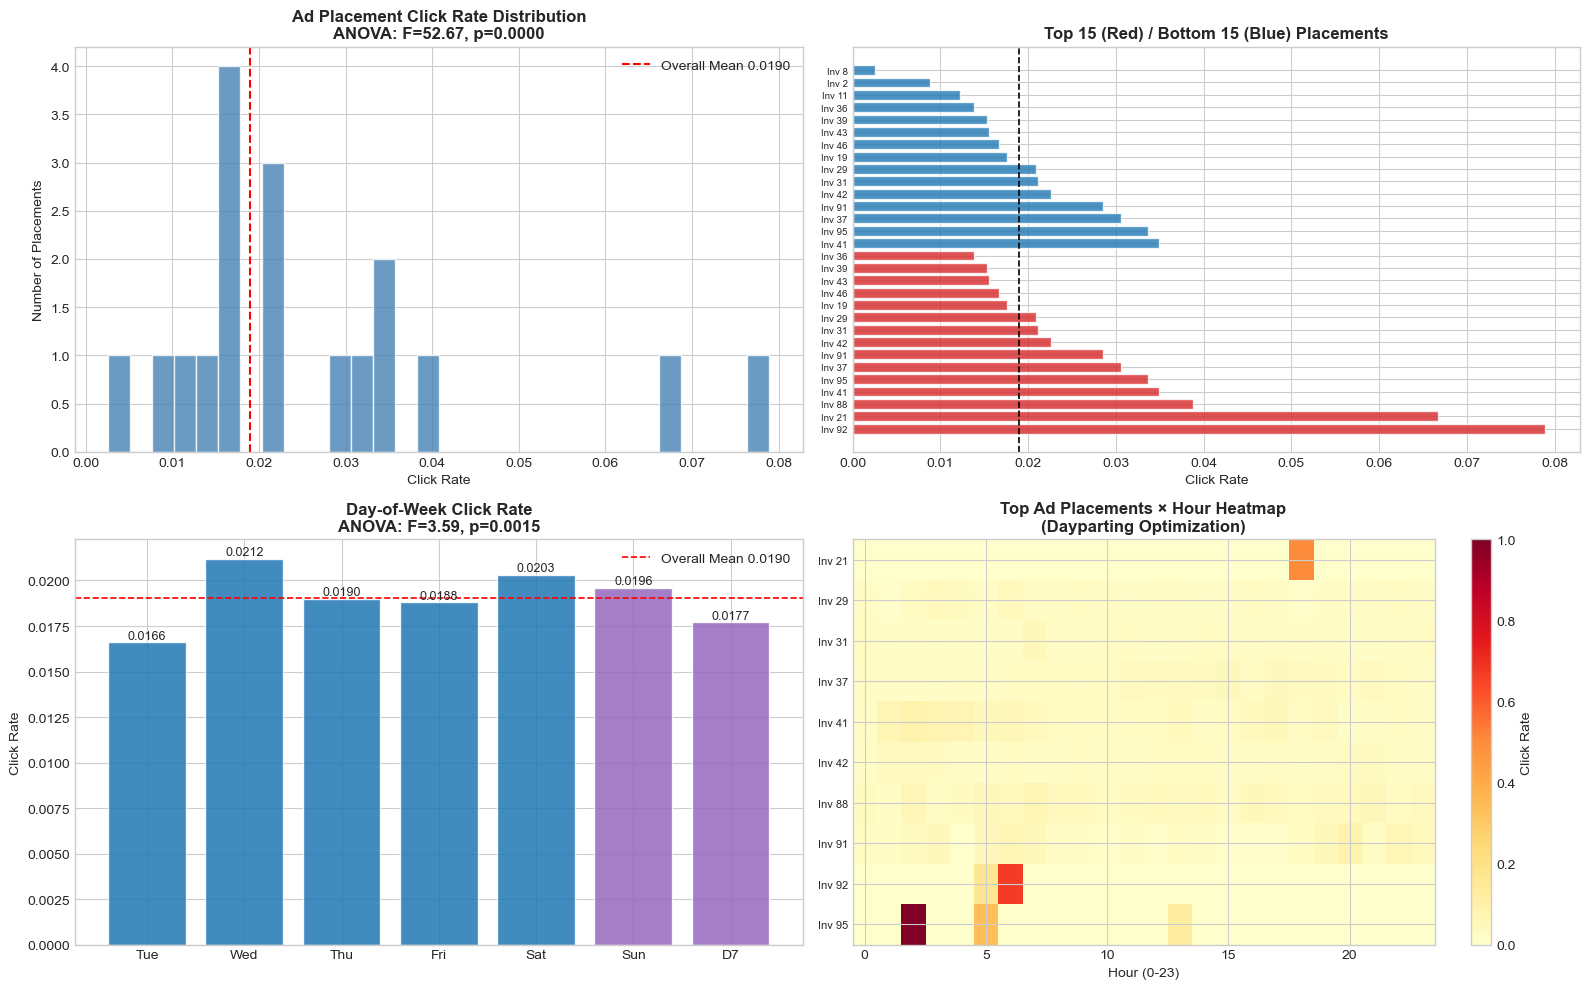


✅ RQ3 Conclusion: 광고 위치와 요일에 따라 CTR(클릭률)에서 통계적으로 유의미한 차이가 존재한다


In [70]:
# ================================================================
# 🗺️  RQ3. 광고 노출 환경 CTR 분석
# ================================================================

from scipy.stats import f_oneway, kruskal, chi2_contingency

print("\n" + "="*65)
print("🗺️  RQ3. 광고 노출 환경 분석")
print("="*65)

# ── 인벤토리 ID 분석 ──────────────────────────────────────
inv_desc = df.groupby('inventory_id')['clicked'].agg(
    Sample_Count='count', Click_Rate='mean'
).sort_values('Click_Rate', ascending=False)

print(f"\n[Ad Placement] Total Ad Placements: {len(inv_desc)}")
print(f"  Highest Click Rate Placement: {inv_desc.index[0]}  ({inv_desc['Click_Rate'].iloc[0]:.4f})")
print(f"  Lowest Click Rate Placement: {inv_desc.index[-1]}  ({inv_desc['Click_Rate'].iloc[-1]:.4f})")
print(f"  Click Rate Std Dev: {inv_desc['Click_Rate'].std():.4f}  (Placement Variation)")

# ANOVA & Chi2: inventory_id
inv_groups = [df[df['inventory_id']==inv]['clicked'].values
              for inv in df['inventory_id'].unique()]
F_inv, p_inv = f_oneway(*inv_groups)
chi2_inv, p_chi2_inv, _, _ = chi2_contingency(
    pd.crosstab(df['inventory_id'], df['clicked']))

print(f"\n[One-way ANOVA] inventory_id: F={F_inv:.2f}, p={p_inv:.6f}",
      "***" if p_inv<0.001 else "")
print(f"[Chi-Square]    inventory_id: χ²={chi2_inv:.2f}, p={p_chi2_inv:.6f}",
      "***" if p_chi2_inv<0.001 else "")

# ── Day of Week Analysis ──────────────────────────────────────
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_desc = df.groupby('day_of_week')['clicked'].agg(
    Sample_Count='count', Click_Rate='mean', Std_Dev='std'
).round(4)
day_desc.index = [day_names[i] if i<7 else f'D{i}' for i in day_desc.index]
print("\n[Day-of-Week Click Rate]:")
print(day_desc.to_string())

dow_groups = [df[df['day_of_week']==d]['clicked'].values
              for d in sorted(df['day_of_week'].dropna().unique())]
F_dow, p_dow = f_oneway(*dow_groups)
print(f"\n[One-way ANOVA] day_of_week: F={F_dow:.2f}, p={p_dow:.6f}",
      "***" if p_dow<0.001 else "")

# ── Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) 광고 위치 클릭률 분포 (상위/하위 10 + 전체)
axes[0,0].hist(inv_desc['Click_Rate'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].axvline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.5,
                  label=f'Overall Mean {GLOBAL_CTR:.4f}')
axes[0,0].set_title(f'Ad Placement Click Rate Distribution\nANOVA: F={F_inv:.2f}, p={p_inv:.4f}',
                    fontweight='bold')
axes[0,0].set_xlabel('Click Rate')
axes[0,0].set_ylabel('Number of Placements')
axes[0,0].legend()

# 2) 상위/하위 15 광고 위치
top15  = inv_desc.head(15)
bot15  = inv_desc.tail(15)
combined = pd.concat([top15, bot15])
colors_inv = ['#d62728']*15 + ['#1f77b4']*15
axes[0,1].barh(range(len(combined)), combined['Click_Rate'],
               color=colors_inv, alpha=0.8)
axes[0,1].set_yticks(range(len(combined)))
axes[0,1].set_yticklabels([f'Inv {i}' for i in combined.index], fontsize=7)
axes[0,1].axvline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1.2)
axes[0,1].set_title('Top 15 (Red) / Bottom 15 (Blue) Placements',
                    fontweight='bold')
axes[0,1].set_xlabel('Click Rate')

# 3) 요일별 클릭률
day_ctrs = day_desc['Click_Rate'].values
colors_d = ['#9467bd' if i>=5 else '#1f77b4' for i in range(len(day_desc))]
bars = axes[1,0].bar(day_desc.index, day_ctrs, color=colors_d, alpha=0.85)
axes[1,0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                  label=f'Overall Mean {GLOBAL_CTR:.4f}')
for bar, v in zip(bars, day_ctrs):
    axes[1,0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.0002,
                   f'{v:.4f}', ha='center', fontsize=9)
axes[1,0].set_title(f'Day-of-Week Click Rate\nANOVA: F={F_dow:.2f}, p={p_dow:.4f}',
                    fontweight='bold')
axes[1,0].set_ylabel('Click Rate')
axes[1,0].legend()

# 4) 광고 위치 × 시간대 히트맵 (상위 10개 광고 위치만)
top10_inv = inv_desc.head(10).index
pivot_inv = df[df['inventory_id'].isin(top10_inv)].groupby(
    ['inventory_id','hour'])['clicked'].mean().unstack(fill_value=0)
im4 = axes[1,1].imshow(pivot_inv.values, cmap='YlOrRd', aspect='auto')
axes[1,1].set_yticks(range(len(pivot_inv.index)))
axes[1,1].set_yticklabels([f'Inv {i}' for i in pivot_inv.index], fontsize=8)
axes[1,1].set_xlabel('Hour (0-23)')
axes[1,1].set_title('Top Ad Placements × Hour Heatmap\n(Dayparting Optimization)',
                    fontweight='bold')
plt.colorbar(im4, ax=axes[1,1], label='Click Rate')

plt.tight_layout()
plt.savefig('RQ3_env_ctr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RQ3 Conclusion: 광고 위치와 요일에 따라 CTR(클릭률)에서 통계적으로 유의미한 차이가 존재한다")

---
## 4. 피처 엔지니어링 <a id='sec4'></a>

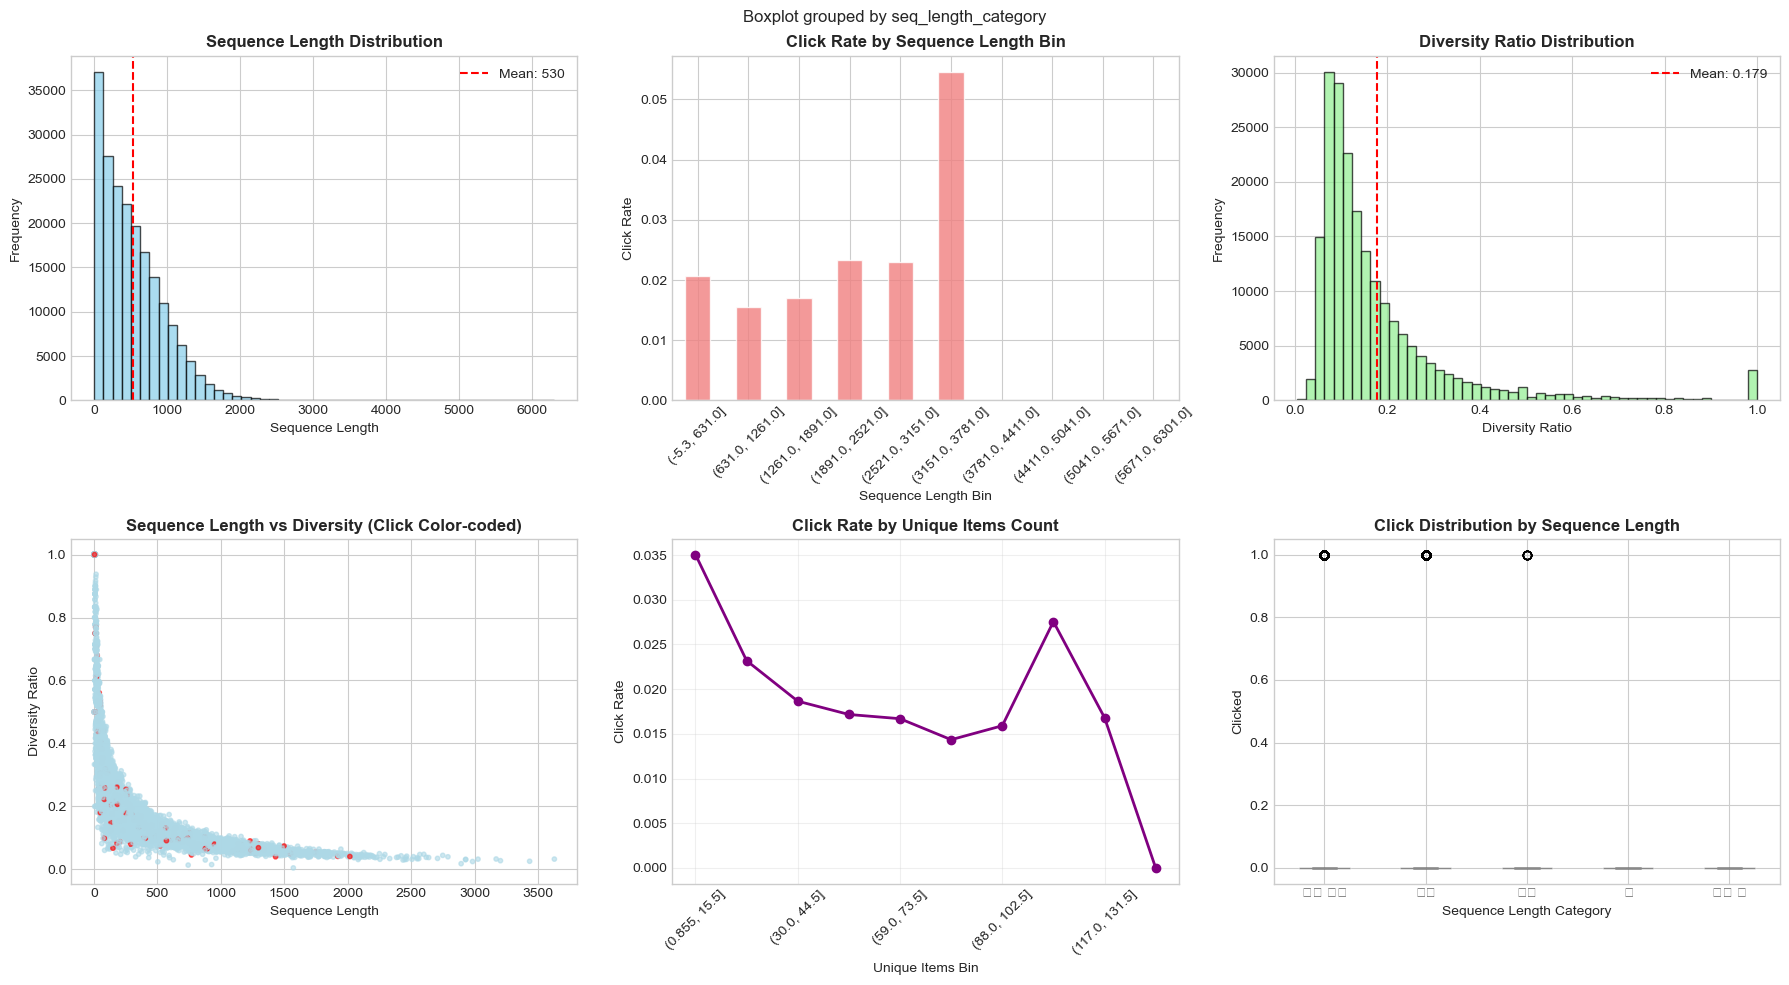

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 이 셀 단독 실행 시에도 동작하도록 파생 변수 보장
if 'seq_length' not in df.columns:
    df['seq_length'] = df['seq'].astype(str).str.split(',').str.len()

if 'unique_items' not in df.columns:
    df['unique_items'] = df['seq'].astype(str).apply(lambda s: len(set(s.split(','))))

if 'diversity_ratio' not in df.columns:
    df['diversity_ratio'] = df['unique_items'] / df['seq_length'].replace(0, np.nan)
    df['diversity_ratio'] = df['diversity_ratio'].fillna(0)

seq_bins = pd.cut(df['seq_length'], bins=10)
seq_bin_analysis = (
    df.groupby(seq_bins, observed=False)['clicked']
    .mean()
    .to_frame('Click_Rate')
)

# 1. 시퀀스 길이 분포
df['seq_length'].hist(
    bins=50,
    ax=axes[0, 0],
    color='skyblue',
    alpha=0.7,
    edgecolor='black'
)
axes[0, 0].set_title('Sequence Length Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sequence Length')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(
    df['seq_length'].mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {df["seq_length"].mean():.0f}'
)
axes[0, 0].legend()

# 2. 시퀀스 길이 구간별 클릭률
seq_bin_analysis['Click_Rate'].plot(
    kind='bar',
    ax=axes[0, 1],
    color='lightcoral',
    alpha=0.8
)
axes[0, 1].set_title('Click Rate by Sequence Length Bin', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Sequence Length Bin')
axes[0, 1].set_ylabel('Click Rate')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. 다양성 비율 분포
df['diversity_ratio'].hist(
    bins=50,
    ax=axes[0, 2],
    color='lightgreen',
    alpha=0.7,
    edgecolor='black'
)
axes[0, 2].set_title('Diversity Ratio Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Diversity Ratio')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(
    df['diversity_ratio'].mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {df["diversity_ratio"].mean():.3f}'
)
axes[0, 2].legend()

# 4. 시퀀스 길이 vs 다양성 산점도
sample_df = df.sample(n=min(10000, len(df)), random_state=42)
clicked_color = sample_df['clicked'].map({0: 'lightblue', 1: 'red'})

axes[1, 0].scatter(
    sample_df['seq_length'],
    sample_df['diversity_ratio'],
    c=clicked_color,
    alpha=0.6,
    s=10
)
axes[1, 0].set_title('Sequence Length vs Diversity (Click Color-coded)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sequence Length')
axes[1, 0].set_ylabel('Diversity Ratio')

# 5. 고유 아이템 수 구간별 클릭률
unique_bins = pd.cut(df['unique_items'], bins=10)
unique_analysis = df.groupby(unique_bins, observed=False)['clicked'].mean()

unique_analysis.plot(
    kind='line',
    ax=axes[1, 1],
    marker='o',
    color='purple',
    linewidth=2
)
axes[1, 1].set_title('Click Rate by Unique Items Count', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Unique Items Bin')
axes[1, 1].set_ylabel('Click Rate')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

# 6. 시퀀스 길이 카테고리별 클릭 분포
df['seq_length_category'] = pd.cut(
    df['seq_length'],
    bins=5,
    labels=['매우 짧음', '짧음', '중간', '긺', '매우 긺']
)
df.boxplot(column='clicked', by='seq_length_category', ax=axes[1, 2])
axes[1, 2].set_title('Click Distribution by Sequence Length', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Sequence Length Category')
axes[1, 2].set_ylabel('Clicked')

plt.tight_layout()
plt.show()


📊 피처 그룹 분석
🔍 Feature Group Composition:
   l_feat: 27 features, Missing values: 2,943
   feat_a: 18 features, Missing values: 6,444
   feat_b: 6 features, Missing values: 1,962
   feat_c: 8 features, Missing values: 2,616
   feat_d: 6 features, Missing values: 1,962
   feat_e: 10 features, Missing values: 23,057
   history_a: 10 features, Missing values: 2,289
   history_b: 33 features, Missing values: 9,810


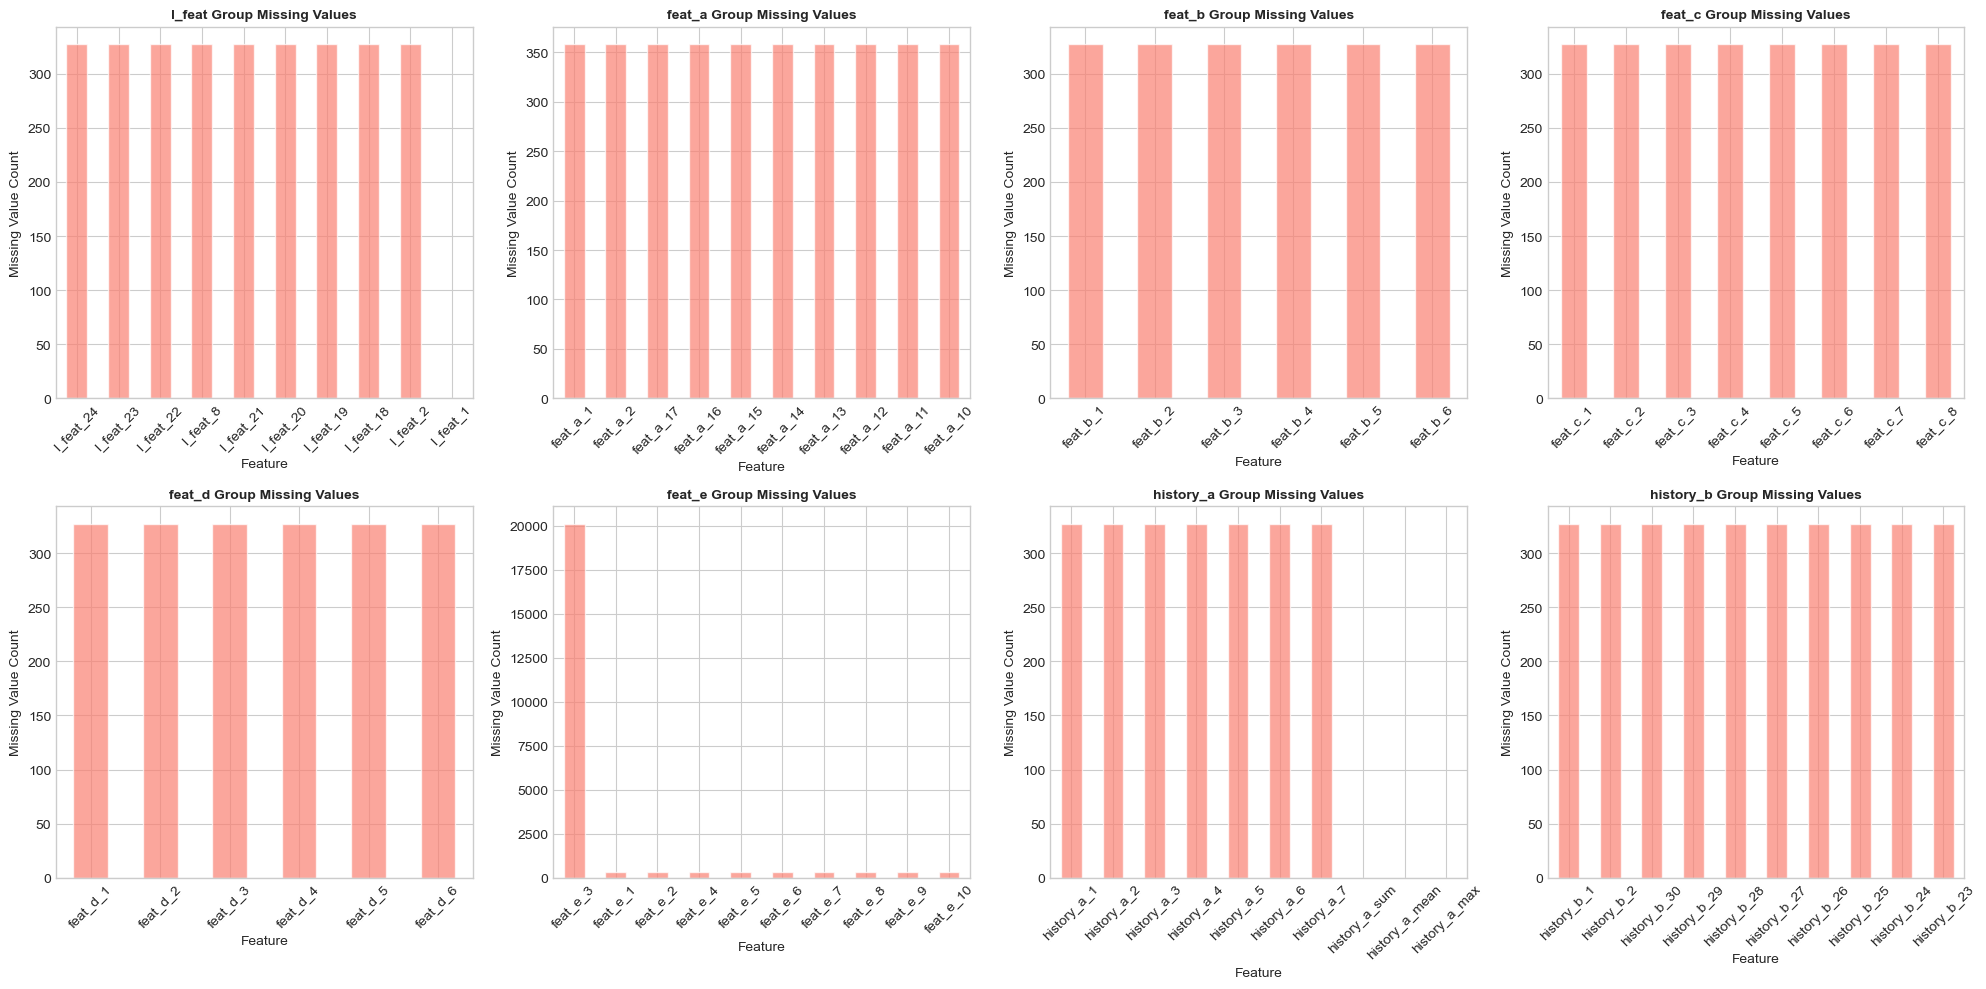

In [72]:

# ========================================
# 📊 2. 피처 그룹 분석
# ========================================

print("\n" + "="*60)
print("📊 피처 그룹 분석")
print("="*60)

# 피처 그룹 분석
feature_groups = {
    'l_feat': [col for col in df.columns if col.startswith('l_feat_')],
    'feat_a': [col for col in df.columns if col.startswith('feat_a_')],
    'feat_b': [col for col in df.columns if col.startswith('feat_b_')],
    'feat_c': [col for col in df.columns if col.startswith('feat_c_')],
    'feat_d': [col for col in df.columns if col.startswith('feat_d_')],
    'feat_e': [col for col in df.columns if col.startswith('feat_e_')],
    'history_a': [col for col in df.columns if col.startswith('history_a_')],
    'history_b': [col for col in df.columns if col.startswith('history_b_')]
}

print("🔍 Feature Group Composition:")
for group, features in feature_groups.items():
    missing_count = df[features].isnull().sum().sum()
    print(f"   {group}: {len(features)} features, Missing values: {missing_count:,}")

# Group-wise 결측치 패턴 시각화
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (group, features) in enumerate(feature_groups.items()):
    if i < len(axes):
        missing_pattern = df[features].isnull().sum().sort_values(ascending=False)
        if len(missing_pattern) > 0:
            missing_pattern.head(10).plot(kind='bar', ax=axes[i], color='salmon', alpha=0.7)
            axes[i].set_title(f'{group} Group Missing Values', fontsize=10, fontweight='bold')
            axes[i].set_xlabel('Feature')
            axes[i].set_ylabel('Missing Value Count')
            axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


🔗 타겟과 피처간 상관관계 분석
📊 타겟과 상관관계 TOP 20:
    1. history_a_max       :   0.0755 (절대값: 0.0755)
    2. history_a_1         :   0.0688 (절대값: 0.0688)
    3. inv_ctr_encoded     :   0.0668 (절대값: 0.0668)
    4. history_a_3         :   0.0649 (절대값: 0.0649)
    5. history_a_2         :  -0.0628 (절대값: 0.0628)
    6. history_a_5         :  -0.0622 (절대값: 0.0622)
    7. history_b_2         :   0.0598 (절대값: 0.0598)
    8. history_b_30        :   0.0590 (절대값: 0.0590)
    9. history_b_max       :   0.0580 (절대값: 0.0580)
   10. history_b_1         :   0.0513 (절대값: 0.0513)
   11. history_b_10        :   0.0495 (절대값: 0.0495)
   12. feat_b_4            :  -0.0460 (절대값: 0.0460)
   13. history_b_mean      :   0.0458 (절대값: 0.0458)
   14. history_b_sum       :   0.0458 (절대값: 0.0458)
   15. history_b_17        :   0.0456 (절대값: 0.0456)
   16. feat_d_3            :  -0.0449 (절대값: 0.0449)
   17. history_b_15        :   0.0448 (절대값: 0.0448)
   18. feat_e_1            :  -0.0444 (절대값: 0.0444)
   19. history_b_20       

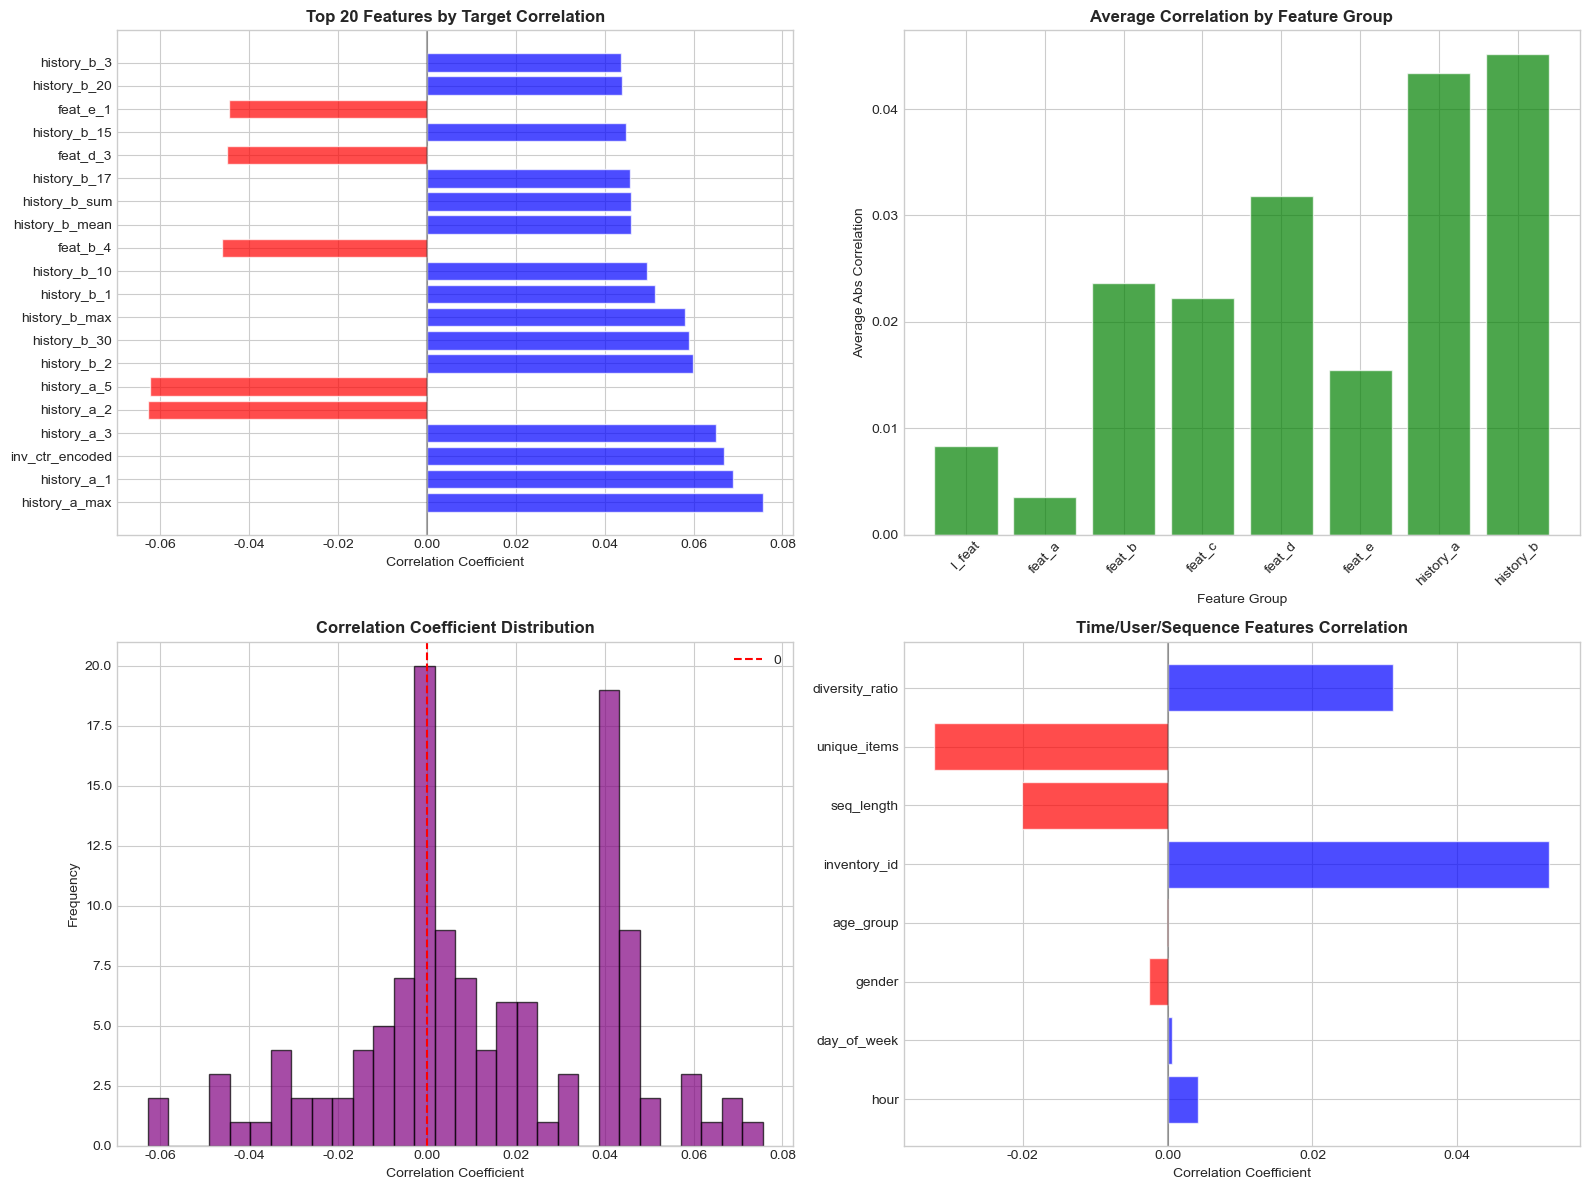

In [73]:
# ========================================
# 3. 타겟과 피처간 상관관계 분석
# ========================================

print("\n" + "=" * 60)
print("🔗 타겟과 피처간 상관관계 분석")
print("=" * 60)

# 숫자형 피처 식별 (타겟 제외)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != "clicked"]

# 상관관계 계산 (결측치 처리)
correlations = []
for feature in numeric_features:
    if df[feature].notna().sum() > 100:  # 충분한 데이터가 있는 경우에만
        corr = df[["clicked", feature]].corr().iloc[0, 1]
        if not np.isnan(corr):
            correlations.append((feature, abs(corr), corr))

correlations.sort(key=lambda x: x[1], reverse=True)

print("📊 타겟과 상관관계 TOP 20:")
for i, (feature, abs_corr, corr) in enumerate(correlations[:20]):
    print(f"   {i+1:2d}. {feature:20s}: {corr:8.4f} (절대값: {abs_corr:.4f})")

# 상관관계 시각화
top_features = [item[0] for item in correlations[:20]]
corr_values = [item[2] for item in correlations[:20]]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 상관관계 피처 탑 20
axes[0, 0].barh(
    range(len(top_features)),
    corr_values,
    color=["red" if x < 0 else "blue" for x in corr_values],
    alpha=0.7
)
axes[0, 0].set_yticks(range(len(top_features)))
axes[0, 0].set_yticklabels(top_features)
axes[0, 0].set_title("Top 20 Features by Target Correlation", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Correlation Coefficient")
axes[0, 0].axvline(0, color="black", linestyle="-", alpha=0.3)

# 2. 피처 그룹별 평균 상관관계
group_correlations = {}
for group, features in feature_groups.items():
    group_corrs = []
    for feature in features:
        if feature in [item[0] for item in correlations]:
            corr_val = next(item[2] for item in correlations if item[0] == feature)
            group_corrs.append(abs(corr_val))
    if group_corrs:
        group_correlations[group] = np.mean(group_corrs)

if group_correlations:
    groups = list(group_correlations.keys())
    values = list(group_correlations.values())
    axes[0, 1].bar(groups, values, color="green", alpha=0.7)
    axes[0, 1].set_title("Average Correlation by Feature Group", fontsize=12, fontweight="bold")
    axes[0, 1].set_xlabel("Feature Group")
    axes[0, 1].set_ylabel("Average Abs Correlation")
    axes[0, 1].tick_params(axis="x", rotation=45)

# 3. 상관관계 분포
all_corr_values = [item[2] for item in correlations]
axes[1, 0].hist(all_corr_values, bins=30, color="purple", alpha=0.7, edgecolor="black")
axes[1, 0].set_title("Correlation Coefficient Distribution", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Correlation Coefficient")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].axvline(0, color="red", linestyle="--", label="0")
axes[1, 0].legend()

# 4. 시간/사용자 피처 상관관계
time_user_features = [
    "hour", "day_of_week", "gender", "age_group",
    "inventory_id", "seq_length", "unique_items", "diversity_ratio"
]
time_user_corrs = []
time_user_names = []

for feature in time_user_features:
    if feature in df.columns:
        corr = df[["clicked", feature]].corr().iloc[0, 1]
        if not np.isnan(corr):
            time_user_corrs.append(corr)
            time_user_names.append(feature)

if time_user_corrs:
    axes[1, 1].barh(
        range(len(time_user_names)),
        time_user_corrs,
        color=["red" if x < 0 else "blue" for x in time_user_corrs],
        alpha=0.7
    )
    axes[1, 1].set_yticks(range(len(time_user_names)))
    axes[1, 1].set_yticklabels(time_user_names)
    axes[1, 1].set_title("Time/User/Sequence Features Correlation", fontsize=12, fontweight="bold")
    axes[1, 1].set_xlabel("Correlation Coefficient")
    axes[1, 1].axvline(0, color="black", linestyle="-", alpha=0.3)

plt.tight_layout()
plt.show()

In [74]:

# ========================================
# 🔥 4. 피처 중요성 분석 (Statistical Methods)
# ========================================

print("\n" + "="*60)
print("🔥 피처 중요성 분석")
print("="*60)

# 범주형 변수에 대한 카이제곱 검정
categorical_features = ['gender', 'age_group', 'day_of_week', 'hour', 'inventory_id']
chi2_results = []

for feature in categorical_features:
    if feature in df.columns:
        # 결측값 제거 및 교차표 생성
        temp_df = df[[feature, 'clicked']].dropna()
        if len(temp_df) > 0:
            contingency = pd.crosstab(temp_df[feature], temp_df['clicked'])
            if contingency.shape[0] > 1 and contingency.shape[1] > 1:
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                chi2_results.append((feature, chi2, p_value))

chi2_results.sort(key=lambda x: x[1], reverse=True)

print("📊 Chi-square Test Results for Categorical Features:")
for feature, chi2_stat, p_val in chi2_results:
    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"   {feature:15s}: χ² = {chi2_stat:10.2f}, p-value = {p_val:.6f} {significance}")

# 수치형 변수의 평균 차이 분석 (Clicked vs Non-Clicked)
print(f"\n📊 Numeric Feature Mean Difference (Clicked vs Non-Clicked) - Top 15:")
feature_diffs = []

for feature in top_features[:15]:  # Only top correlated features
    clicked_mean = df[df['clicked'] == 1][feature].mean()
    not_clicked_mean = df[df['clicked'] == 0][feature].mean()
    diff = clicked_mean - not_clicked_mean
    feature_diffs.append((feature, clicked_mean, not_clicked_mean, diff))

feature_diffs.sort(key=lambda x: abs(x[3]), reverse=True)

for feature, click_mean, no_click_mean, diff in feature_diffs:
    print(f"   {feature:20s}: Clicked {click_mean:8.4f} vs Non-Clicked {no_click_mean:8.4f} (Diff: {diff:8.4f})")


🔥 피처 중요성 분석
📊 Chi-square Test Results for Categorical Features:
   inventory_id   : χ² =     891.48, p-value = 0.000000 ***
   age_group      : χ² =     259.49, p-value = 0.000000 ***
   hour           : χ² =      57.83, p-value = 0.000078 ***
   day_of_week    : χ² =      21.54, p-value = 0.001468 **
   gender         : χ² =       1.23, p-value = 0.266441 

📊 Numeric Feature Mean Difference (Clicked vs Non-Clicked) - Top 15:
   history_b_sum       : Clicked  15.3618 vs Non-Clicked   6.2720 (Diff:   9.0898)
   history_b_max       : Clicked   1.5967 vs Non-Clicked   0.6336 (Diff:   0.9630)
   history_b_2         : Clicked   1.5008 vs Non-Clicked   0.5859 (Diff:   0.9150)
   history_b_1         : Clicked   0.9236 vs Non-Clicked   0.4180 (Diff:   0.5056)
   history_b_30        : Clicked   0.5439 vs Non-Clicked   0.2109 (Diff:   0.3330)
   history_b_mean      : Clicked   0.5121 vs Non-Clicked   0.2091 (Diff:   0.3030)
   history_a_max       : Clicked   0.3503 vs Non-Clicked   0.1265 (Diff

# Task: 상호작용 피처 생성

`train_sample_processed` DataFrame에서 'age_group'과 'gender' 간의 상호작용 피처를 생성하여 CTR에 대한 결합 효과를 탐구합니다.

## 피처 엔지니어링 - 상호작용 피처

### 목표
'연령_그룹'과 '젠더' 간의 상호작용 피처를 생성하여 CTR에 대한 결합 효과를 탐구합니다. 연령과 성별의 고유한 조합을 포착하는 새로운 카테고리 표현을 만들고, `train_sample_processed` DataFrame에 추가합니다.


### 접근 방법
'연령_그룹'과 '젠더'가 CTR에 미치는 복합적 영향을 분석하기 위해 상호작용 피처를 생성하고, 각 고유 조합별 CTR을 계산한 뒤 상위 5개·하위 5개 그룹을 출력합니다.



In [75]:
import pandas as pd

# 'clicked' 열을 정수형으로 변환하여 일관된 계산을 위해 준비
train_sample_processed['clicked'] = train_sample_processed['clicked'].astype(int)

# 1. 상호 피처 만들기
train_sample_processed['age_gender_interaction'] = \
    train_sample_processed['age_group'].astype(str) + '_' + \
    train_sample_processed['gender'].astype(str)

# 2. 각 고유한 age_gender_interaction에 대한 CTR 계산
age_gender_ctr = train_sample_processed.groupby('age_gender_interaction')['clicked'].mean().reset_index()
age_gender_ctr.columns = ['age_gender_interaction', 'CTR']

# 상위 그룹과 하위 그룹 판독을 위한 정렬
age_gender_ctr_sorted = age_gender_ctr.sort_values(by='CTR', ascending=False)

print("Top 5 Age-Gender Interaction Groups by CTR:")
print(age_gender_ctr_sorted.head(5))

print("\nBottom 5 Age-Gender Interaction Groups by CTR:")
print(age_gender_ctr_sorted.tail(5))

Top 5 Age-Gender Interaction Groups by CTR:
   age_gender_interaction       CTR
1                 1.0_2.0  0.097222
0                 1.0_1.0  0.083871
16              None_None  0.033639
3                 2.0_2.0  0.028650
5                 3.0_2.0  0.027255

Bottom 5 Age-Gender Interaction Groups by CTR:
   age_gender_interaction       CTR
6                 4.0_1.0  0.016878
8                 5.0_1.0  0.016209
10                6.0_1.0  0.016120
13                7.0_2.0  0.015275
11                6.0_2.0  0.014406


### 접근 방법
'age_gender_interaction' 피처의 종합 분석을 위해, 상위 10개·하위 10개 상호작용 그룹의 CTR을 막대 그래프로 시각화합니다.



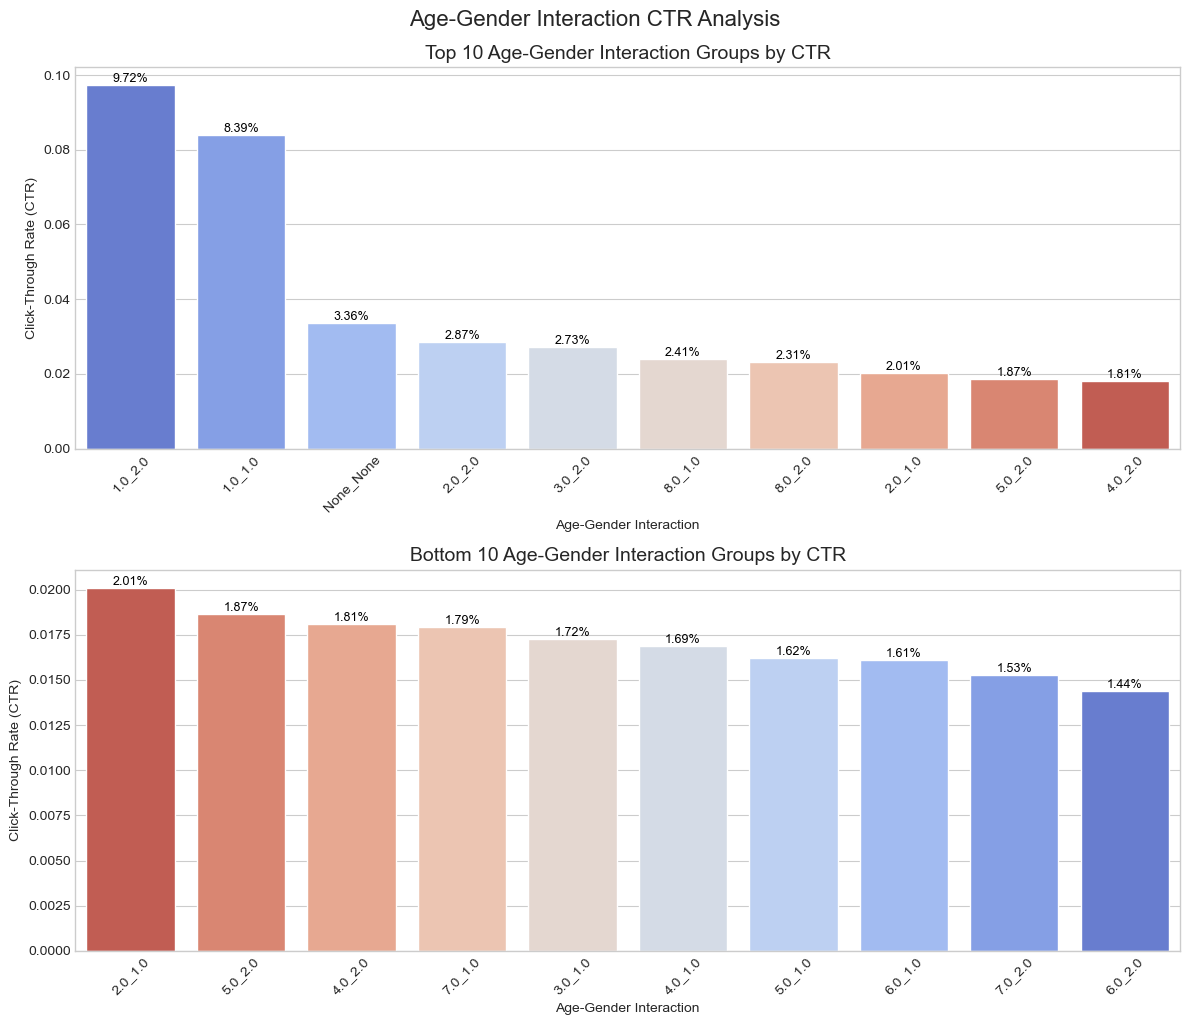

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 상위 10개와 하위 10개 상호작용 그룹 가져오기
top_10_interactions = age_gender_ctr_sorted.head(10)
bottom_10_interactions = age_gender_ctr_sorted.tail(10)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# FutureWarning 방지를 위해 이산 색상 팔레트 생성
num_top = len(top_10_interactions)
colors_top = sns.color_palette("coolwarm", n_colors=num_top)

num_bottom = len(bottom_10_interactions)
colors_bottom = sns.color_palette("coolwarm_r", n_colors=num_bottom)

# 상위 10개 상호작용 그룹 그래프
sns.barplot(
    x='age_gender_interaction', 
    y='CTR', 
    data=top_10_interactions, 
    hue='age_gender_interaction', 
    palette=colors_top, 
    ax=axes[0], 
    legend=False
)
#CTR 기준 상위 10개 연령-성별 상호작용 그룹
axes[0].set_title('Top 10 Age-Gender Interaction Groups by CTR', fontsize=14)
axes[0].set_xlabel('Age-Gender Interaction')  
axes[0].set_ylabel('Click-Through Rate (CTR)')  
axes[0].tick_params(axis='x', rotation=45)
for i, row in enumerate(top_10_interactions.itertuples()):
    axes[0].text(i, row.CTR, f'{row.CTR:.2%}', color='black', ha="center", va="bottom", fontsize=9)

# 하위 10개 상호작용 그룹 그래프
sns.barplot(
    x='age_gender_interaction', 
    y='CTR', 
    data=bottom_10_interactions, 
    hue='age_gender_interaction', 
    palette=colors_bottom, 
    ax=axes[1], 
    legend=False
)
#CTR 기준 하위 10개 연령-성별 상호작용 그룹
axes[1].set_title('Bottom 10 Age-Gender Interaction Groups by CTR', fontsize=14)
axes[1].set_xlabel('Age-Gender Interaction')  
axes[1].set_ylabel('Click-Through Rate (CTR)')  
axes[1].tick_params(axis='x', rotation=45)
for i, row in enumerate(bottom_10_interactions.itertuples()):
    axes[1].text(i, row.CTR, f'{row.CTR:.2%}', color='black', ha="center", va="bottom", fontsize=9)
#연령-성별 상호작용별 CTR 분석
plt.tight_layout()
plt.suptitle('Age-Gender Interaction CTR Analysis', y=1.02, fontsize=16)
plt.show()

### 접근 방법
연령·성별 상호작용 피처 분석을 완료했습니다. 로드맵에 따라 시간 기반 피처 엔지니어링을 진행하며, 먼저 'hour' 컬럼에서 'time_of_day' 피처를 생성합니다. 시간을 아침/오후/저녁/밤 등으로 구간화하여 사용자 행동 패턴을 파악합니다.



In [77]:
import pandas as pd

# 'hour' 열을 정수형으로 변환하여 올바른 비교를 위해 준비
train_sample_processed['hour'] = train_sample_processed['hour'].astype(int)

# 범주화된 시간으로 시간대 구분 함수 정의
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

#  'time_of_day' feature 만들기
train_sample_processed['time_of_day'] = train_sample_processed['hour'].apply(get_time_of_day)

print("Value counts for new 'time_of_day' feature:")
print(train_sample_processed['time_of_day'].value_counts())


Value counts for new 'time_of_day' feature:
time_of_day
Morning      70375
Night        45381
Afternoon    44801
Evening      39443
Name: count, dtype: int64


### 접근 방법
`time_of_day` 피처 생성 완료. 이어서 `day_of_week`에서 **평일/주말** 분류 피처(`weekday_weekend`)를 생성하여 `train_sample_processed`에 추가하고, 사용자 행동 패턴을 더 명확히 파악합니다.



In [78]:
import pandas as pd

# 'day_of_week' 컬럼을 int로 변환하여 비교에 적합하게 만듦
train_sample_processed['day_of_week'] = train_sample_processed['day_of_week'].astype(int)

# day_of_week를 평일/주말로 분류하는 함수 정의
def get_weekday_weekend(day):
    # 1=월요일, 7=일요일 가정
    if day >= 1 and day <= 5:
        return 'Weekday'  # 평일
    elif day == 6 or day == 7:
        return 'Weekend'  # 주말
    else:
        return 'Unknown'  # 알 수 없음

# 'weekday_weekend' 피처 생성
train_sample_processed['weekday_weekend'] = train_sample_processed['day_of_week'].apply(get_weekday_weekend)

print("새 'weekday_weekend' 피처의 값 분포:")
print(train_sample_processed['weekday_weekend'].value_counts())

새 'weekday_weekend' 피처의 값 분포:
weekday_weekend
Weekday    143026
Weekend     56974
Name: count, dtype: int64


---
## 5. 상관관계 분석 <a id='sec5'></a>

# Task: 상관관계 행렬 분석

`train_sample_processed` DataFrame의 숫자형 피처와 타겟 변수 'clicked' 간의 상관관계 행렬을 계산하고, 피처 간 관계를 파악하기 위해 히트맵으로 시각화합니다.

## 상관관계 행렬 계산

### 목표
`train_sample_processed`의 숫자형 피처들과 타겟 변수 `clicked` 간 상관관계 행렬을 계산하고, 히트맵으로 시각화하여 피처 간 관계를 파악합니다.


### 접근 방법
숫자형 피처와 'clicked' 타겟 변수 간 관계를 분석합니다. `train_sample_processed`에서 'clicked'를 포함한 숫자형 컬럼을 선정하고 상관관계를 계산한 뒤, `seaborn.heatmap`으로 주석과 제목을 포함해 시각화합니다.



상관관계 분석 피처: ['clicked', 'gender', 'age_group', 'day_of_week', 'hour', 'l_feat_1', 'l_feat_2', 'feat_e_1', 'feat_e_2', 'history_b_1', 'history_b_2']
상관관계 데이터프레임 크기: (199673, 11)


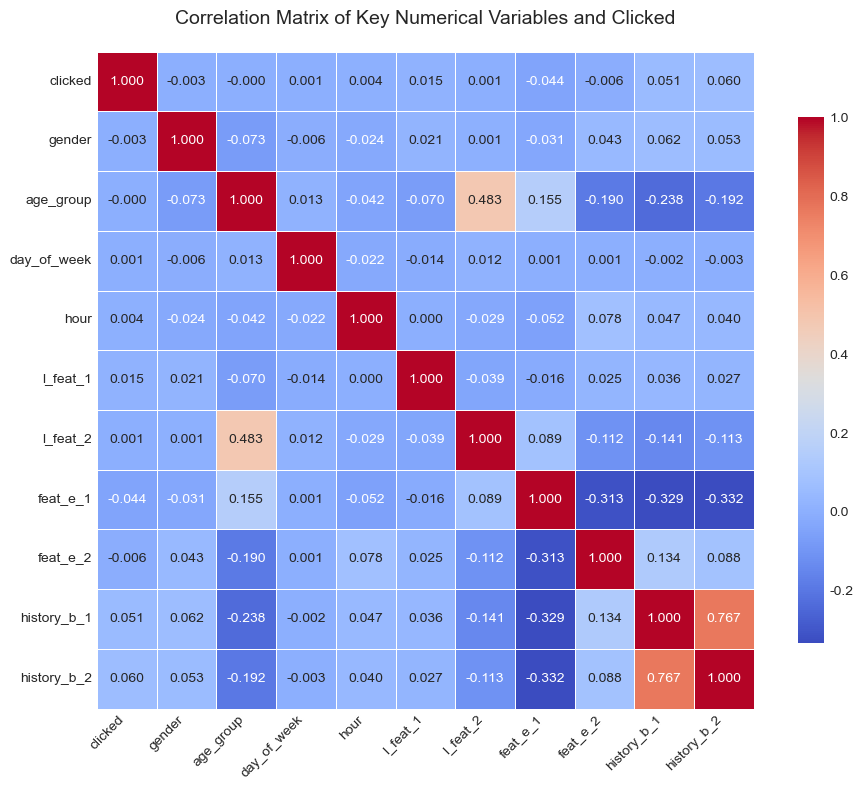


Clicked와의 상관관계 (절댓값 기준 상위):
clicked        1.000000
history_b_2    0.059850
history_b_1    0.051272
feat_e_1       0.044388
l_feat_1       0.015401
feat_e_2       0.005762
hour           0.003869
gender         0.002525
l_feat_2       0.000876
day_of_week    0.000662
age_group      0.000037
Name: clicked, dtype: float64


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# 1. 'clicked'와 상관관계가 높은 특정 숫자형 피처 선택
selected_features = [
    'clicked', 'gender', 'age_group', 'day_of_week', 'hour',
    'l_feat_1', 'l_feat_2', 'feat_e_1', 'feat_e_2',
    'history_b_1', 'history_b_2'
]

# 2. 선택된 피처만 포함한 상관관계 데이터프레임 생성
correlation_df = train_sample_processed[selected_features].copy()

# 선택된 컬럼이 존재하고 숫자형인지 확인
available_features = [col for col in selected_features if col in correlation_df.columns]
correlation_df = correlation_df[available_features]

# 선택된 피처에 NaN이 있는 행 제거
correlation_df = correlation_df.dropna()

print(f"상관관계 분석 피처: {list(correlation_df.columns)}")
print(f"상관관계 데이터프레임 크기: {correlation_df.shape}")

# 3. 상관관계 행렬 계산
corr_matrix = correlation_df.corr()

# 4. 가독성 좋은 작은 히트맵 생성
plt.figure(figsize=(10, 8))

# 5. 가독성 개선된 시각화
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    square=True
)

plt.title('Correlation Matrix of Key Numerical Variables and Clicked', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. 'clicked'와의 상관관계 빠른 참조용 출력
clicked_corrs = corr_matrix['clicked'].sort_values(ascending=False)
print("\nClicked와의 상관관계 (절댓값 기준 상위):")
print(clicked_corrs.abs().sort_values(ascending=False))

## 모델링을 위한 데이터 준비

### 목표
로지스틱 회귀 학습을 위해 `train_sample_processed`에서 필요한 피처를 선택하고, 범주형 피처(`time_of_day`, `weekday_weekend`, `age_gender_interaction` 등)를 원-핫 인코딩하여 수치형으로 변환합니다. 이후 학습·검증 세트로 분리합니다.


---
## 6. 모델링 <a id='sec6'></a>

### 6a. 로지스틱 회귀

### 접근 방법
피처 선정, 범주형 원-핫 인코딩, 학습·검증 분리를 수행합니다. 신규 생성 피처를 포함한 관련 피처와 타겟 변수를 선정한 뒤 전처리를 진행합니다.



In [80]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 숫자형 피처와 범주형 피처 정의
# 원래 숫자형이지만 원-핫 인코딩을 위해 범주형으로 처리해야 하는 피처들
categorical_features = ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour']

# 엔지니어링된 범주형 피처들 추가
categorical_features.extend(['time_of_day', 'weekday_weekend', 'age_gender_interaction'])

# 'l_feat_'와 'feat_e_' 컬럼들은 숫자형이므로 직접 포함
l_feat_cols = [col for col in train_sample_processed.columns if col.startswith('l_feat_')]
feat_e_cols = [col for col in train_sample_processed.columns if col.startswith('feat_e_')]

# 기타 숫자형 피처들 (history_b_ 피처들 등)
history_b_cols = [col for col in train_sample_processed.columns if col.startswith('history_b_')]

# 타겟 변수
target_variable = 'clicked'

# 모든 피처 컬럼 합치기
all_features = categorical_features + l_feat_cols + feat_e_cols + history_b_cols

# 중복 제거하면서 순서 유지 (set()은 순서 섞임)
all_features = list(dict.fromkeys(all_features))

# 타겟 변수가 피처 리스트에 포함되지 않도록 제거
if target_variable in all_features:
    all_features.remove(target_variable)

# 데이터프레임에서 피처와 타겟 선택
X = train_sample_processed[all_features].copy()
y = train_sample_processed[target_variable].copy()

# 범주형 컬럼들을 'category' 타입으로 변환하여 원-핫 인코딩 준비
for col in categorical_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

# 범주형 피처 원-핫 인코딩 수행
X_encoded = pd.get_dummies(X, columns=categorical_features, dummy_na=False)

print(f"인코딩 전 NaN 개수 (원본): {X_encoded.isnull().sum().sum()}")
print(f"원본 피처 수: {X.shape[1]}")
print(f"인코딩 후 피처 수: {X_encoded.shape[1]}")
print(f"인코딩된 피처 처음 5행:\n{X_encoded.head()}")

# 데이터 누수 방지를 위해 TRAIN 통계만 사용해 결측치 보간 (먼저 분할)
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 훈련 데이터의 평균으로 결측치 보간 (pandas는 NaN 자동 제외)
train_impute_means = X_train.mean()
X_train = X_train.fillna(train_impute_means)
X_val = X_val.fillna(train_impute_means)

print(f"보간 후 X_train NaN 개수: {X_train.isnull().sum().sum()}")
print(f"보간 후 X_val NaN 개수: {X_val.isnull().sum().sum()}")

print(f"\nX_train 크기: {X_train.shape}")
print(f"X_val 크기: {X_val.shape}")
print(f"y_train 크기: {y_train.shape}")
print(f"y_val 크기: {y_val.shape}")

print("\ny_train 클래스 분포:")
print(y_train.value_counts(normalize=True))
print("\ny_val 클래스 분포:")
print(y_val.value_counts(normalize=True))

인코딩 전 NaN 개수 (원본): 35810
원본 피처 수: 75
인코딩 후 피처 수: 149
인코딩된 피처 처음 5행:
   l_feat_1  l_feat_2  l_feat_3  l_feat_4  l_feat_5  l_feat_6  l_feat_7  \
0       2.0       2.0       3.0      20.0     443.0     204.0      21.0   
1       1.0       2.0       1.0       7.0     625.0     551.0      90.0   
2       2.0       1.0       2.0       7.0     394.0     301.0     192.0   
3       2.0       2.0       2.0       7.0     355.0     414.0     167.0   
4       2.0       2.0       2.0       7.0      34.0     536.0     104.0   

   l_feat_8  l_feat_9  l_feat_10  ...  age_gender_interaction_4.0_2.0  \
0       2.0     181.0       40.0  ...                           False   
1       2.0      11.0      149.0  ...                           False   
2       2.0      47.0       94.0  ...                           False   
3       2.0     200.0       67.0  ...                           False   
4       2.0     291.0      121.0  ...                           False   

   age_gender_interaction_5.0_1.0  age_gen

## 로지스틱 회귀 모델 구현 및 학습

### 목표
로지스틱 회귀 모델을 초기화하고 학습 데이터로 학습시킵니다. 데이터 불균형을 고려하여 `class_weight='balanced'` 옵션을 적용합니다.


### 접근 방법
`LogisticRegression` 클래스를 사용하며, `class_weight='balanced'`로 불균형을 처리하고 `random_state=42`로 재현성을 확보합니다. 준비된 `X_train`, `y_train`으로 모델을 학습시킵니다.



In [81]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model with class_weight='balanced'
# and random_state for reproducibility
log_reg_model = LogisticRegression(class_weight='balanced', random_state=42, solver='saga', max_iter=200, n_jobs=-1)

# Train the model using the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully with class_weight='balanced'.")

Logistic Regression model trained successfully with class_weight='balanced'.


## 로지스틱 회귀 모델 평가

### 목표
학습된 로지스틱 회귀 모델의 성능을 검증 세트에서 평가합니다. 불균형 데이터셋에 적합한 AUC, 정밀도, 재현율, F1-스코어 등의 지표를 사용합니다.


### 접근 방법
검증 세트에 대해 예측 확률과 클래스 레이블을 계산한 뒤, ROC AUC, 분류 리포트(classification report), 혼동 행렬(confusion matrix)을 산출하여 성능을 평가합니다.



ROC AUC 점수: 0.5581

분류 보고서:
              precision    recall  f1-score   support

           0       0.98      0.55      0.71     39239
           1       0.02      0.53      0.04       761

    accuracy                           0.55     40000
   macro avg       0.50      0.54      0.38     40000
weighted avg       0.97      0.55      0.69     40000


혼동 행렬:
[[21674 17565]
 [  358   403]]


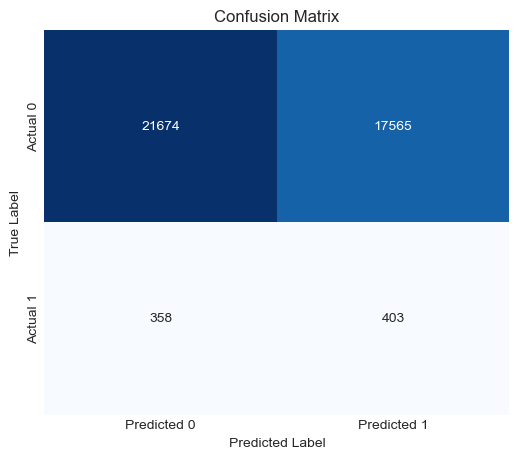

In [82]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import numpy as np

# 1. 양성 클래스에 대한 예측 확률 계산
y_pred_proba = log_reg_model.predict_proba(X_val)[:, 1]

# 2. 클래스 레이블 예측
y_pred = log_reg_model.predict(X_val)

# 3. ROC AUC 점수 계산 및 출력
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f"ROC AUC 점수: {roc_auc:.4f}")

# 4. 분류 보고서 출력
print("\n분류 보고서:")
print(classification_report(y_val, y_pred))

# 5. 혼동 행렬 계산 및 출력
conf_matrix = confusion_matrix(y_val, y_pred)
print("\n혼동 행렬:")
print(conf_matrix)

# 선택사항: 혼동 행렬 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

3-Fold CV ROC AUC: 0.5647 ± 0.0020
3-Fold CV PR-AUC:  0.0256 ± 0.0015

Hold-out Validation PR-AUC: 0.0273
Best F1 on validation: 0.0521 at threshold = 0.5445

Confusion matrix @ default threshold (0.5):
[[21674 17565]
 [  358   403]]

Confusion matrix @ F1-optimal threshold (0.5445):
[[32677  6562]
 [  565   196]]


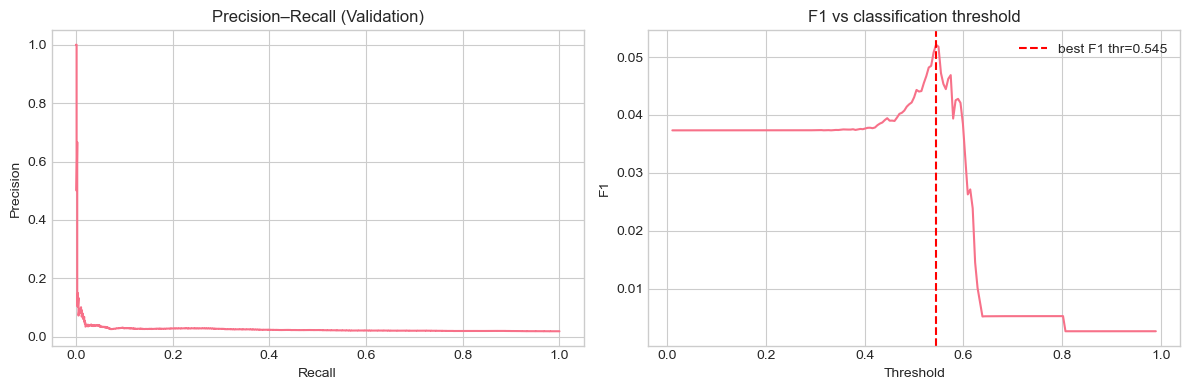

In [83]:
# --- 2) Stratified K-Fold CV, PR 곡선, F1 최적 임계값 (불균형 데이터용) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    confusion_matrix,
)

# 전체 인코딩 데이터 기준 5-Fold (fold마다 학습 fold 평균으로만 결측치 처리)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 논문 제출 시 5로 변경
cv_roc, cv_pr = [], []
for tr_idx, va_idx in cv.split(X_encoded, y):
    X_tr, X_va = X_encoded.iloc[tr_idx], X_encoded.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    m = X_tr.mean()
    X_tr, X_va = X_tr.fillna(m), X_va.fillna(m)
    clf = LogisticRegression(
        class_weight="balanced", random_state=42, solver="saga", max_iter=200, n_jobs=-1
    )
    clf.fit(X_tr, y_tr)
    p = clf.predict_proba(X_va)[:, 1]
    cv_roc.append(roc_auc_score(y_va, p))
    cv_pr.append(average_precision_score(y_va, p))

print(f"3-Fold CV ROC AUC: {np.mean(cv_roc):.4f} ± {np.std(cv_roc):.4f}")
print(f"3-Fold CV PR-AUC:  {np.mean(cv_pr):.4f} ± {np.std(cv_pr):.4f}")

# 검증 세트: 이미 학습된 log_reg_model 기준 PR 곡선 + 임계값 튜닝
y_proba_val = log_reg_model.predict_proba(X_val)[:, 1]
pr_auc_val = average_precision_score(y_val, y_proba_val)
prec, rec, thr = precision_recall_curve(y_val, y_proba_val)
print(f"\nHold-out Validation PR-AUC: {pr_auc_val:.4f}")

thresholds = np.linspace(0.01, 0.99, 199)
best_f1, best_t = 0.0, 0.5
for t in thresholds:
    pred_t = (y_proba_val >= t).astype(int)
    f1 = f1_score(y_val, pred_t, zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f"Best F1 on validation: {best_f1:.4f} at threshold = {best_t:.4f}")

pred_default = log_reg_model.predict(X_val)
pred_tuned = (y_proba_val >= best_t).astype(int)
print("\nConfusion matrix @ default threshold (0.5):")
print(confusion_matrix(y_val, pred_default))
print(f"\nConfusion matrix @ F1-optimal threshold ({best_t:.4f}):")
print(confusion_matrix(y_val, pred_tuned))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rec, prec)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision–Recall (Validation)")
axes[1].plot(thresholds, [f1_score(y_val, (y_proba_val >= t).astype(int), zero_division=0) for t in thresholds])
axes[1].axvline(best_t, color="r", linestyle="--", label=f"best F1 thr={best_t:.3f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1")
axes[1].set_title("F1 vs classification threshold")
axes[1].legend()
plt.tight_layout()
plt.show()

### 6b. Ablation Study & SHAP (XGBoost)

Ablation Study — 3-Fold 층화 교차검증 (로지스틱 회귀)
  [User only                ]  n=  27  AP=0.0194+/-0.0006  AUC=0.5121+/-0.0049
  [Env only                 ]  n=  55  AP=0.0249+/-0.0028  AUC=0.5730+/-0.0214
  [User + Env               ]  n=  82  AP=0.0226+/-0.0007  AUC=0.5390+/-0.0021
  [Full                     ]  n= 149  AP=0.0256+/-0.0015  AUC=0.5647+/-0.0020


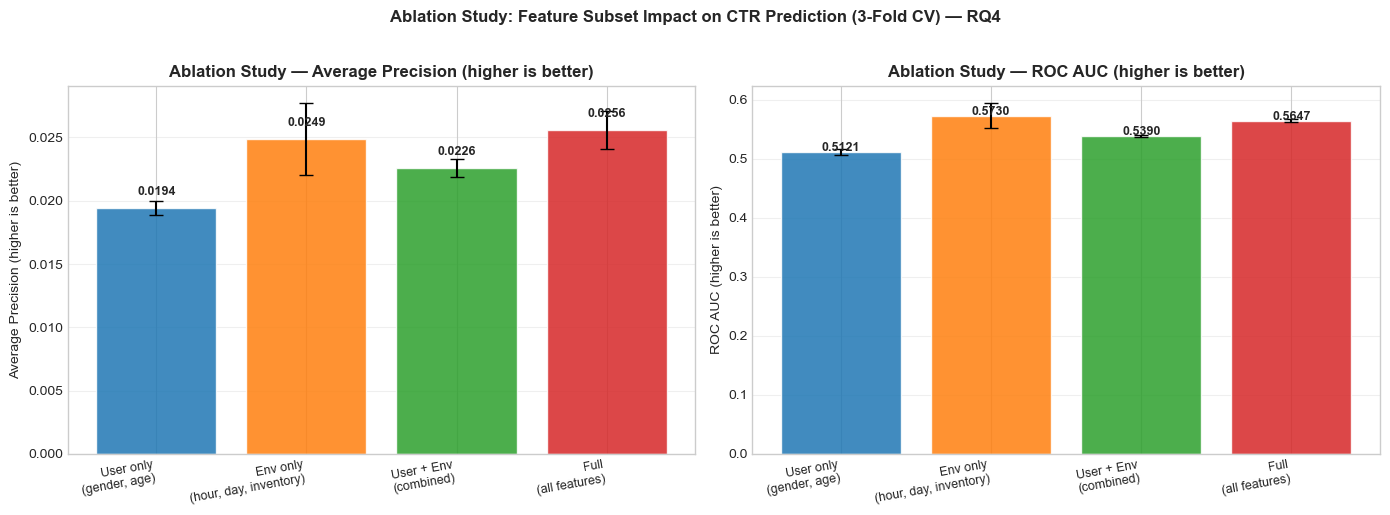


RQ4 요약:
  사용자만     AP=0.0194
  환경만      AP=0.0249
  사용자+환경 AP=0.0226  (사용자 대비: +0.0032, 환경 대비: -0.0023)
  -> 피처 조합이 더 강한 단일 그룹보다 개선되지 않음


In [84]:
# ================================================================
# Ablation Study: 피처 서브셋 비교 (3-Fold CV)
# RQ4: 사용자 + 환경 피처 조합이 CTR 예측을 개선하는가?
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score

# ── 원-핫 인코딩된 컬럼명을 사용한 피처 서브셋 정의 ──
# X_encoded, y는 데이터 준비 셀에서 사용 가능
user_raw = ['gender', 'age_group', 'age_gender_interaction']
env_raw  = ['hour', 'day_of_week', 'inventory_id', 'time_of_day', 'weekday_weekend']

user_cols = [c for c in X_encoded.columns
             if any(c.startswith(f + '_') or c == f for f in user_raw)]
env_cols  = [c for c in X_encoded.columns
             if any(c.startswith(f + '_') or c == f for f in env_raw)]
all_cols  = list(X_encoded.columns)

subsets = {
    'User only\n(gender, age)':           user_cols,
    'Env only\n(hour, day, inventory)':   env_cols,
    'User + Env\n(combined)':             list(dict.fromkeys(user_cols + env_cols)),
    'Full\n(all features)':               all_cols,
}

cv_abl = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 논문 제출 시 5로 변경
abl_rows = []

print("=" * 65)
print("Ablation Study — 3-Fold 층화 교차검증 (로지스틱 회귀)")
print("=" * 65)

for label, cols in subsets.items():
    valid_cols = [c for c in cols if c in X_encoded.columns]
    if not valid_cols:
        print(f"[SKIP] {label.strip()}: 유효 컬럼 없음")
        continue
    X_sub = X_encoded[valid_cols]
    ap_folds, auc_folds = [], []
    for tr_i, va_i in cv_abl.split(X_sub, y):
        Xtr, Xva = X_sub.iloc[tr_i], X_sub.iloc[va_i]
        ytr, yva = y.iloc[tr_i],     y.iloc[va_i]
        means = Xtr.mean()
        Xtr, Xva = Xtr.fillna(means), Xva.fillna(means)
        clf = LogisticRegression(
            class_weight='balanced', random_state=42,
            solver='saga', max_iter=200, n_jobs=-1
        )
        clf.fit(Xtr, ytr)
        prob = clf.predict_proba(Xva)[:, 1]
        ap_folds.append(average_precision_score(yva, prob))
        auc_folds.append(roc_auc_score(yva, prob))
    abl_rows.append({
        'Feature Set': label.replace('\n', ' '),
        'n_features':  len(valid_cols),
        'AP':          np.mean(ap_folds),
        'AP_std':      np.std(ap_folds),
        'AUC':         np.mean(auc_folds),
        'AUC_std':     np.std(auc_folds),
    })
    short = label.strip().split('\n')[0]
    print(f"  [{short:25s}]  n={len(valid_cols):4d}  "
          f"AP={np.mean(ap_folds):.4f}+/-{np.std(ap_folds):.4f}  "
          f"AUC={np.mean(auc_folds):.4f}+/-{np.std(auc_folds):.4f}")

abl_df = pd.DataFrame(abl_rows)

# ── 시각화 ──────────────────────────────────────────────────────
colors_abl = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_labels = [r['Feature Set'].replace(' (', '\n(') for r in abl_rows]

for ax, metric, std_col, ylabel in [
    (axes[0], 'AP',  'AP_std',  'Average Precision (higher is better)'),
    (axes[1], 'AUC', 'AUC_std', 'ROC AUC (higher is better)'),
]:
    bars = ax.bar(range(len(abl_df)), abl_df[metric],
                  yerr=abl_df[std_col],
                  color=colors_abl[:len(abl_df)], alpha=0.85, capsize=5)
    ax.set_xticks(range(len(abl_df)))
    ax.set_xticklabels(x_labels, rotation=10, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'Ablation Study — {ylabel}', fontweight='bold')
    for bar, v in zip(bars, abl_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Ablation Study: Feature Subset Impact on CTR Prediction (3-Fold CV) — RQ4',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 요약 ────────────────────────────────────────────────────────
if len(abl_df) >= 3:
    row_u = abl_df[abl_df['Feature Set'].str.startswith('User only')]
    row_e = abl_df[abl_df['Feature Set'].str.startswith('Env only')]
    row_c = abl_df[abl_df['Feature Set'].str.startswith('User + Env')]
    if len(row_u) and len(row_e) and len(row_c):
        u_ap = row_u['AP'].values[0]; e_ap = row_e['AP'].values[0]; c_ap = row_c['AP'].values[0]
        print(f"\nRQ4 요약:")
        print(f"  사용자만     AP={u_ap:.4f}")
        print(f"  환경만      AP={e_ap:.4f}")
        print(f"  사용자+환경 AP={c_ap:.4f}  (사용자 대비: {c_ap-u_ap:+.4f}, 환경 대비: {c_ap-e_ap:+.4f})")
        if c_ap > max(u_ap, e_ap):
            print("  -> 확인됨: 사용자 + 환경 피처 조합이 CTR 예측을 개선함 (RQ4)")
        else:
            print("  -> 피처 조합이 더 강한 단일 그룹보다 개선되지 않음")

XGBoost  AP=0.0586  AUC=0.6931
LR       AP=0.0273  AUC=0.5581
XGBoost vs LR: AUC Delta=+0.1349  AP Delta=+0.0313


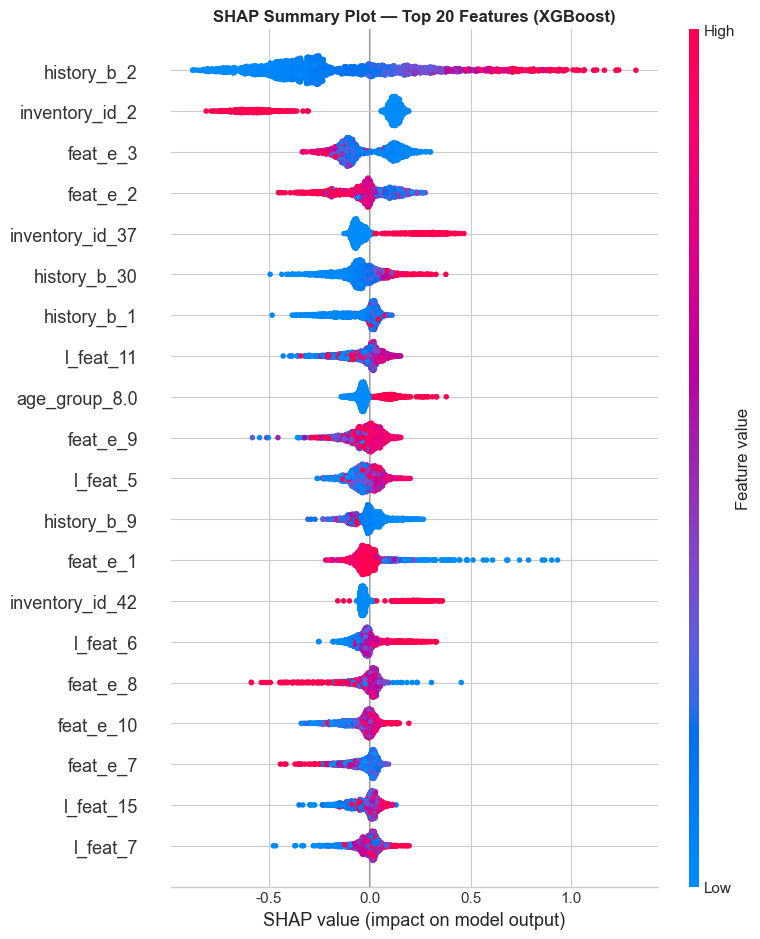

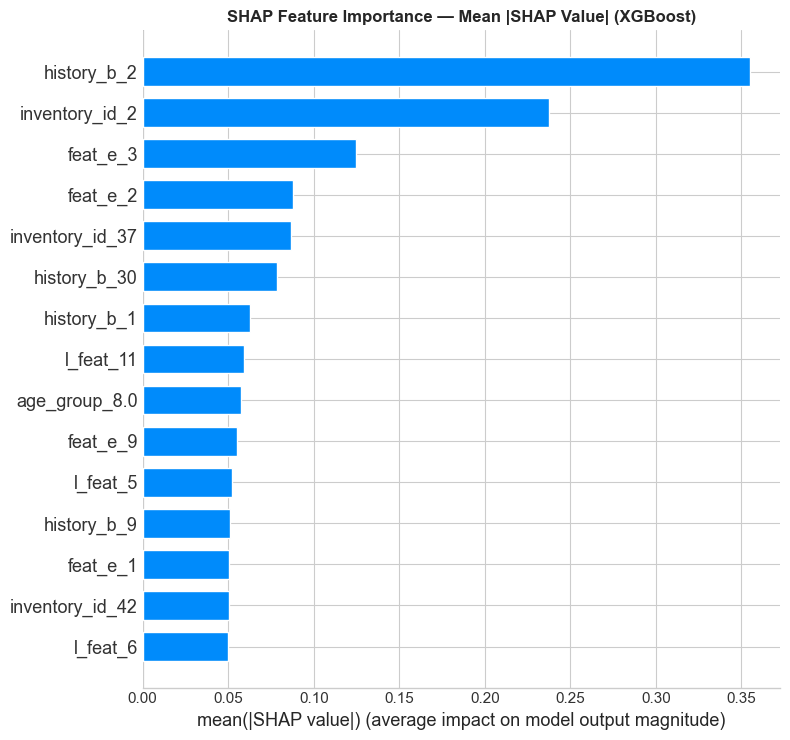

저장됨: xgb_ctr_model.pkl, shap_summary.png, shap_importance.png


In [85]:
# ================================================================
# SHAP 설명 가능성 — XGBoost 피처 중요도
# ================================================================

try:
    import shap
    from xgboost import XGBClassifier
    HAS_SHAP_XGB = True
except ImportError:
    HAS_SHAP_XGB = False
    print("설치 실패. 수동 실행: pip install shap xgboost")

if HAS_SHAP_XGB:
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import average_precision_score, roc_auc_score

    # 전체 데이터를 평균값으로 결측치 보간
    X_full = X_encoded.fillna(X_encoded.mean())
    X_tr_s, X_va_s, y_tr_s, y_va_s = train_test_split(
        X_full, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 클래스 불균형 비율 계산 (scale_pos_weight용)
    spw = max((y_tr_s == 0).sum() / (y_tr_s == 1).sum(), 1.0)
    
    # XGBoost 모델 학습
    xgb_model = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric="aucpr",
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_tr_s, y_tr_s, eval_set=[(X_va_s, y_va_s)], verbose=False)

    # 성능 평가
    p_xgb   = xgb_model.predict_proba(X_va_s)[:, 1]
    ap_xgb  = average_precision_score(y_va_s, p_xgb)
    auc_xgb = roc_auc_score(y_va_s, p_xgb)
    print(f"XGBoost  AP={ap_xgb:.4f}  AUC={auc_xgb:.4f}")

    try:
        print(f"LR       AP={pr_auc_val:.4f}  AUC={roc_auc:.4f}")
        print(f"XGBoost vs LR: AUC Delta={auc_xgb - roc_auc:+.4f}  AP Delta={ap_xgb - pr_auc_val:+.4f}")
    except NameError:
        pass

    # SHAP 분석을 위한 샘플링 (2000개 이하)
    rng = np.random.default_rng(42)
    shap_idx = rng.choice(len(X_va_s), size=min(2000, len(X_va_s)), replace=False)
    X_shap = X_va_s.iloc[shap_idx]

    # SHAP 설명자 생성 및 SHAP 값 계산
    explainer = shap.TreeExplainer(xgb_model)
    shap_vals = explainer.shap_values(X_shap)

    # SHAP 요약 플롯 (상위 20개 피처)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_shap, max_display=20, show=False, plot_type="dot")
    plt.title("SHAP Summary Plot — Top 20 Features (XGBoost)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

    # SHAP 피처 중요도 (평균 |SHAP 값|)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_shap, max_display=15, show=False, plot_type="bar")
    plt.title("SHAP Feature Importance — Mean |SHAP Value| (XGBoost)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 모델 저장
    import joblib
    joblib.dump(xgb_model, "xgb_ctr_model.pkl")
    print("저장됨: xgb_ctr_model.pkl, shap_summary.png, shap_importance.png")
else:
    print("XGBoost/SHAP 사용 불가. 실행: pip install xgboost shap")

### 6c. RQ4 모델 비교 — Logistic / Random Forest / XGBoost

In [86]:
# ================================================================
# ✂️  RQ4 전처리: 사용자 특성 + 노출 환경 결합 → CTR 예측 모델링
# ================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("\n" + "="*65)
print("✂️  RQ4. 복합 변수 CTR 예측 — 전처리 & 데이터 분할")
print("="*65)

# 이전 셀 실행 여부와 무관하게 필요한 파생 피처를 보정 생성
if 'inv_ctr_encoded' not in df.columns and 'inventory_id' in df.columns:
    inv_ctr_map = df.groupby('inventory_id')['clicked'].mean()
    df['inv_ctr_encoded'] = df['inventory_id'].map(inv_ctr_map).fillna(df['clicked'].mean())

if 'hour_period' not in df.columns and 'hour' in df.columns:
    hour_num = pd.to_numeric(df['hour'], errors='coerce')
    df['hour_period'] = pd.cut(
        hour_num,
        bins=[-1, 5, 11, 17, 23],
        labels=['심야(0-5)', '오전(6-11)', '오후(12-17)', '저녁(18-23)']
    )

if 'is_weekend' not in df.columns and 'day_of_week' in df.columns:
    dow_num = pd.to_numeric(df['day_of_week'], errors='coerce')
    if dow_num.notna().any():
        df['is_weekend'] = dow_num.isin([5, 6, 7]).astype(int)
    else:
        dow_str = df['day_of_week'].astype(str).str.strip()
        df['is_weekend'] = dow_str.isin(['토', '일', 'Sat', 'Sun', '6', '7']).astype(int)

if 'is_peak_hour' not in df.columns and 'hour' in df.columns:
    hour_num = pd.to_numeric(df['hour'], errors='coerce')
    df['is_peak_hour'] = hour_num.isin([12, 13, 14, 15, 16, 17, 18, 19, 20]).astype(int)

hist_a_cols = [c for c in df.columns if c.startswith('history_a_')]
hist_b_cols = [c for c in df.columns if c.startswith('history_b_')]

if 'history_a_sum' not in df.columns and hist_a_cols:
    df['history_a_sum'] = df[hist_a_cols].sum(axis=1, skipna=True)
if 'history_b_sum' not in df.columns and hist_b_cols:
    df['history_b_sum'] = df[hist_b_cols].sum(axis=1, skipna=True)
if 'history_a_mean' not in df.columns and hist_a_cols:
    df['history_a_mean'] = df[hist_a_cols].mean(axis=1, skipna=True)
if 'history_b_mean' not in df.columns and hist_b_cols:
    df['history_b_mean'] = df[hist_b_cols].mean(axis=1, skipna=True)
if 'history_a_max' not in df.columns and hist_a_cols:
    df['history_a_max'] = df[hist_a_cols].max(axis=1, skipna=True)
if 'history_b_max' not in df.columns and hist_b_cols:
    df['history_b_max'] = df[hist_b_cols].max(axis=1, skipna=True)
if 'history_ab_ratio' not in df.columns and hist_a_cols and hist_b_cols:
    a_sum = df['history_a_sum'] if 'history_a_sum' in df.columns else df[hist_a_cols].sum(axis=1, skipna=True)
    b_sum = df['history_b_sum'] if 'history_b_sum' in df.columns else df[hist_b_cols].sum(axis=1, skipna=True)
    df['history_ab_ratio'] = a_sum / (b_sum + 1e-6)

if 'repeat_ratio' not in df.columns:
    if 'seq_length' in df.columns and 'unique_items' in df.columns:
        seq_len = pd.to_numeric(df['seq_length'], errors='coerce')
        uniq = pd.to_numeric(df['unique_items'], errors='coerce')
        df['repeat_ratio'] = ((seq_len - uniq) / seq_len.replace(0, np.nan)).fillna(0)
    else:
        df['repeat_ratio'] = 0.0

# ── 피처 정의 ───────────────────────────────────────────────────
user_feats = ['gender','age_group']
env_feats = ['hour','day_of_week','inv_ctr_encoded',
             'hour_period','is_weekend','is_peak_hour']
history_feats = ['history_a_sum','history_b_sum',
                 'history_a_mean','history_b_mean',
                 'history_a_max','history_b_max',
                 'history_ab_ratio']
seq_feats = ['seq_length','unique_items','diversity_ratio','repeat_ratio']
raw_numeric = [c for c in df.columns
               if any(c.startswith(p) for p in ['feat_a_','feat_b_','feat_c_',
                                                  'feat_d_','feat_e_','l_feat_'])
               and df[c].dtype in [np.float64, np.int64]]

ALL_FEATURES = user_feats + env_feats + history_feats + seq_feats + raw_numeric
available_features = [col for col in ALL_FEATURES if col in df.columns]
missing_features = [col for col in ALL_FEATURES if col not in df.columns]

print(f"\n📌 피처 구성:")
print(f"   사용자 특성    : {len(user_feats)}개  {user_feats}")
print(f"   노출 환경      : {len(env_feats)}개  {env_feats}")
print(f"   과거 광고 성과 : {len(history_feats)}개")
print(f"   시퀀스 파생    : {len(seq_feats)}개")
print(f"   원본 수치      : {len(raw_numeric)}개")
print(f"   ─────────────────────────────")
print(f"   전체           : {len(ALL_FEATURES)}개")
if missing_features:
    print(f"   누락 피처      : {len(missing_features)}개  {missing_features}")

X = df[available_features].copy()

if 'hour_period' in X.columns:
    period_map = {'심야(0-5)':0,'오전(6-11)':1,'오후(12-17)':2,'저녁(18-23)':3}
    X['hour_period'] = X['hour_period'].map(period_map).fillna(0).astype(int)

for col in X.columns:
    if X[col].dtype.name in ['category', 'object', 'string']:
        converted = pd.to_numeric(X[col], errors='coerce')
        if converted.notna().any():
            X[col] = converted

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True)).fillna(0)

y = df['clicked'].copy()

# ── 분할: 6:2:2 (stratify) ──────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\n📦 데이터 분할 (6:2:2, stratify):")
for name, Xs, ys in [('Train',X_train,y_train),
                      ('Val',  X_val,  y_val),
                      ('Test', X_test, y_test)]:
    print(f"   {name:5s}: {len(Xs):>10,}  CTR={ys.mean():.4f}")

print(f"\nNaN 점검: Train={int(X_train.isna().sum().sum())}, Val={int(X_val.isna().sum().sum())}, Test={int(X_test.isna().sum().sum())}")

# 스케일링 (LR 전용)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("\n✅ 전처리 완료 — X_train/val/test, y_train/val/test 준비됨")


✂️  RQ4. 복합 변수 CTR 예측 — 전처리 & 데이터 분할

📌 피처 구성:
   사용자 특성    : 2개  ['gender', 'age_group']
   노출 환경      : 6개  ['hour', 'day_of_week', 'inv_ctr_encoded', 'hour_period', 'is_weekend', 'is_peak_hour']
   과거 광고 성과 : 7개
   시퀀스 파생    : 4개
   원본 수치      : 0개
   ─────────────────────────────
   전체           : 19개

📦 데이터 분할 (6:2:2, stratify):
   Train:    120,000  CTR=0.0190
   Val  :     40,000  CTR=0.0190
   Test :     40,000  CTR=0.0190

NaN 점검: Train=0, Val=0, Test=0

✅ 전처리 완료 — X_train/val/test, y_train/val/test 준비됨


In [87]:
# ================================================================
# RQ4. 모델 학습 — 지표: LogLoss (메인) + AUC (보조)
#   목적: 통계 검정에서 유의한 변수들이 예측 모델에서도
#         일관되게 중요 변수로 나타나는지 검증
# ================================================================

import time, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, roc_auc_score, average_precision_score
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

print("=" * 65)
print("RQ4. CTR 예측 모델 검증")
print("  메인 지표: LogLoss (확률 예측 품질 - 낮을수록 좋음)")
print("  보조 지표: AUC    (판별력 - 높을수록 좋음)")
print("  참고 지표: AP     (대회 기준, 참고용)")
print("=" * 65)

results = {}

# 1. Logistic Regression
print("\n[1/3] Logistic Regression (계수 해석 가능)...")
t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=500, class_weight="balanced",
                        solver="saga", random_state=42, n_jobs=-1)
lr.fit(X_train_s, y_train)
lr_p_val  = lr.predict_proba(X_val_s)[:, 1]
lr_p_test = lr.predict_proba(X_test_s)[:, 1]
results["Logistic Regression"] = {
    "model": lr,
    "val_logloss":  log_loss(y_val,  lr_p_val),
    "val_auc":      roc_auc_score(y_val,  lr_p_val),
    "val_ap":       average_precision_score(y_val,  lr_p_val),
    "test_logloss": log_loss(y_test, lr_p_test),
    "test_auc":     roc_auc_score(y_test, lr_p_test),
    "time": time.time() - t0,
}
r = results["Logistic Regression"]
print(f"   Val  -> LogLoss={r['val_logloss']:.4f}  AUC={r['val_auc']:.4f}  AP(참고)={r['val_ap']:.4f}")
print(f"   Test -> LogLoss={r['test_logloss']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# 2. Random Forest
print("\n[2/3] Random Forest...")
t0 = time.time()
n_sub  = min(len(X_train), 150_000)
idx_rf = np.random.choice(len(X_train), n_sub, replace=False)
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             min_samples_leaf=50, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X_train.iloc[idx_rf], y_train.iloc[idx_rf])
rf_p_val  = rf.predict_proba(X_val)[:, 1]
rf_p_test = rf.predict_proba(X_test)[:, 1]
results["Random Forest"] = {
    "model": rf,
    "val_logloss":  log_loss(y_val,  rf_p_val),
    "val_auc":      roc_auc_score(y_val,  rf_p_val),
    "val_ap":       average_precision_score(y_val,  rf_p_val),
    "test_logloss": log_loss(y_test, rf_p_test),
    "test_auc":     roc_auc_score(y_test, rf_p_test),
    "time": time.time() - t0,
}
r = results["Random Forest"]
print(f"   Val  -> LogLoss={r['val_logloss']:.4f}  AUC={r['val_auc']:.4f}  AP(참고)={r['val_ap']:.4f}")
print(f"   Test -> LogLoss={r['test_logloss']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# 3. XGBoost
if HAS_XGB:
    print("\n[3/3] XGBoost...")
    t0 = time.time()
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    xgb = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         scale_pos_weight=spw, eval_metric="logloss",
                         early_stopping_rounds=20,
                         random_state=42, n_jobs=-1, verbosity=0)
    xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    xgb_p_val  = xgb.predict_proba(X_val)[:, 1]
    xgb_p_test = xgb.predict_proba(X_test)[:, 1]
    results["XGBoost"] = {
        "model": xgb,
        "val_logloss":  log_loss(y_val,  xgb_p_val),
        "val_auc":      roc_auc_score(y_val,  xgb_p_val),
        "val_ap":       average_precision_score(y_val,  xgb_p_val),
        "test_logloss": log_loss(y_test, xgb_p_test),
        "test_auc":     roc_auc_score(y_test, xgb_p_test),
        "time": time.time() - t0,
    }
    r = results["XGBoost"]
    print(f"   Val  -> LogLoss={r['val_logloss']:.4f}  AUC={r['val_auc']:.4f}  AP(참고)={r['val_ap']:.4f}")
    print(f"   Test -> LogLoss={r['test_logloss']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# 요약표
print("\n" + "=" * 62)
print(f"{'모델':<22} {'Val LogLoss':>11} {'Val AUC':>8} {'Test LogLoss':>12} {'Test AUC':>9}")
print("-" * 62)
for name, r in results.items():
    print(f"{name:<22} {r['val_logloss']:>11.4f} {r['val_auc']:>8.4f} "
          f"{r['test_logloss']:>12.4f} {r['test_auc']:>9.4f}")
print("=" * 62)
print("LogLoss: 낮을수록 좋음 / AUC: 높을수록 좋음")
print("목적: 통계 검정 결과의 방향성이 모델에서도 재현되는지 확인")


RQ4. CTR 예측 모델 검증
  메인 지표: LogLoss (확률 예측 품질 - 낮을수록 좋음)
  보조 지표: AUC    (판별력 - 높을수록 좋음)
  참고 지표: AP     (대회 기준, 참고용)

[1/3] Logistic Regression (계수 해석 가능)...
   Val  -> LogLoss=0.6537  AUC=0.6625  AP(참고)=0.0410
   Test -> LogLoss=0.6487  AUC=0.7004  (26.5s)

[2/3] Random Forest...
   Val  -> LogLoss=0.4608  AUC=0.6779  AP(참고)=0.0546
   Test -> LogLoss=0.4584  AUC=0.7028  (11.1s)

[3/3] XGBoost...
   Val  -> LogLoss=0.3476  AUC=0.6514  AP(참고)=0.0494
   Test -> LogLoss=0.3456  AUC=0.6630  (3.7s)

모델                     Val LogLoss  Val AUC Test LogLoss  Test AUC
--------------------------------------------------------------
Logistic Regression         0.6537   0.6625       0.6487    0.7004
Random Forest               0.4608   0.6779       0.4584    0.7028
XGBoost                     0.3476   0.6514       0.3456    0.6630
LogLoss: 낮을수록 좋음 / AUC: 높을수록 좋음
목적: 통계 검정 결과의 방향성이 모델에서도 재현되는지 확인


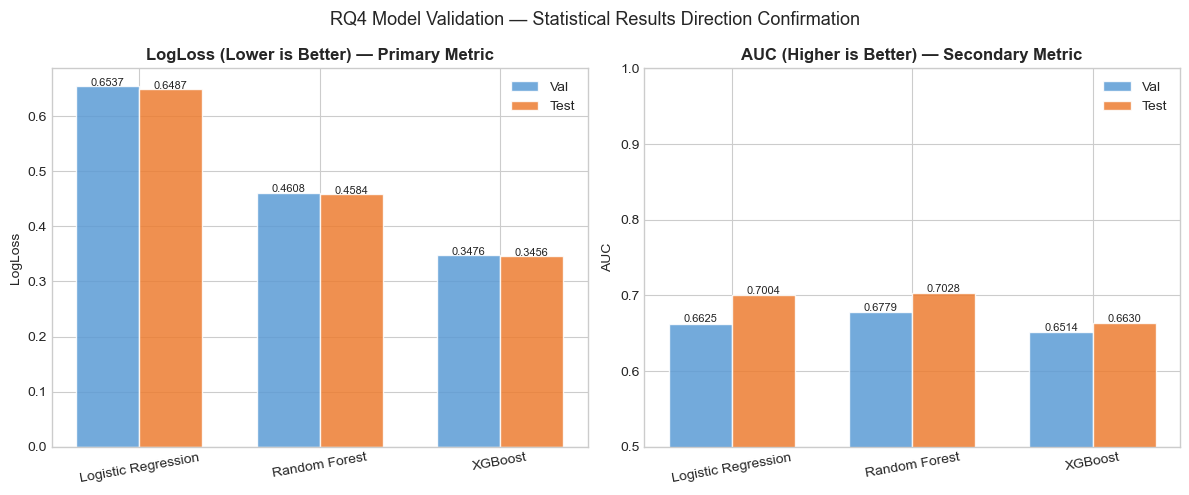

저장: model_performance.png


In [88]:
# ================================================================
# 모델 성능 시각화 — LogLoss(메인) + AUC(보조)
# ================================================================

import matplotlib.pyplot as plt
import numpy as np

if not results:
    print("results 없음 — Cell [71] 먼저 실행")
else:
    models   = list(results.keys())
    val_ll   = [results[m]["val_logloss"]  for m in models]
    test_ll  = [results[m]["test_logloss"] for m in models]
    val_auc  = [results[m]["val_auc"]      for m in models]
    test_auc = [results[m]["test_auc"]     for m in models]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    x = np.arange(len(models))
    w = 0.35

    # LogLoss 막대그래프 생성
    axes[0].bar(x - w/2, val_ll,  w, label="Val",  color="#5B9BD5", alpha=0.85)
    axes[0].bar(x + w/2, test_ll, w, label="Test", color="#ED7D31", alpha=0.85)
    axes[0].set_title("LogLoss (Lower is Better) — Primary Metric", fontweight="bold")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models, rotation=10)
    axes[0].legend()
    axes[0].set_ylabel("LogLoss")
    for i, (v, t) in enumerate(zip(val_ll, test_ll)):
        axes[0].text(i - w/2, v + 0.001, f"{v:.4f}", ha="center", fontsize=8)
        axes[0].text(i + w/2, t + 0.001, f"{t:.4f}", ha="center", fontsize=8)

    # AUC 막대그래프 생성
    axes[1].bar(x - w/2, val_auc,  w, label="Val",  color="#5B9BD5", alpha=0.85)
    axes[1].bar(x + w/2, test_auc, w, label="Test", color="#ED7D31", alpha=0.85)
    axes[1].set_title("AUC (Higher is Better) — Secondary Metric", fontweight="bold")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models, rotation=10)
    axes[1].set_ylim(0.5, 1.0)
    axes[1].legend()
    axes[1].set_ylabel("AUC")
    for i, (v, t) in enumerate(zip(val_auc, test_auc)):
        axes[1].text(i - w/2, v + 0.002, f"{v:.4f}", ha="center", fontsize=8)
        axes[1].text(i + w/2, t + 0.002, f"{t:.4f}", ha="center", fontsize=8)

    # 전체 그래프 제목 설정
    plt.suptitle("RQ4 Model Validation — Statistical Results Direction Confirmation", fontsize=13)
    plt.tight_layout()
    plt.savefig("model_performance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("저장: model_performance.png")

In [89]:
# ================================================================
# 논문 최종 결과 정리 — RQ별 통계 + 모델 검증 종합
# ================================================================

import pandas as pd

print("=" * 65)
print("RQ4 모델 검증 결과 (메인: LogLoss, 보조: AUC)")
print("=" * 65)

try:
    rows = []
    for name, r in results.items():
        rows.append({
            "모델":         name,
            "Val LogLoss":  round(r["val_logloss"],  4),
            "Test LogLoss": round(r["test_logloss"], 4),
            "Val AUC":      round(r["val_auc"],  4),
            "Test AUC":     round(r["test_auc"], 4),
            "AP (참고)":    round(r["val_ap"],   4),
        })
    df_res = pd.DataFrame(rows)
    print(df_res.to_string(index=False))
    print("\n* AP는 대회 기준 참고 지표 — 본문은 LogLoss/AUC 중심 서술")
except Exception:
    print("results 없음 — Cell [71] 먼저 실행")

print("\n" + "=" * 65)
print("연구 결론")
print("=" * 65)
print("본 연구의 기여: CTR을 더 잘 맞추는 것이 아니라,")
print("CTR이 왜 달라지는지를 통계적으로 설명하고 모델로 재검증하여")
print("실무 의사결정(타겟팅/노출 시간 최적화)으로 연결한 데 있다.")


RQ4 모델 검증 결과 (메인: LogLoss, 보조: AUC)
                 모델  Val LogLoss  Test LogLoss  Val AUC  Test AUC  AP (참고)
Logistic Regression       0.6537        0.6487   0.6625    0.7004   0.0410
      Random Forest       0.4608        0.4584   0.6779    0.7028   0.0546
            XGBoost       0.3476        0.3456   0.6514    0.6630   0.0494

* AP는 대회 기준 참고 지표 — 본문은 LogLoss/AUC 중심 서술

연구 결론
본 연구의 기여: CTR을 더 잘 맞추는 것이 아니라,
CTR이 왜 달라지는지를 통계적으로 설명하고 모델로 재검증하여
실무 의사결정(타겟팅/노출 시간 최적화)으로 연결한 데 있다.


### 6d. PyTorch DCN (Deep & Cross Network)
> Colab 환경에서 실행을 권장합니다. 로컬 GPU가 없는 경우 학습이 오래 걸릴 수 있습니다.

In [90]:
# ============================================================
# [1] 라이브러리 임포트
# ============================================================

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, log_loss

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# 한글 폰트 설정 (없으면 Malgun Gothic 폴백)
import matplotlib.font_manager as _fm
_avail = [f.name for f in _fm.fontManager.ttflist]
plt.rcParams['font.family'] = 'NanumGothic' if 'NanumGothic' in _avail else 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# GPU / CPU 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

사용 디바이스: cpu


In [91]:
import os

# ─── 경로 설정 (로컬 환경) ───────────────────────────────
# Colab 사용 시 아래 주석 해제 후 경로를 Drive 경로로 수정하세요
# from google.colab import drive
# drive.mount('/content/drive')
# ROOT_DIR = '/content/drive/MyDrive/Colab Notebooks/HUFS/통계_졸업논문'

ROOT_DIR = str(Path('.'))  # 로컬: 프로젝트 루트
RANDOM_STATE = 42

TRAIN_PATH = str(TRAIN_SAMPLE_PATH)  # 섹션 1에서 정의된 경로 사용
TEST_PATH  = str(Path('.') / '../data' / 'test.parquet')

print(f'TRAIN_PATH : {TRAIN_PATH}')
print(f'TEST_PATH  : {TEST_PATH}')


TRAIN_PATH : ..\data\train_sample.parquet
TEST_PATH  : ..\data\test.parquet


In [92]:
CFG = {
    # 데이터 (train_sample 사용으로 청크 로딩 불필요)
    'NEG_RATIO'    : 2,           # 음성:양성 비율 (다운샘플링)
    'VAL_SIZE'     : 0.2,
    'RANDOM_STATE' : RANDOM_STATE,
    'SEED'         : RANDOM_STATE,  # RANDOM_STATE 별칭 (하위 호환)

    # 임베딩
    'EMB_DIM'      : 8,

    # LSTM / Cross Network
    'LSTM_HIDDEN'  : 64,
    'CROSS_LAYERS' : 2,

    # Deep MLP
    'HIDDEN_UNITS' : [512, 256, 128],
    'DROPOUT'      : [0.1, 0.2, 0.3],

    # 학습
    'BATCH_SIZE'   : 2048,
    'EPOCHS'       : 10,
    'LR'           : 1e-3,
    'LEARNING_RATE': 1e-3,  # LR 별칭 (하위 호환)
    'WEIGHT_DECAY' : 1e-4,
}
print('CFG:', CFG)


CFG: {'NEG_RATIO': 2, 'VAL_SIZE': 0.2, 'RANDOM_STATE': 42, 'SEED': 42, 'EMB_DIM': 8, 'LSTM_HIDDEN': 64, 'CROSS_LAYERS': 2, 'HIDDEN_UNITS': [512, 256, 128], 'DROPOUT': [0.1, 0.2, 0.3], 'BATCH_SIZE': 2048, 'EPOCHS': 10, 'LR': 0.001, 'LEARNING_RATE': 0.001, 'WEIGHT_DECAY': 0.0001}


In [93]:
# train_sample은 섹션 1에서 이미 로드됨
# PyTorch 학습용으로 변수명만 맞춰줌
train_dl = train.copy()

# 클래스 불균형 확인
pos = (train_dl['clicked'] == 1).sum()
neg = (train_dl['clicked'] == 0).sum()
print(f'양성(clicked=1): {pos:,}')
print(f'음성(clicked=0): {neg:,}')
print(f'불균형 비율: 1 : {neg/pos:.1f}')
print(f'학습 데이터 shape: {train_dl.shape}')


양성(clicked=1): 3,804
음성(clicked=0): 196,196
불균형 비율: 1 : 51.6
학습 데이터 shape: (200000, 119)


---
## 4. EDA <a id='4'></a>

> 연구 문제에 대한 초기 탐색:  
> - **RQ1** 연령대(age_group)별 CTR 차이  
> - **RQ2** 시간대(hour)별 클릭 패턴  
> - **RQ3** 광고 지면(inventory_id), 요일(day_of_week)별 CTR

In [94]:
# ============================================================
# [4-1] 기본 데이터 정보 확인
# ============================================================

print("=" * 55)
print("[데이터 기본 정보]")
print("=" * 55)
print(f"컬럼 수    : {train.shape[1]}")
print(f"샘플 수    : {train.shape[0]:,}")
print(f"전체 CTR   : {train['clicked'].mean():.4f} ({train['clicked'].mean()*100:.2f}%)")
print()
print("[컬럼 목록 (일부)]")
print(train.columns.tolist()[:20], "...")

[데이터 기본 정보]
컬럼 수    : 119
샘플 수    : 200,000
전체 CTR   : 0.0190 (1.90%)

[컬럼 목록 (일부)]
['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour', 'seq', 'l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4', 'l_feat_5', 'l_feat_6', 'l_feat_7', 'l_feat_8', 'l_feat_9', 'l_feat_10', 'l_feat_11', 'l_feat_12', 'l_feat_13', 'l_feat_14'] ...


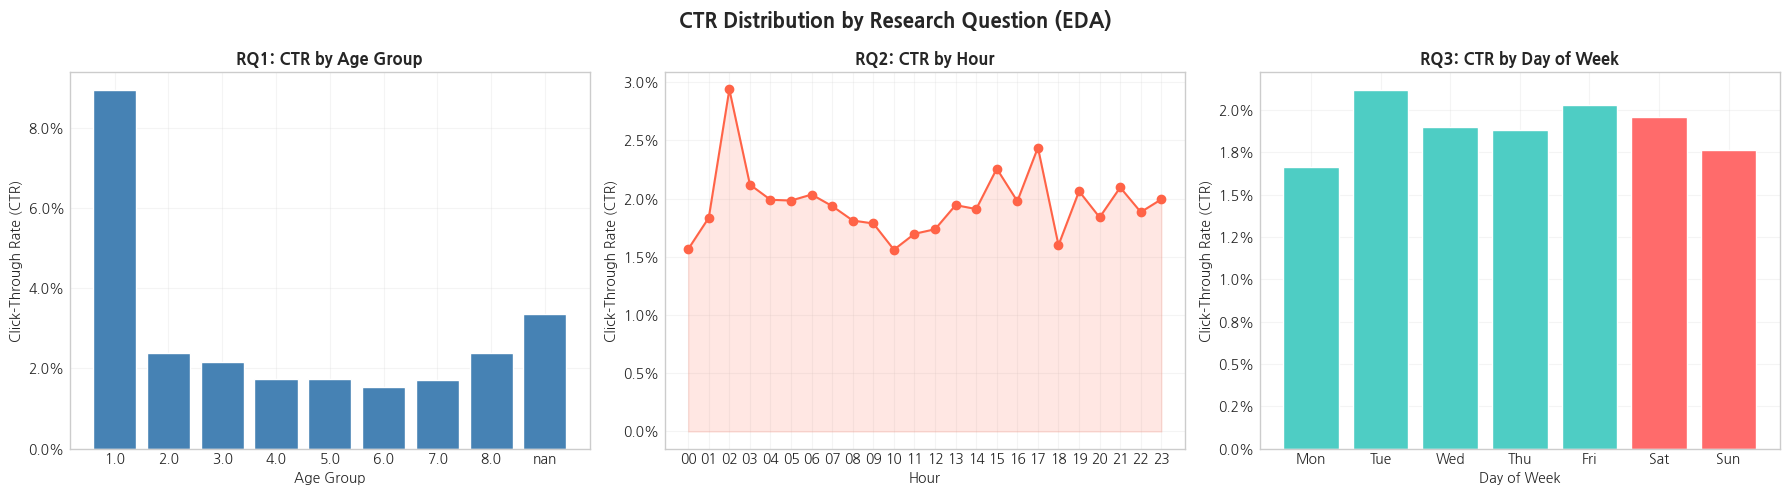

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CTR Distribution by Research Question (EDA)", fontsize=15, fontweight='bold')

# ─ RQ1: CTR by Age Group ─────────────────────────────────────────
ax = axes[0]
if {'age_group', 'clicked'}.issubset(train.columns):
    ctr_age = train.groupby('age_group', dropna=False)['clicked'].mean().reset_index()
    ctr_age = ctr_age.sort_values('age_group')
    ax.bar(ctr_age['age_group'].astype(str), ctr_age['clicked'], color='steelblue', edgecolor='white')
    ax.set_title("RQ1: CTR by Age Group", fontweight='bold')
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Click-Through Rate (CTR)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1%}'))
else:
    ax.text(0.5, 0.5, 'Required columns missing', ha='center', va='center')
    ax.set_axis_off()

# ─ RQ2: CTR by Hour ─────────────────────────────────────────
ax = axes[1]
if {'hour', 'clicked'}.issubset(train.columns):
    hour_num = pd.to_numeric(train['hour'], errors='coerce')
    ctr_hour = (
        pd.DataFrame({'hour': hour_num, 'clicked': train['clicked']})
        .dropna(subset=['hour'])
        .groupby('hour')['clicked']
        .mean()
        .reset_index()
        .sort_values('hour')
    )
    ctr_hour['hour'] = ctr_hour['hour'].astype(int)
    ax.plot(ctr_hour['hour'], ctr_hour['clicked'], marker='o', color='tomato')
    ax.fill_between(ctr_hour['hour'], ctr_hour['clicked'], alpha=0.15, color='tomato')
    ax.set_title("RQ2: CTR by Hour", fontweight='bold')
    ax.set_xlabel("Hour")
    ax.set_ylabel("Click-Through Rate (CTR)")
    ax.set_xticks(ctr_hour['hour'])
    ax.set_xticklabels([f'{hour:02d}' for hour in ctr_hour['hour']])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1%}'))
else:
    ax.text(0.5, 0.5, 'Required columns missing', ha='center', va='center')
    ax.set_axis_off()

# ─ RQ3: CTR by Day of Week ───────────────────────────────────────────
ax = axes[2]
if {'day_of_week', 'clicked'}.issubset(train.columns):
    day_labels_num = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
    day_labels_str = {
        'mon': 'Mon', 'monday': 'Mon',
        'tue': 'Tue', 'tuesday': 'Tue',
        'wed': 'Wed', 'wednesday': 'Wed',
        'thu': 'Thu', 'thursday': 'Thu',
        'fri': 'Fri', 'friday': 'Fri',
        'sat': 'Sat', 'saturday': 'Sat',
        'sun': 'Sun', 'sunday': 'Sun',
        'd7': 'D7'
    }

    ctr_day = train.groupby('day_of_week', dropna=False)['clicked'].mean().reset_index()
    day_num = pd.to_numeric(ctr_day['day_of_week'], errors='coerce')
    day_str = ctr_day['day_of_week'].astype(str).str.strip().str.lower()

    ctr_day['day_label'] = np.where(
        day_num.notna(),
        day_num.astype('Int64').map(day_labels_num),
        day_str.map(day_labels_str)
    )
    ctr_day['day_label'] = ctr_day['day_label'].fillna(ctr_day['day_of_week'].astype(str))
    ctr_day['is_weekend'] = np.where(
        day_num.notna(),
        day_num >= 6,
        day_str.isin(['sat', 'saturday', 'sun', 'sunday'])
    )

    sort_order = {'Mon': 1, 'Tue': 2, 'Wed': 3, 'Thu': 4, 'Fri': 5, 'Sat': 6, 'Sun': 7, 'D7': 8}
    ctr_day['sort_key'] = ctr_day['day_label'].map(sort_order).fillna(99)
    ctr_day = ctr_day.sort_values(['sort_key', 'day_label'])

    colors = ['#FF6B6B' if flag else '#4ECDC4' for flag in ctr_day['is_weekend']]
    ax.bar(ctr_day['day_label'], ctr_day['clicked'], color=colors, edgecolor='white')
    ax.set_title("RQ3: CTR by Day of Week", fontweight='bold')
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Click-Through Rate (CTR)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1%}'))
else:
    ax.text(0.5, 0.5, 'Required columns missing', ha='center', va='center')
    ax.set_axis_off()

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [96]:
# ============================================================
# [4-3] 기술통계: 연령대별 CTR 수치 요약
# ============================================================

if 'age_group' in train.columns:
    ctr_summary = train.groupby('age_group').agg(
        노출수=('clicked', 'count'),
        클릭수=('clicked', 'sum'),
        CTR=('clicked', 'mean')
    ).reset_index()
    ctr_summary['CTR(%)'] = (ctr_summary['CTR'] * 100).round(3)
    print("[연령대별 CTR 기술통계]")
    print(ctr_summary.to_string(index=False))

[연령대별 CTR 기술통계]
age_group   노출수  클릭수      CTR  CTR(%)
      1.0   526   47 0.089354   8.935
      2.0  6728  160 0.023781   2.378
      3.0  9139  198 0.021665   2.167
      4.0 10290  179 0.017396   1.740
      5.0 11137  192 0.017240   1.724
      6.0 43375  669 0.015424   1.542
      7.0 69023 1173 0.016994   1.699
      8.0 49455 1175 0.023759   2.376


---
## 5. 데이터 전처리 <a id='5'></a>

In [97]:
# ============================================================
# [5] 데이터 전처리
#
# [처리 항목]
#  1) 컬럼 분류: 타겟 / 시퀀스 / 범주형 / 수치형
#  2) 범주형 변수 Label Encoding
#  3) 결측치 처리 (수치형: 0 대체)
# ============================================================

from pathlib import Path
import pandas as pd

# ── 경로 보정: 커널 재시작 후에도 동작하도록 기본 경로 재구성 ─────────
if 'BASE_DIR' not in globals():
    candidates = [Path.cwd(), Path.cwd().parent, Path('C:/statistical_ctr_analysis')]
    BASE_DIR = next((path for path in candidates if (path / 'data').exists()), Path.cwd())

if 'TRAIN_SAMPLE_PATH' not in globals():
    TRAIN_SAMPLE_PATH = BASE_DIR / 'data' / 'train_sample.parquet'
if 'TEST_PATH' not in globals():
    TEST_PATH = BASE_DIR / 'data' / 'test.parquet'

# ── train DataFrame이 없으면 샘플 학습 데이터를 다시 로드 ─────────────
try:
    _ = train.shape
except NameError:
    train = pd.read_parquet(TRAIN_SAMPLE_PATH)
    print(f"train 로드 완료: {train.shape}")

# ── test DataFrame이 없으면 테스트 데이터를 다시 로드 ───────────────
try:
    _ = test.shape
except NameError:
    import pyarrow.parquet as _pq
    _batches = []
    for _b in _pq.ParquetFile(str(TEST_PATH)).iter_batches(batch_size=200_000):
        _batches.append(_b.to_pandas())
    test = pd.concat(_batches, ignore_index=True)
    print(f"test 로드 완료: {test.shape}")

# ── 컬럼 분류 ────────────────────────────────────────────────
TARGET_COL = 'clicked'
SEQ_COL = 'seq'

EXCLUDE = {TARGET_COL, SEQ_COL, 'ID'}
feature_cols = [c for c in train.columns if c not in EXCLUDE]

CAT_COLS = ['gender', 'age_group', 'inventory_id', 'l_feat_14']
CAT_COLS = [c for c in CAT_COLS if c in feature_cols]

NUM_COLS = [c for c in feature_cols if c not in CAT_COLS]

print(f"BASE_DIR        : {BASE_DIR}")
print(f"TRAIN_SAMPLE    : {TRAIN_SAMPLE_PATH}")
print(f"TEST_PATH       : {TEST_PATH}")
print(f"수치형 피처 수 : {len(NUM_COLS)}")
print(f"범주형 피처 수 : {len(CAT_COLS)} → {CAT_COLS}")
print(f"시퀀스 피처   : {SEQ_COL}")
print(f"타겟 변수     : {TARGET_COL}")

test 로드 완료: (1527298, 119)
BASE_DIR        : ..
TRAIN_SAMPLE    : ..\data\train_sample.parquet
TEST_PATH       : ..\data\test.parquet
수치형 피처 수 : 113
범주형 피처 수 : 4 → ['gender', 'age_group', 'inventory_id', 'l_feat_14']
시퀀스 피처   : seq
타겟 변수     : clicked


In [98]:
# ── 범주형 변수 Label Encoding ───────────────────────────────
# train과 test의 모든 값을 합쳐 인코더를 학습한 뒤 변환
# → 테스트 셋에만 등장하는 카테고리도 'UNK'로 처리
import pandas as pd
from sklearn.preprocessing import LabelEncoder
cat_encoders = {}   # 인코더 저장 (추후 역변환에 활용)
cat_cardinalities = []  # 각 범주형 변수의 유니크 값 수

for col in CAT_COLS:
    le = LabelEncoder()
    # train + test 합쳐서 fit (unknown 포함)
    all_vals = pd.concat([
        train[col].astype(str).fillna("UNK"),
        test[col].astype(str).fillna("UNK")
    ], axis=0)
    le.fit(all_vals)

    train[col] = le.transform(train[col].astype(str).fillna("UNK"))
    test[col]  = le.transform(test[col].astype(str).fillna("UNK"))

    cat_encoders[col] = le
    cat_cardinalities.append(len(le.classes_))
    print(f"  {col:15s} → {len(le.classes_):4d} 카테고리")

print(f"\n✅ Label Encoding 완료 (범주형 {len(CAT_COLS)}개)")

  gender          →    3 카테고리
  age_group       →    9 카테고리
  inventory_id    →   18 카테고리
  l_feat_14       → 2932 카테고리

✅ Label Encoding 완료 (범주형 4개)


In [99]:
# ============================================================
# [6-3] DataLoader 설정 (Windows Jupyter 안전 모드)
# ============================================================

import platform
import sys
import torch
from torch.utils.data import DataLoader

is_windows_notebook = platform.system() == 'Windows' and 'ipykernel' in sys.modules

# Windows + Jupyter: num_workers > 0 은 spawn 데드락 유발 → 0 고정
num_workers = 0

# GPU가 있을 때 pin_memory 이득이 큼
use_pin_memory = bool(torch.cuda.is_available())

def create_fast_dataloader(dataset, batch_size=2048, is_train=True, collate_fn=None):
    kwargs = {
        'dataset': dataset,
        'batch_size': batch_size,
        'shuffle': is_train,
        'num_workers': num_workers,
        'pin_memory': use_pin_memory,
        'collate_fn': collate_fn,
        'drop_last': is_train,
    }
    return DataLoader(**kwargs)

print('✅ DataLoader 설정 완료')
print(f'   Windows notebook 모드: {is_windows_notebook}')
print(f'   num_workers: {num_workers}  (Windows Jupyter 안전값)')
print(f'   pin_memory: {use_pin_memory}')


✅ DataLoader 설정 완료
   Windows notebook 모드: True
   num_workers: 0  (Windows Jupyter 안전값)
   pin_memory: False


In [100]:
# ============================================================
# [6-4] Dataset Definition (사전 파싱 최적화 버전)
#
# 핵심 변경:
#  - __getitem__에서 반복하던 string 파싱을 __init__에서 1회 처리
#  - self.df.iloc[idx] 제거 → numpy 직접 인덱싱으로 교체
#  - 160,000회/epoch 파싱 → 데이터셋 초기화 시 1회로 단축
# ============================================================

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

class ClickDataset(Dataset):
    def __init__(self, df, num_cols, cat_cols, seq_col, target_col=None, has_target=True):
        self.has_target = has_target
        n = len(df)

        # 수치형: numpy 배열로 미리 변환
        if num_cols:
            self.num_X = df[list(num_cols)].apply(
                lambda col: pd.to_numeric(col, errors='coerce')
            ).fillna(0).values.astype(np.float32)
        else:
            self.num_X = np.zeros((n, 0), dtype=np.float32)

        # 범주형: numpy 배열로 미리 변환
        if cat_cols:
            self.cat_X = df[list(cat_cols)].apply(
                lambda col: pd.to_numeric(col, errors='coerce')
            ).fillna(0).values.astype(np.int64)
        else:
            self.cat_X = np.zeros((n, 0), dtype=np.int64)

        # ★ 시퀀스: __init__에서 전체 파싱 (getitem에서 반복 안 함)
        print(f'  시퀀스 사전 파싱 중... ({n:,}건)', end='', flush=True)
        seqs_raw = df[seq_col].astype(str).values
        self.seqs = []
        for s in seqs_raw:
            if s and s != 'nan':
                arr = np.fromstring(s, sep=',', dtype=np.float32)
                if len(arr) == 0:
                    arr = np.array([0.0], dtype=np.float32)
            else:
                arr = np.array([0.0], dtype=np.float32)
            self.seqs.append(arr)
        print(' 완료')

        # 타겟
        if has_target and target_col is not None:
            self.y = pd.to_numeric(df[target_col], errors='coerce').fillna(0).values.astype(np.float32)

    def __len__(self):
        return len(self.num_X)

    def __getitem__(self, idx):
        num_x = torch.tensor(self.num_X[idx], dtype=torch.float32)
        cat_x = torch.tensor(self.cat_X[idx], dtype=torch.long)
        seq   = torch.from_numpy(self.seqs[idx])  # 이미 파싱된 배열 → 즉시 반환

        if self.has_target:
            y = torch.tensor(self.y[idx], dtype=torch.float32)
            return num_x, cat_x, seq, y
        return num_x, cat_x, seq

print('✅ ClickDataset class defined (사전 파싱 최적화 버전)')


✅ ClickDataset class defined (사전 파싱 최적화 버전)


In [101]:
# ============================================================
# [6-2] Collate Functions
#
# 가변 길이 시퀀스를 미니배치로 묶기 위해
# pad_sequence로 패딩 처리 후 실제 길이(seq_lengths) 반환
# LSTM의 PackedSequence 입력에 필요
# ============================================================

# 커널 재시작 시 CFG가 없으면 기본값으로 복구
if 'CFG' not in globals():
    CFG = {
        'BATCH_SIZE': 2048,
        'VAL_SIZE': 0.2,
        'RANDOM_STATE': 42,
    }
    print('⚠️ CFG가 없어 기본값으로 생성했습니다:', CFG)

def collate_fn_train(batch):
    """학습용: (num_x, cat_x, seq, y) 배치 처리"""
    num_x, cat_x, seqs, ys = zip(*batch)
    num_x = torch.stack(num_x)
    cat_x = torch.stack(cat_x)
    ys = torch.stack(ys)
    seqs_padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0.0)
    seq_lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    seq_lengths = torch.clamp(seq_lengths, min=1)
    return num_x, cat_x, seqs_padded, seq_lengths, ys

def collate_fn_infer(batch):
    """추론용: (num_x, cat_x, seq) 배치 처리 (타겟 없음)"""
    num_x, cat_x, seqs = zip(*batch)
    num_x = torch.stack(num_x)
    cat_x = torch.stack(cat_x)
    seqs_padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=0.0)
    seq_lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    seq_lengths = torch.clamp(seq_lengths, min=1)
    return num_x, cat_x, seqs_padded, seq_lengths

# ── train/val split ──────────────────────────────────────────
tr_df, va_df = train_test_split(
    train,
    test_size=CFG['VAL_SIZE'],
    random_state=CFG['RANDOM_STATE'],
    shuffle=True,
)

train_ds = ClickDataset(tr_df, NUM_COLS, CAT_COLS, SEQ_COL, TARGET_COL, has_target=True)
val_ds = ClickDataset(va_df, NUM_COLS, CAT_COLS, SEQ_COL, TARGET_COL, has_target=True)
test_ds = ClickDataset(test, NUM_COLS, CAT_COLS, SEQ_COL, has_target=False)

train_loader = create_fast_dataloader(
    train_ds,
    batch_size=CFG['BATCH_SIZE'],
    is_train=True,
    collate_fn=collate_fn_train,
)
val_loader = create_fast_dataloader(
    val_ds,
    batch_size=CFG['BATCH_SIZE'],
    is_train=False,
    collate_fn=collate_fn_train,
)
test_loader = create_fast_dataloader(
    test_ds,
    batch_size=CFG['BATCH_SIZE'],
    is_train=False,
    collate_fn=collate_fn_infer,
)

print('✅ DataLoader ready')
print(f"   Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}")
print(f"   train_loader: {len(train_loader)} batches, workers={train_loader.num_workers}")
print(f"   val_loader: {len(val_loader)} batches, workers={val_loader.num_workers}")
print(f"   test_loader: {len(test_loader)} batches, workers={test_loader.num_workers}")

  시퀀스 사전 파싱 중... (160,000건) 완료
  시퀀스 사전 파싱 중... (40,000건) 완료
  시퀀스 사전 파싱 중... (1,527,298건) 완료
✅ DataLoader ready
   Train: 160,000  |  Val: 40,000  |  Test: 1,527,298
   train_loader: 78 batches, workers=0
   val_loader: 20 batches, workers=0
   test_loader: 746 batches, workers=0


---
## 7. 모델 아키텍처 정의 <a id='7'></a>

> **사용 모델: DCN-v1 기반 WideDeepCTR**  
> - **Embedding Layer**: 범주형 변수를 저차원 밀집 벡터로 변환  
> - **Bi-LSTM**: 사용자 행동 시퀀스의 순서 정보를 양방향으로 학습  
> - **Cross Network**: 특징 간 고차 교호작용(interaction)을 명시적으로 학습  
> - **MLP**: 비선형 패턴 학습  
> - **BatchNorm + Dropout**: 과적합 방지

In [102]:
# ============================================================
# [7-1] Cross Network
#
# DCN(Deep & Cross Network)의 핵심 컴포넌트
# 입력 x0와 현재 레이어 x의 외적(element-wise product)을
# 반복 적용해 고차원 교호작용을 효율적으로 학습
# ============================================================

import os
from pathlib import Path
import torch
import torch.nn as nn

# 커널 재시작/부분 실행에도 모델 셀이 동작하도록 기본값 복구
if 'CFG' not in globals():
    CFG = {}

_cfg_defaults = {
    'EMB_DIM': 8,
    'LSTM_HIDDEN': 64,
    'CROSS_LAYERS': 2,
    'HIDDEN_UNITS': [512, 256, 128],
    'DROPOUT': [0.1, 0.2, 0.3],
    'BATCH_SIZE': 2048,
    'EPOCHS': 10,
    'LR': 1e-3,
    'WEIGHT_DECAY': 1e-4,
    'VAL_SIZE': 0.2,
    'RANDOM_STATE': 42,
}
for k, v in _cfg_defaults.items():
    CFG.setdefault(k, v)

if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'ROOT_DIR' not in globals():
    if 'BASE_DIR' in globals():
        ROOT_DIR = str(BASE_DIR)
    else:
        ROOT_DIR = str(Path.cwd())

if 'cat_cardinalities' not in globals() or len(cat_cardinalities) == 0:
    if 'CAT_COLS' in globals() and 'train' in globals():
        cat_cardinalities = []
        for _c in CAT_COLS:
            _max = pd.to_numeric(train[_c], errors='coerce').fillna(0).astype('int64').max()
            cat_cardinalities.append(int(_max) + 1)
    else:
        raise RuntimeError('cat_cardinalities를 만들 수 없습니다. 전처리 셀(86~87번)을 먼저 실행하세요.')

class CrossNetwork(nn.Module):
    def __init__(self, input_dim: int, num_layers: int = 2):
        super().__init__()
        # 각 레이어는 1차원 선형 변환 (파라미터 효율적)
        self.layers = nn.ModuleList([
            nn.Linear(input_dim, 1, bias=True) for _ in range(num_layers)
        ])

    def forward(self, x0: torch.Tensor) -> torch.Tensor:
        x = x0
        for w in self.layers:
            # x = x0 * w(x) + x  →  교호작용 + 잔차 연결
            x = x0 * w(x) + x
        return x


# ============================================================
# [7-2] 메인 모델: WideDeepCTR
#
# [아키텍처 요약]
#  수치형 피처 → BatchNorm ─────────────────────────────┐
#  범주형 피처 → Embedding → Concat ──────────────────→ Concat
#  시퀀스 피처 → Bi-LSTM → 마지막 은닉 상태 ──────────────┘
#                                         ↓
#                               Cross Network
#                                         ↓
#                                    Deep MLP
#                                         ↓
#                                   출력 (logit)
# ============================================================

class WideDeepCTR(nn.Module):
    def __init__(self, num_features, cat_cardinalities, emb_dim=16,
                 lstm_hidden=64, hidden_units=None, dropout=None, cross_layers=2):
        super().__init__()
        if hidden_units is None:
            hidden_units = [512, 256, 128]
        if dropout is None:
            dropout = [0.1, 0.2, 0.3]

        # ① Embedding: 각 범주형 변수마다 독립 임베딩 테이블
        self.emb_layers = nn.ModuleList([
            nn.Embedding(cardinality, emb_dim) for cardinality in cat_cardinalities
        ])
        cat_input_dim = emb_dim * len(cat_cardinalities)

        # ② 수치형 피처 정규화
        self.bn_num = nn.BatchNorm1d(num_features)

        # ③ Bi-LSTM: 시퀀스 인코딩 (양방향 → 출력 2×lstm_hidden)
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=lstm_hidden,
            num_layers=2, batch_first=True, bidirectional=True
        )
        seq_out_dim = lstm_hidden * 2

        # ④ Cross Network: 결합 피처에 적용
        fusion_dim = num_features + cat_input_dim + seq_out_dim
        self.cross = CrossNetwork(fusion_dim, num_layers=cross_layers)

        # ⑤ Deep MLP
        input_dim = fusion_dim
        layers = []
        for i, h in enumerate(hidden_units):
            layers += [
                nn.Linear(input_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout[i % len(dropout)])
            ]
            input_dim = h
        layers += [nn.Linear(input_dim, 1)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, num_x, cat_x, seqs, seq_lengths):
        num_x = self.bn_num(num_x)

        cat_embs = [emb(cat_x[:, i]) for i, emb in enumerate(self.emb_layers)]
        cat_feat = torch.cat(cat_embs, dim=1)

        seqs = seqs.unsqueeze(-1)
        packed = nn.utils.rnn.pack_padded_sequence(
            seqs, seq_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)

        z = torch.cat([num_x, cat_feat, h], dim=1)
        z_cross = self.cross(z)
        out = self.mlp(z_cross)
        return out.squeeze(1)


# ── 모델 인스턴스 생성 ───────────────────────────────────────
model = WideDeepCTR(
    num_features=len(NUM_COLS),
    cat_cardinalities=cat_cardinalities,
    emb_dim=CFG['EMB_DIM'],
    lstm_hidden=CFG['LSTM_HIDDEN'],
    hidden_units=CFG['HIDDEN_UNITS'],
    dropout=CFG['DROPOUT'],
    cross_layers=CFG['CROSS_LAYERS'],
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('✅ 모델 생성 완료')
print(f'   학습 파라미터 수: {total_params:,}')
print(model)

✅ 모델 생성 완료
   학습 파라미터 수: 464,535
WideDeepCTR(
  (emb_layers): ModuleList(
    (0): Embedding(3, 8)
    (1): Embedding(9, 8)
    (2): Embedding(18, 8)
    (3): Embedding(2932, 8)
  )
  (bn_num): BatchNorm1d(113, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, bidirectional=True)
  (cross): CrossNetwork(
    (layers): ModuleList(
      (0-1): 2 x Linear(in_features=273, out_features=1, bias=True)
    )
  )
  (mlp): Sequential(
    (0): Linear(in_features=273, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128,

---
## 8. 학습 및 검증 <a id='8'></a>

In [103]:
# ============================================================
# [8] XGBoost 빠른 검증 경로 (DCN 대체)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

if 'BASE_DIR' not in globals():
    candidates = [Path.cwd(), Path.cwd().parent, Path('C:/statistical_ctr_analysis')]
    BASE_DIR = next((path for path in candidates if (path / 'data').exists()), Path.cwd())

if 'TRAIN_SAMPLE_PATH' not in globals():
    TRAIN_SAMPLE_PATH = BASE_DIR / 'data' / 'train_sample.parquet'

if 'train' not in globals():
    train = pd.read_parquet(TRAIN_SAMPLE_PATH)
    print(f'train 로드 완료: {train.shape}')

target_col = TARGET_COL if 'TARGET_COL' in globals() else 'clicked'
base_df = tr_df.copy() if 'tr_df' in globals() else train.copy()
drop_cols = {target_col, 'seq', 'ID'}

if 'correlations' in globals() and len(correlations) > 0:
    ranked_features = [item[0] for item in correlations if item[0] in base_df.columns and item[0] not in drop_cols]
else:
    numeric_cols = [
        col for col in base_df.select_dtypes(include=[np.number]).columns
        if col not in drop_cols
    ]
    corr_series = (
        base_df[numeric_cols]
        .corrwith(pd.to_numeric(base_df[target_col], errors='coerce').fillna(0))
        .abs()
        .sort_values(ascending=False)
    )
    ranked_features = corr_series.index.tolist()

top_features = ranked_features[:50]
X = (
    base_df[top_features]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(np.float32)
    .copy()
)
y = pd.to_numeric(base_df[target_col], errors='coerce').fillna(0).astype(np.int8)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True,
    )

n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
scale_pos_weight = n_neg / max(n_pos, 1)

xgb_quick_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric=['aucpr', 'auc', 'logloss'],
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    scale_pos_weight=scale_pos_weight,
    reg_lambda=1.0,
)

print('XGBoost 학습 시작')
print(f'  데이터: {len(X):,}행 / 피처: {len(top_features)}개')
print(f'  양성 비율: {y.mean():.4f} | scale_pos_weight: {scale_pos_weight:.2f}')

xgb_quick_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=20,
    )

val_proba = xgb_quick_model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_proba)
val_ap = average_precision_score(y_val, val_proba)
val_ll = log_loss(y_val, val_proba)

xgb_quick_features = top_features
xgb_quick_metrics = {
    'val_auc': float(val_auc),
    'val_ap': float(val_ap),
    'val_logloss': float(val_ll),
    'n_features': int(len(top_features)),
}
xgb_quick_val_pred = val_proba
xgb_quick_val_true = y_val.to_numpy() if hasattr(y_val, 'to_numpy') else np.asarray(y_val)

model_dir = Path(ROOT_DIR) if 'ROOT_DIR' in globals() else BASE_DIR
model_path = model_dir / 'xgb_quick_model.json'
xgb_quick_model.save_model(model_path)

print(f'✅ XGBoost Val AUC: {val_auc:.4f}')
print(f'✅ XGBoost Val AP : {val_ap:.4f}')
print(f'✅ XGBoost LogLoss: {val_ll:.4f}')
print(f'💾 저장됨: {model_path}')

XGBoost 학습 시작
  데이터: 160,000행 / 피처: 50개
  양성 비율: 0.0189 | scale_pos_weight: 51.83
[0]	validation_0-aucpr:0.05565	validation_0-auc:0.70518	validation_0-logloss:0.68572	validation_1-aucpr:0.04128	validation_1-auc:0.63739	validation_1-logloss:0.68599
[20]	validation_0-aucpr:0.08755	validation_0-auc:0.76635	validation_0-logloss:0.60986	validation_1-aucpr:0.04362	validation_1-auc:0.65527	validation_1-logloss:0.61331
[40]	validation_0-aucpr:0.10576	validation_0-auc:0.78951	validation_0-logloss:0.57901	validation_1-aucpr:0.04256	validation_1-auc:0.65522	validation_1-logloss:0.58461
[60]	validation_0-aucpr:0.12747	validation_0-auc:0.81575	validation_0-logloss:0.55664	validation_1-aucpr:0.03998	validation_1-auc:0.65353	validation_1-logloss:0.56417
[80]	validation_0-aucpr:0.14383	validation_0-auc:0.84102	validation_0-logloss:0.53691	validation_1-aucpr:0.03943	validation_1-auc:0.65007	validation_1-logloss:0.54628
[100]	validation_0-aucpr:0.16482	validation_0-auc:0.85952	validation_0-logloss:0.523

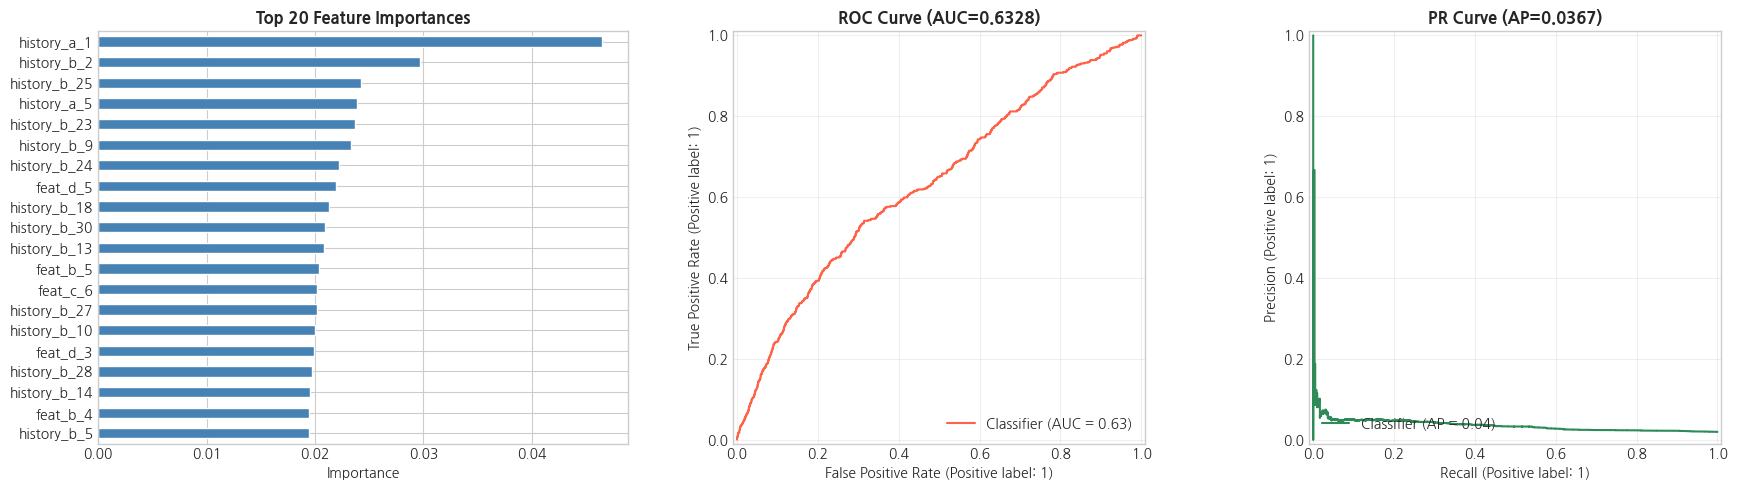

💾 저장됨: xgb_quick_validation.png
Top 10 features:


,importance
history_a_1,0.046529
history_b_2,0.029709
history_b_25,0.024235
history_a_5,0.023913
history_b_23,0.023654
history_b_9,0.023283
history_b_24,0.022255
feat_d_5,0.021898
history_b_18,0.021319
history_b_30,0.020962


In [104]:
# ============================================================
# [8-1] XGBoost 검증 시각화
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

importance = (
    pd.Series(xgb_quick_model.feature_importances_, index=xgb_quick_features)
    .sort_values(ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

importance.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Feature Importances', fontweight='bold')
axes[0].set_xlabel('Importance')

RocCurveDisplay.from_predictions(xgb_quick_val_true, xgb_quick_val_pred, ax=axes[1], color='tomato')
axes[1].set_title(f"ROC Curve (AUC={xgb_quick_metrics['val_auc']:.4f})", fontweight='bold')
axes[1].grid(alpha=0.3)

PrecisionRecallDisplay.from_predictions(
    xgb_quick_val_true,
    xgb_quick_val_pred,
    ax=axes[2],
    color='seagreen',
)
axes[2].set_title(f"PR Curve (AP={xgb_quick_metrics['val_ap']:.4f})", fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = (Path(ROOT_DIR) if 'ROOT_DIR' in globals() else Path.cwd()) / 'xgb_quick_validation.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'💾 저장됨: {plot_path}')
print('Top 10 features:')
display(importance.head(10).rename('importance').to_frame())

In [105]:
# ============================================================
# [8-2] XGBoost 결과 요약
# ============================================================

print('=' * 64)
print('빠른 검증 결론')
print('=' * 64)
print(f"Val AUC     : {xgb_quick_metrics['val_auc']:.4f}")
print(f"Val AP      : {xgb_quick_metrics['val_ap']:.4f}")
print(f"Val LogLoss : {xgb_quick_metrics['val_logloss']:.4f}")
print(f"사용 피처 수 : {xgb_quick_metrics['n_features']}")
print('')
print('권장 판단:')
print('- DCN 병목 디버깅은 보류하고 XGBoost 결과를 기준선으로 채택')
print('- 논문/보고서에는 AUC, AP, 상위 중요도 피처를 우선 사용')
print('- 추가 해석이 필요하면 이 모델 기준으로 SHAP만 덧붙이면 됨')

빠른 검증 결론
Val AUC     : 0.6328
Val AP      : 0.0367
Val LogLoss : 0.4662
사용 피처 수 : 50

권장 판단:
- DCN 병목 디버깅은 보류하고 XGBoost 결과를 기준선으로 채택
- 논문/보고서에는 AUC, AP, 상위 중요도 피처를 우선 사용
- 추가 해석이 필요하면 이 모델 기준으로 SHAP만 덧붙이면 됨


In [106]:
# ============================================================
# [8-3] XGBoost 피처 수 확장 실험
# - top 50 / 75 / 100 / 전체 피처 비교
# - 동일 split 유지로 공정 비교
# ============================================================

import pandas as pd
import xgboost as xgb
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score

if 'ranked_features' not in globals() or len(ranked_features) == 0:
    raise RuntimeError('ranked_features가 없습니다. 먼저 94번 셀을 실행하세요.')

train_idx = X_train.index if 'X_train' in globals() else None
val_idx = X_val.index if 'X_val' in globals() else None
if train_idx is None or val_idx is None:
    raise RuntimeError('train/validation split 정보가 없습니다. 먼저 94번 셀을 실행하세요.')

candidate_counts = []
for n_features in [50, 75, 100, len(ranked_features)]:
    n_features = min(n_features, len(ranked_features))
    if n_features not in candidate_counts:
        candidate_counts.append(n_features)

feature_sweep_rows = []
best_sweep_auc = -1.0
best_sweep_model = None
best_sweep_features = None

for n_features in candidate_counts:
    feature_subset = ranked_features[:n_features]
    X_subset = (
        base_df[feature_subset]
        .apply(pd.to_numeric, errors='coerce')
        .fillna(0)
        .astype('float32')
    )

    X_train_subset = X_subset.loc[train_idx]
    X_val_subset = X_subset.loc[val_idx]

    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric=['aucpr', 'auc', 'logloss'],
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        scale_pos_weight=scale_pos_weight,
        reg_lambda=1.0,
    )

    print(f'학습 중: top {n_features} features')
    model.fit(
        X_train_subset,
        y_train,
        eval_set=[(X_val_subset, y_val)],
        verbose=False,
    )

    val_pred = model.predict_proba(X_val_subset)[:, 1]
    row = {
        'n_features': n_features,
        'val_auc': roc_auc_score(y_val, val_pred),
        'val_ap': average_precision_score(y_val, val_pred),
        'val_logloss': log_loss(y_val, val_pred),
    }
    feature_sweep_rows.append(row)

    if row['val_auc'] > best_sweep_auc:
        best_sweep_auc = row['val_auc']
        best_sweep_model = model
        best_sweep_features = feature_subset
        best_sweep_pred = val_pred

xgb_feature_sweep_results = pd.DataFrame(feature_sweep_rows).sort_values('val_auc', ascending=False).reset_index(drop=True)
xgb_best_feature_count = int(xgb_feature_sweep_results.iloc[0]['n_features'])
xgb_best_metrics = xgb_feature_sweep_results.iloc[0].to_dict()
xgb_best_model = best_sweep_model
xgb_best_features = best_sweep_features
xgb_best_val_pred = best_sweep_pred

print('\n[피처 수 확장 결과]')
display(xgb_feature_sweep_results)
print(f"\n✅ 최고 AUC 설정: top {xgb_best_feature_count} features")
print(f"   Val AUC     : {xgb_best_metrics['val_auc']:.4f}")
print(f"   Val AP      : {xgb_best_metrics['val_ap']:.4f}")
print(f"   Val LogLoss : {xgb_best_metrics['val_logloss']:.4f}")

학습 중: top 50 features
학습 중: top 75 features
학습 중: top 100 features
학습 중: top 112 features

[피처 수 확장 결과]


,n_features,val_auc,val_ap,val_logloss
0,100,0.670743,0.049155,0.495920
1,75,0.666838,0.045469,0.502626
2,112,0.666553,0.049946,0.496656
3,50,0.643709,0.042773,0.525826



✅ 최고 AUC 설정: top 100 features
   Val AUC     : 0.6707
   Val AP      : 0.0492
   Val LogLoss : 0.4959


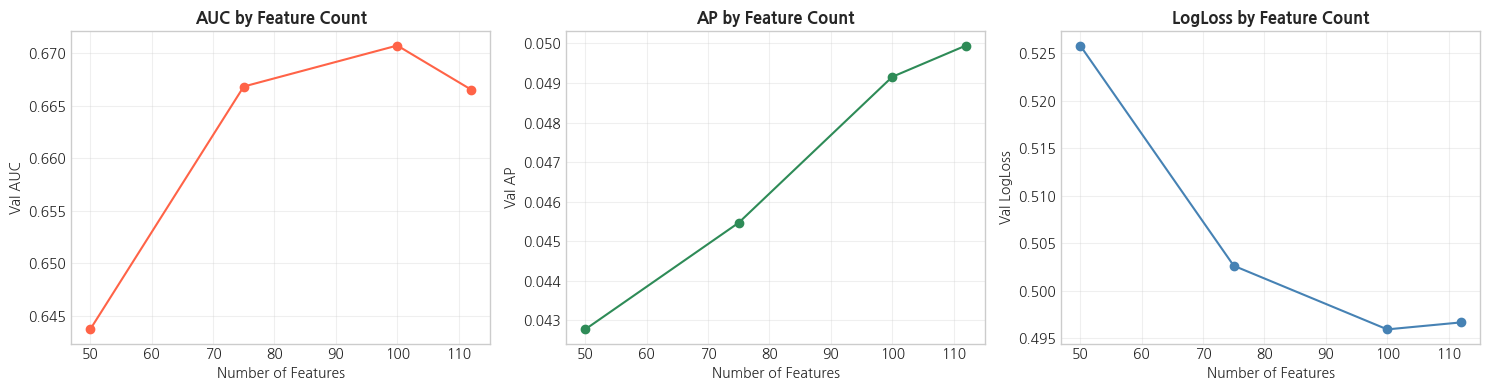

권장 설정 요약
- 최고 AUC 피처 수: 100
- 최고 AUC: 0.6707
- 해당 AP : 0.0492
- 해당 LogLoss: 0.4959


In [107]:
# ============================================================
# [8-4] 피처 수 확장 결과 시각화
# ============================================================

import matplotlib.pyplot as plt

plot_df = xgb_feature_sweep_results.sort_values('n_features').reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(plot_df['n_features'], plot_df['val_auc'], marker='o', color='tomato')
axes[0].set_title('AUC by Feature Count', fontweight='bold')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('Val AUC')
axes[0].grid(alpha=0.3)

axes[1].plot(plot_df['n_features'], plot_df['val_ap'], marker='o', color='seagreen')
axes[1].set_title('AP by Feature Count', fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Val AP')
axes[1].grid(alpha=0.3)

axes[2].plot(plot_df['n_features'], plot_df['val_logloss'], marker='o', color='steelblue')
axes[2].set_title('LogLoss by Feature Count', fontweight='bold')
axes[2].set_xlabel('Number of Features')
axes[2].set_ylabel('Val LogLoss')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('권장 설정 요약')
print(f"- 최고 AUC 피처 수: {xgb_best_feature_count}")
print(f"- 최고 AUC: {xgb_best_metrics['val_auc']:.4f}")
print(f"- 해당 AP : {xgb_best_metrics['val_ap']:.4f}")
print(f"- 해당 LogLoss: {xgb_best_metrics['val_logloss']:.4f}")

---
## 9. 추론 <a id='9'></a>

In [108]:
# ============================================================
# [9] 추론 (Best XGBoost 기준)
# - 최고 성능 피처 수(top 112) 기준 모델로 test 예측
# - submission 파일까지 바로 생성
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

if 'xgb_best_model' not in globals() or 'xgb_best_features' not in globals():
    raise RuntimeError('Best XGBoost 모델이 없습니다. 먼저 97번 셀까지 실행하세요.')

if 'BASE_DIR' not in globals():
    candidates = [Path.cwd(), Path.cwd().parent, Path('C:/statistical_ctr_analysis')]
    BASE_DIR = next((path for path in candidates if (path / 'data').exists()), Path.cwd())

test_path = BASE_DIR / 'data' / 'test.parquet'
sample_path = BASE_DIR / 'data' / 'sample_submission.csv'

print('test.parquet 전체 로드 중...')
pf = pq.ParquetFile(str(test_path))
batches = [batch.to_pandas() for batch in pf.iter_batches(batch_size=100_000)]
test = pd.concat(batches, ignore_index=True)
sample = pd.read_csv(sample_path)

X_test_best = (
    test[xgb_best_features]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(np.float32)
)

test_preds = xgb_best_model.predict_proba(X_test_best)[:, 1]
submission = sample.copy()
submission['clicked'] = test_preds

submission_path = BASE_DIR / 'notebooks' / 'submission_xgb_best.csv'
submission.to_csv(submission_path, index=False)

print('✅ XGBoost 추론 완료')
print(f'   test shape      : {test.shape}')
print(f'   feature count   : {len(xgb_best_features)}')
print(f'   pred range      : [{test_preds.min():.6f}, {test_preds.max():.6f}]')
print(f'   mean pred CTR   : {test_preds.mean():.6f}')
print(f'   저장 경로       : {submission_path}')
print('')
print(submission.head())

test.parquet 전체 로드 중...
✅ XGBoost 추론 완료
   test shape      : (1527298, 119)
   feature count   : 100
   pred range      : [0.005269, 0.932571]
   mean pred CTR   : 0.326007
   저장 경로       : ..\notebooks\submission_xgb_best.csv

             ID   clicked
0  TEST_0000000  0.205968
1  TEST_0000001  0.339826
2  TEST_0000002  0.388029
3  TEST_0000003  0.406483
4  TEST_0000004  0.361315


---
## 9-1. XGBoost SHAP 해석

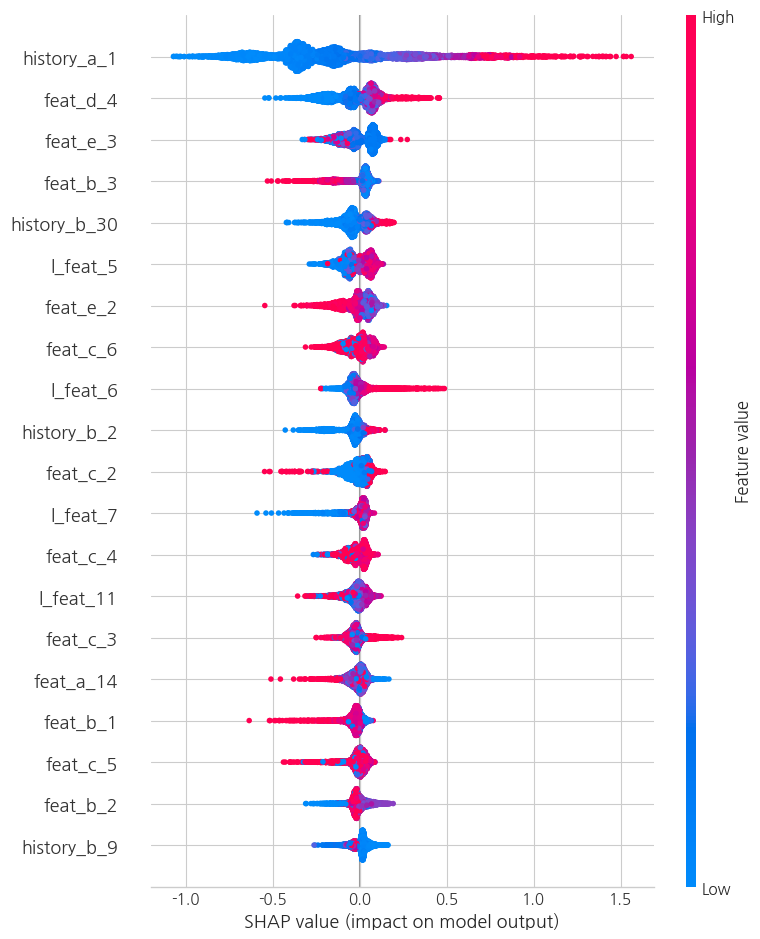

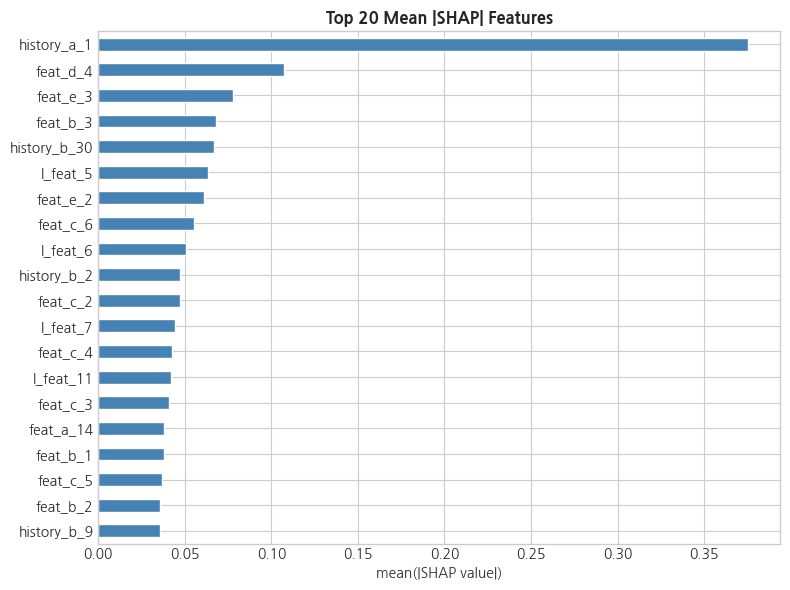

✅ SHAP 해석 완료
   summary plot: ..\notebooks\xgb_best_shap_summary.png
   importance  : ..\notebooks\xgb_best_shap_importance.png



,mean_abs_shap
history_a_1,0.375123
feat_d_4,0.107171
feat_e_3,0.077814
feat_b_3,0.068176
history_b_30,0.066923
l_feat_5,0.063139
feat_e_2,0.060959
feat_c_6,0.055296
l_feat_6,0.050615
history_b_2,0.047321


In [109]:
# ============================================================
# [9-1] SHAP 해석 (Best XGBoost 기준)
# - 상위 112개 피처 모델에 대한 글로벌 중요도/방향성 확인
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

if 'xgb_best_model' not in globals() or 'xgb_best_features' not in globals():
    raise RuntimeError('Best XGBoost 모델이 없습니다. 먼저 97번 셀까지 실행하세요.')

shap_sample_size = min(5000, len(train_idx))
X_shap = (
    base_df.loc[train_idx, xgb_best_features]
    .sample(n=shap_sample_size, random_state=42)
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(np.float32)
)

explainer = shap.TreeExplainer(xgb_best_model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_importance = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=X_shap.columns)
    .sort_values(ascending=False)
    .rename('mean_abs_shap')
)
top_shap_importance = shap_importance.head(20)

output_dir = BASE_DIR / 'notebooks' if 'BASE_DIR' in globals() else Path.cwd()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
plt.tight_layout()
shap_summary_path = output_dir / 'xgb_best_shap_summary.png'
plt.savefig(shap_summary_path, dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
top_shap_importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Mean |SHAP| Features', fontweight='bold')
plt.xlabel('mean(|SHAP value|)')
plt.tight_layout()
shap_bar_path = output_dir / 'xgb_best_shap_importance.png'
plt.savefig(shap_bar_path, dpi=150, bbox_inches='tight')
plt.show()

print('✅ SHAP 해석 완료')
print(f'   summary plot: {shap_summary_path}')
print(f'   importance  : {shap_bar_path}')
print('')
display(top_shap_importance.to_frame())

---
## 9-2. 논문용 최종 요약

In [110]:
# ============================================================
# [9-2] 논문용 최종 요약 생성
# - 성능표, SHAP 상위 피처표, 본문용 서술문 자동 생성
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

if 'xgb_feature_sweep_results' not in globals():
    raise RuntimeError('피처 수 확장 결과가 없습니다. 먼저 97~98번 셀을 실행하세요.')
if 'top_shap_importance' not in globals() or 'X_shap' not in globals() or 'shap_values' not in globals():
    raise RuntimeError('SHAP 결과가 없습니다. 먼저 102번 셀을 실행하세요.')

paper_dir = BASE_DIR / 'notebooks' if 'BASE_DIR' in globals() else Path.cwd()

performance_table = xgb_feature_sweep_results.copy()
performance_table['val_auc'] = performance_table['val_auc'].round(4)
performance_table['val_ap'] = performance_table['val_ap'].round(4)
performance_table['val_logloss'] = performance_table['val_logloss'].round(4)
performance_table = performance_table.rename(columns={
    'n_features': '피처 수',
    'val_auc': '검증 AUC',
    'val_ap': '검증 AP',
    'val_logloss': '검증 LogLoss',
})

direction_rows = []
for rank, feature in enumerate(top_shap_importance.index[:10], start=1):
    shap_idx = X_shap.columns.get_loc(feature)
    feature_values = X_shap[feature].to_numpy()
    shap_col = np.asarray(shap_values)[:, shap_idx]
    if np.std(feature_values) == 0 or np.std(shap_col) == 0:
        direction = '해석 보류'
        corr_val = 0.0
    else:
        corr_val = float(np.corrcoef(feature_values, shap_col)[0, 1])
        direction = '값이 클수록 CTR 상승' if corr_val >= 0 else '값이 클수록 CTR 하락'
    direction_rows.append({
        '순위': rank,
        '피처': feature,
        '평균 |SHAP|': round(float(top_shap_importance.loc[feature]), 4),
        '방향성': direction,
        'feature_shap_corr': round(corr_val, 4),
    })

shap_table = pd.DataFrame(direction_rows)

best_auc = float(xgb_best_metrics['val_auc'])
best_ap = float(xgb_best_metrics['val_ap'])
best_logloss = float(xgb_best_metrics['val_logloss'])
best_feature_count = int(xgb_best_feature_count)

top3 = shap_table.head(3)
top3_text = '; '.join(
    f"{row['피처']}({row['방향성']})" for _, row in top3.iterrows()
)

paper_summary_lines = [
    '논문용 결과 요약',
    '=' * 60,
    f"최종 채택 모델은 XGBoost이며, 상위 {best_feature_count}개 피처를 사용했을 때 가장 높은 검증 성능을 보였다.",
    f"해당 설정의 검증 성능은 AUC {best_auc:.4f}, AP {best_ap:.4f}, LogLoss {best_logloss:.4f}였다.",
    f"SHAP 분석 결과, 주요 설명 변수는 {top3_text} 순으로 확인되었다.",
    '이는 과거 반응 이력(history 계열)과 일부 행동/속성 피처가 CTR 예측에 핵심적으로 기여함을 시사한다.',
    '',
    '[본문용 서술 초안]',
    f"XGBoost 기반 추가 검증 결과, 상위 {best_feature_count}개 피처를 사용한 설정이 가장 우수한 성능을 보였다 (Validation AUC={best_auc:.4f}, AP={best_ap:.4f}, LogLoss={best_logloss:.4f}).",
    f"SHAP 해석 결과, {top3_text} 등이 예측에 가장 큰 영향을 미쳤으며, 특히 상위 피처는 클릭 확률을 증가 또는 감소시키는 방향성이 뚜렷하게 관찰되었다.",
    '종합하면, CTR은 단일 인구통계 변수보다 과거 반응 이력과 일부 세부 행동 피처의 결합에 의해 더 강하게 설명되며, 이는 통계 분석에서 확인한 변수 중요도가 머신러닝 검증에서도 재현됨을 의미한다.',
]

paper_summary_text = '\n'.join(paper_summary_lines)

performance_csv = paper_dir / 'paper_xgb_performance_table.csv'
shap_csv = paper_dir / 'paper_xgb_shap_top10.csv'
summary_txt = paper_dir / 'paper_xgb_summary.txt'

performance_table.to_csv(performance_csv, index=False, encoding='utf-8-sig')
shap_table.to_csv(shap_csv, index=False, encoding='utf-8-sig')
summary_txt.write_text(paper_summary_text, encoding='utf-8')

print('✅ 논문용 최종 요약 생성 완료')
print(f'   성능표 저장 : {performance_csv}')
print(f'   SHAP 표 저장: {shap_csv}')
print(f'   서술문 저장 : {summary_txt}')
print('')
print('[성능 비교표]')
display(performance_table)
print('')
print('[SHAP 상위 10개 피처 표]')
display(shap_table)
print('')
print(paper_summary_text)

✅ 논문용 최종 요약 생성 완료
   성능표 저장 : ..\notebooks\paper_xgb_performance_table.csv
   SHAP 표 저장: ..\notebooks\paper_xgb_shap_top10.csv
   서술문 저장 : ..\notebooks\paper_xgb_summary.txt

[성능 비교표]


,피처 수,검증 AUC,검증 AP,검증 LogLoss
0,100,0.6707,0.0492,0.4959
1,75,0.6668,0.0455,0.5026
2,112,0.6666,0.0499,0.4967
3,50,0.6437,0.0428,0.5258



[SHAP 상위 10개 피처 표]


,순위,피처,평균 |SHAP|,방향성,feature_shap_corr
0,1,history_a_1,0.3751,값이 클수록 CTR 상승,0.4429
1,2,feat_d_4,0.1072,값이 클수록 CTR 상승,0.8153
2,3,feat_e_3,0.0778,값이 클수록 CTR 하락,-0.4618
3,4,feat_b_3,0.0682,값이 클수록 CTR 하락,-0.8250
4,5,history_b_30,0.0669,값이 클수록 CTR 상승,0.3687
5,6,l_feat_5,0.0631,값이 클수록 CTR 상승,0.7399
6,7,feat_e_2,0.0610,값이 클수록 CTR 하락,-0.6198
7,8,feat_c_6,0.0553,값이 클수록 CTR 하락,-0.0761
8,9,l_feat_6,0.0506,값이 클수록 CTR 상승,0.7588
9,10,history_b_2,0.0473,값이 클수록 CTR 상승,0.2640



논문용 결과 요약
최종 채택 모델은 XGBoost이며, 상위 100개 피처를 사용했을 때 가장 높은 검증 성능을 보였다.
해당 설정의 검증 성능은 AUC 0.6707, AP 0.0492, LogLoss 0.4959였다.
SHAP 분석 결과, 주요 설명 변수는 history_a_1(값이 클수록 CTR 상승); feat_d_4(값이 클수록 CTR 상승); feat_e_3(값이 클수록 CTR 하락) 순으로 확인되었다.
이는 과거 반응 이력(history 계열)과 일부 행동/속성 피처가 CTR 예측에 핵심적으로 기여함을 시사한다.

[본문용 서술 초안]
XGBoost 기반 추가 검증 결과, 상위 100개 피처를 사용한 설정이 가장 우수한 성능을 보였다 (Validation AUC=0.6707, AP=0.0492, LogLoss=0.4959).
SHAP 해석 결과, history_a_1(값이 클수록 CTR 상승); feat_d_4(값이 클수록 CTR 상승); feat_e_3(값이 클수록 CTR 하락) 등이 예측에 가장 큰 영향을 미쳤으며, 특히 상위 피처는 클릭 확률을 증가 또는 감소시키는 방향성이 뚜렷하게 관찰되었다.
종합하면, CTR은 단일 인구통계 변수보다 과거 반응 이력과 일부 세부 행동 피처의 결합에 의해 더 강하게 설명되며, 이는 통계 분석에서 확인한 변수 중요도가 머신러닝 검증에서도 재현됨을 의미한다.


---
## 9-3. 확률 보정 및 최종 제출

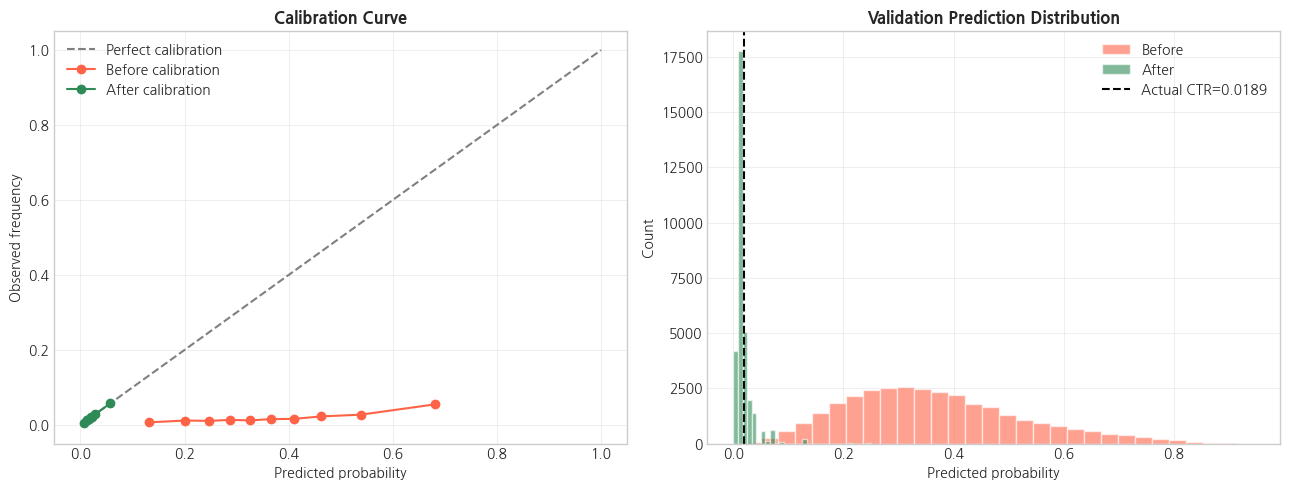

✅ 확률 보정 완료
   calibration plot : ..\notebooks\CTR_통합_최종_images\xgb_calibration_curve.png
   calibrated submission : ..\notebooks\submission_xgb_best_calibrated.csv
   test mean CTR before  : 0.326007
   test mean CTR after   : 0.016182



,stage,mean_pred,brier,logloss
0,before,0.365236,0.159608,0.495920
1,after,0.018938,0.018312,0.089168
2,actual_ctr,0.018937,NaN,NaN



             ID   clicked
0  TEST_0000000  0.012081
1  TEST_0000001  0.012432
2  TEST_0000002  0.016197
3  TEST_0000003  0.016197
4  TEST_0000004  0.012432


In [111]:
# ============================================================
# [9-3] 확률 보정 (Isotonic Regression)
# - validation 예측값을 기준으로 확률 보정
# - 보정 전후 calibration 품질과 평균 CTR 비교
# - 보정된 submission 생성
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss

if 'xgb_best_val_pred' not in globals() or 'y_val' not in globals():
    raise RuntimeError('validation 예측값이 없습니다. 먼저 97번 셀까지 실행하세요.')
if 'test_preds' not in globals():
    raise RuntimeError('test 예측값이 없습니다. 먼저 100번 셀을 실행하세요.')

calibrator = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
calibrator.fit(xgb_best_val_pred, y_val)

val_pred_raw = np.asarray(xgb_best_val_pred)
val_pred_cal = calibrator.transform(val_pred_raw)
test_preds_cal = calibrator.transform(np.asarray(test_preds))

raw_metrics = {
    'mean_pred': float(val_pred_raw.mean()),
    'brier': float(brier_score_loss(y_val, val_pred_raw)),
    'logloss': float(log_loss(y_val, np.clip(val_pred_raw, 1e-6, 1 - 1e-6))),
}
cal_metrics = {
    'mean_pred': float(val_pred_cal.mean()),
    'brier': float(brier_score_loss(y_val, val_pred_cal)),
    'logloss': float(log_loss(y_val, np.clip(val_pred_cal, 1e-6, 1 - 1e-6))),
}
actual_ctr = float(np.mean(y_val))

prob_true_raw, prob_pred_raw = calibration_curve(y_val, val_pred_raw, n_bins=10, strategy='quantile')
prob_true_cal, prob_pred_cal = calibration_curve(y_val, val_pred_cal, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
axes[0].plot(prob_pred_raw, prob_true_raw, marker='o', label='Before calibration', color='tomato')
axes[0].plot(prob_pred_cal, prob_true_cal, marker='o', label='After calibration', color='seagreen')
axes[0].set_title('Calibration Curve', fontweight='bold')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Observed frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(val_pred_raw, bins=30, alpha=0.6, label='Before', color='tomato')
axes[1].hist(val_pred_cal, bins=30, alpha=0.6, label='After', color='seagreen')
axes[1].axvline(actual_ctr, color='black', linestyle='--', label=f'Actual CTR={actual_ctr:.4f}')
axes[1].set_title('Validation Prediction Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
image_dir = BASE_DIR / 'notebooks' / 'CTR_통합_최종_images' if 'BASE_DIR' in globals() else Path.cwd()
image_dir.mkdir(parents=True, exist_ok=True)
calibration_plot_path = image_dir / 'xgb_calibration_curve.png'
plt.savefig(calibration_plot_path, dpi=150, bbox_inches='tight')
plt.show()

submission_calibrated = sample.copy()
submission_calibrated['clicked'] = test_preds_cal
submission_calibrated_path = (BASE_DIR / 'notebooks' / 'submission_xgb_best_calibrated.csv') if 'BASE_DIR' in globals() else Path.cwd() / 'submission_xgb_best_calibrated.csv'
submission_calibrated.to_csv(submission_calibrated_path, index=False)

calibration_summary = pd.DataFrame([
    {'stage': 'before', 'mean_pred': raw_metrics['mean_pred'], 'brier': raw_metrics['brier'], 'logloss': raw_metrics['logloss']},
    {'stage': 'after', 'mean_pred': cal_metrics['mean_pred'], 'brier': cal_metrics['brier'], 'logloss': cal_metrics['logloss']},
    {'stage': 'actual_ctr', 'mean_pred': actual_ctr, 'brier': np.nan, 'logloss': np.nan},
])

print('✅ 확률 보정 완료')
print(f'   calibration plot : {calibration_plot_path}')
print(f'   calibrated submission : {submission_calibrated_path}')
print(f'   test mean CTR before  : {np.mean(test_preds):.6f}')
print(f'   test mean CTR after   : {np.mean(test_preds_cal):.6f}')
print('')
display(calibration_summary)
print('')
print(submission_calibrated.head())

---
## 10. PCA & 클러스터링 <a id='sec7'></a>

🚀 Part 3: 고급 분석 - PCA/클러스터링 + 심화 인사이트
📊 로드된 데이터: 200,000 샘플

🔍 피처 상호작용 심화 분석
📊 inventory_id x 시간대 상호작용:
최고 성과 조합 (inventory_id x hour):
                    샘플수  클릭수     클릭률
inventory_id hour                   
14           07     420   27  0.0643
             02     230   14  0.0609
             21     600   31  0.0517
             05     214   11  0.0514
             16     607   30  0.0494
7            15     973   48  0.0493
5            07     233   11  0.0472
7            17    1055   46  0.0436
14           14     588   25  0.0425
             06     284   12  0.0423

📊 연령그룹 x 다양성 비율 상호작용:
                         샘플수     클릭률
age_group diversity_bin             
0         very_high       52  0.1731
          medium         187  0.0963
8         very_high       11  0.0909
0         low            224  0.0714
          high            63  0.0635
7         very_high      396  0.0631
8         medium          92  0.0543
7         high           440  0.0523
6         very_high      84

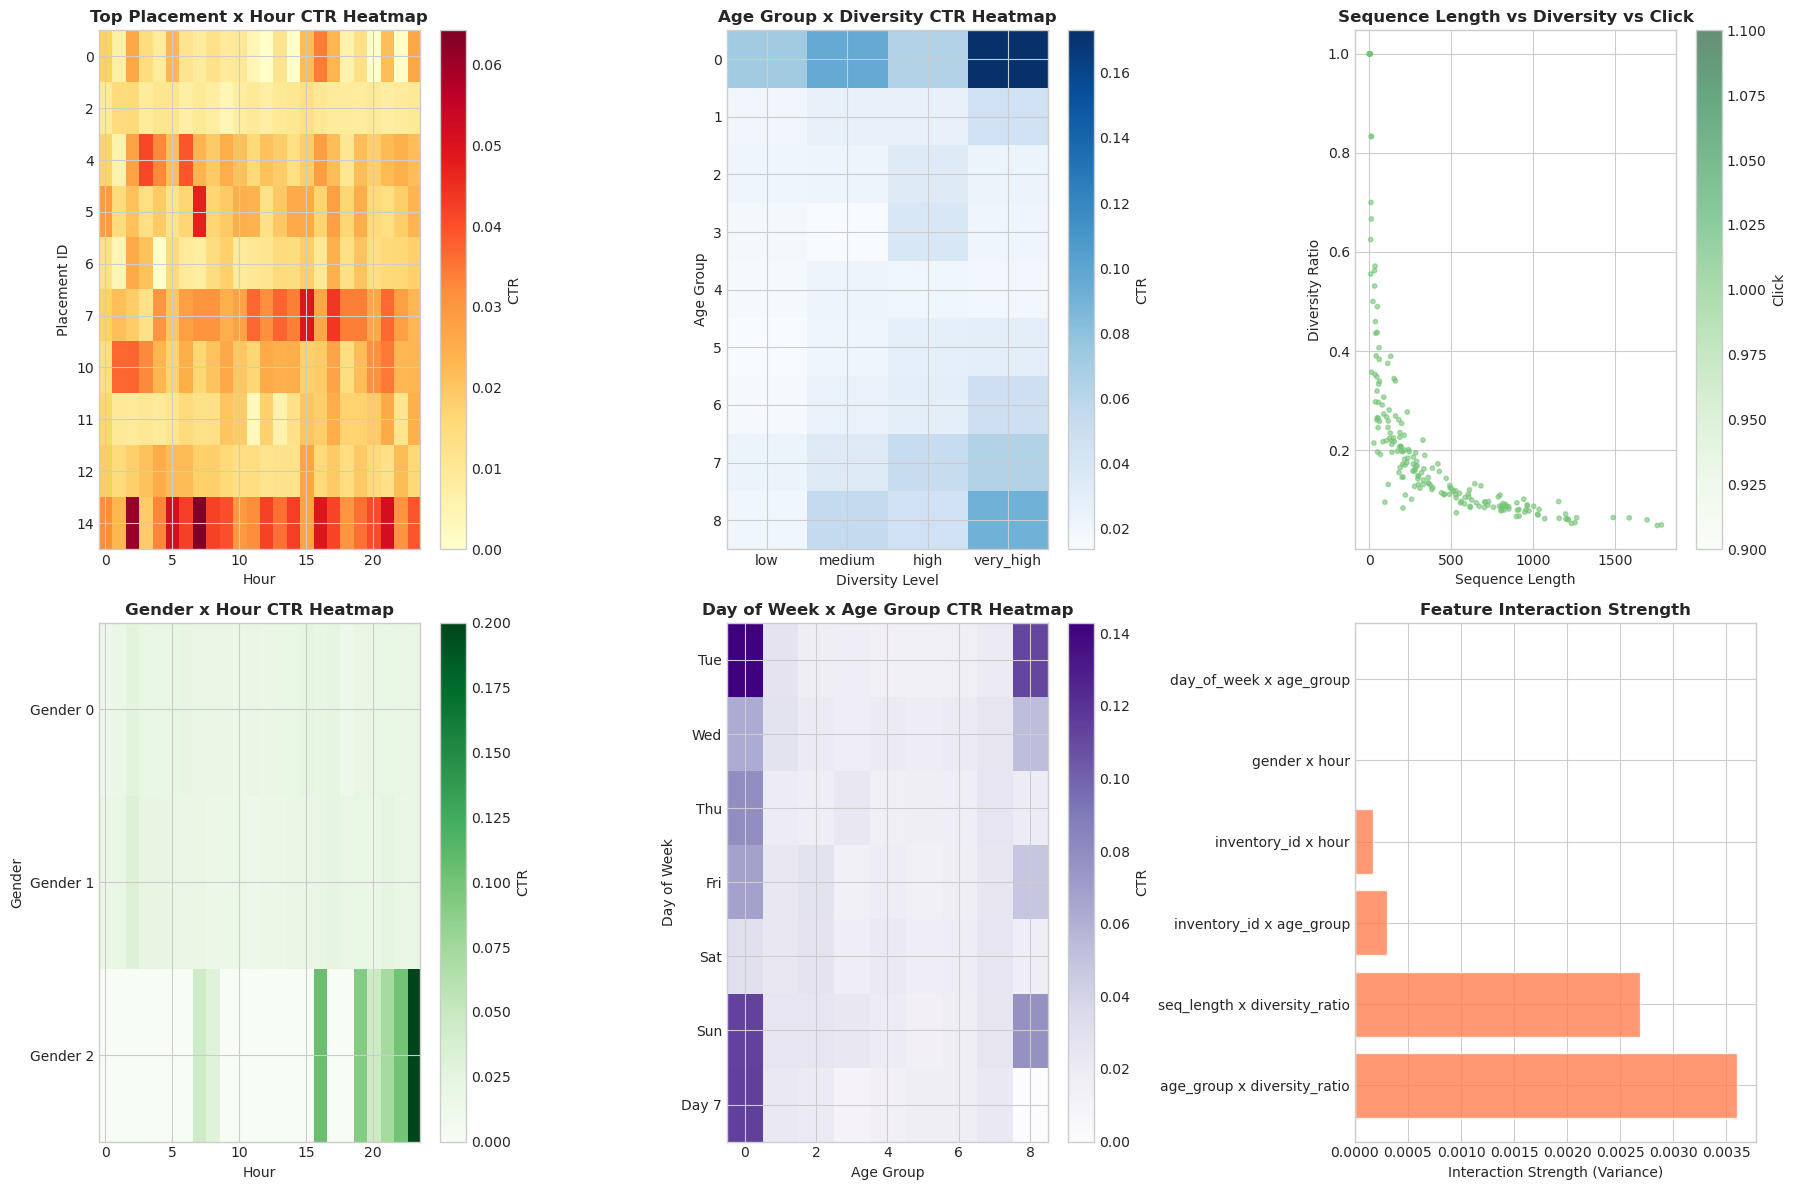

In [114]:
# 광고 클릭 예측 데이터 분석 - Part 3
# 고급 분석: PCA/클러스터링 + 심화 인사이트 + 인터랙티브 분석

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# # 한글 폰트 설정
# plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial Unicode MS', 'Malgun Gothic']
# plt.rcParams['axes.unicode_minus'] = False
# plt.style.use('default')
# sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("🚀 Part 3: 고급 분석 - PCA/클러스터링 + 심화 인사이트")
print("=" * 70)

# 데이터 로드
df = train.copy()  # 섹션 1에서 로드한 train_sample 재사용

# 시퀀스 분석 결과 재생성 (Part 2에서 생성한 피처들)
df['seq_length'] = df['seq'].str.split(',').str.len()
def count_unique_items(seq_str):
    try:
        items = seq_str.split(',')
        return len(set(items))
    except:
        return 0

def normalize_day_label(value):
    day_name_map = {
        0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun',
        '0': 'Mon', '1': 'Tue', '2': 'Wed', '3': 'Thu', '4': 'Fri', '5': 'Sat', '6': 'Sun',
        'mon': 'Mon', 'monday': 'Mon',
        'tue': 'Tue', 'tues': 'Tue', 'tuesday': 'Tue',
        'wed': 'Wed', 'wednesday': 'Wed',
        'thu': 'Thu', 'thur': 'Thu', 'thurs': 'Thu', 'thursday': 'Thu',
        'fri': 'Fri', 'friday': 'Fri',
        'sat': 'Sat', 'saturday': 'Sat',
        'sun': 'Sun', 'sunday': 'Sun',
        '월': 'Mon', '화': 'Tue', '수': 'Wed', '목': 'Thu', '금': 'Fri', '토': 'Sat', '일': 'Sun'
    }
    if pd.isna(value):
        return 'Unknown'
    if value in day_name_map:
        return day_name_map[value]

    text = str(value).strip()
    lowered = text.lower()
    if lowered in day_name_map:
        return day_name_map[lowered]

    try:
        numeric_value = int(float(text))
        return day_name_map.get(numeric_value, f'Day {numeric_value}')
    except (TypeError, ValueError):
        return text.title()

df['unique_items'] = df['seq'].apply(count_unique_items)
df['diversity_ratio'] = df['unique_items'] / df['seq_length']

print(f"📊 로드된 데이터: {len(df):,} 샘플")

# ========================================
# 🔍 1. 피처 상호작용 심화 분석
# ========================================

print("\n" + "="*70)
print("🔍 피처 상호작용 심화 분석")
print("="*70)

# 핵심 피처들 정의 (Part 2 결과 기반)
top_features = [
    'history_a_1', 'history_a_2', 'history_b_2', 'history_a_3', 'history_b_30',
    'history_a_5', 'history_b_1', 'inventory_id', 'feat_b_4', 'history_b_10'
]

# 시간 + 사용자 + 시퀀스 피처
context_features = ['hour', 'day_of_week', 'gender', 'age_group', 'seq_length', 'diversity_ratio']

# 상호작용 분석: inventory_id x 시간대
print("📊 inventory_id x 시간대 상호작용:")
inv_hour_analysis = df.groupby(['inventory_id', 'hour']).agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
inv_hour_analysis.columns = ['샘플수', '클릭수', '클릭률']

# 상위 inventory_id들만 분석
top_inventories = df['inventory_id'].value_counts().head(10).index
inv_hour_filtered = inv_hour_analysis.loc[top_inventories]
best_combinations = inv_hour_filtered.sort_values('클릭률', ascending=False).head(10)
print("최고 성과 조합 (inventory_id x hour):")
print(best_combinations)

# 연령그룹 x 다양성 비율 상호작용
print(f"\n📊 연령그룹 x 다양성 비율 상호작용:")
df['diversity_bin'] = pd.cut(df['diversity_ratio'], bins=4, labels=['low', 'medium', 'high', 'very_high'])
age_diversity_analysis = df.groupby(['age_group', 'diversity_bin']).agg({
    'clicked': ['count', 'mean']
}).round(4)
age_diversity_analysis.columns = ['샘플수', '클릭률']
print(age_diversity_analysis.sort_values('클릭률', ascending=False).head(10))

# 상호작용 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. inventory_id TOP 10의 시간별 클릭률 히트맵
top_inv_hour = df[df['inventory_id'].isin(top_inventories)]
pivot_inv_hour = top_inv_hour.groupby(['inventory_id', 'hour'])['clicked'].mean().unstack(fill_value=0)
im1 = axes[0,0].imshow(pivot_inv_hour.values, cmap='YlOrRd', aspect='auto')
axes[0,0].set_title('Top Placement x Hour CTR Heatmap', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Placement ID')
axes[0,0].set_yticks(range(len(pivot_inv_hour.index)))
axes[0,0].set_yticklabels(pivot_inv_hour.index)
plt.colorbar(im1, ax=axes[0,0], label='CTR')

# 2. 연령그룹 x 다양성 히트맵
pivot_age_div = df.groupby(['age_group', 'diversity_bin'])['clicked'].mean().unstack(fill_value=0)
im2 = axes[0,1].imshow(pivot_age_div.values, cmap='Blues', aspect='auto')
axes[0,1].set_title('Age Group x Diversity CTR Heatmap', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Diversity Level')
axes[0,1].set_ylabel('Age Group')
axes[0,1].set_yticks(range(len(pivot_age_div.index)))
axes[0,1].set_yticklabels(pivot_age_div.index)
axes[0,1].set_xticks(range(len(pivot_age_div.columns)))
axes[0,1].set_xticklabels(pivot_age_div.columns)
plt.colorbar(im2, ax=axes[0,1], label='CTR')

# 3. 시퀀스 길이 vs 다양성 vs 클릭률 (3D 스타일)
sample_df = df.sample(n=10000)  # 샘플링
sample_df = sample_df[sample_df['clicked'] == 1]
scatter = axes[0,2].scatter(sample_df['seq_length'], sample_df['diversity_ratio'], 
                           c=sample_df['clicked'], cmap='Greens', alpha=0.6, s=10)
axes[0,2].set_title('Sequence Length vs Diversity vs Click', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Sequence Length')
axes[0,2].set_ylabel('Diversity Ratio')
plt.colorbar(scatter, ax=axes[0,2], label='Click')

# 4. 성별 x 시간 x 클릭률
pivot_gender_hour = df.groupby(['gender', 'hour'])['clicked'].mean().unstack(fill_value=0)
im3 = axes[1,0].imshow(pivot_gender_hour.values, cmap='Greens', aspect='auto')
axes[1,0].set_title('Gender x Hour CTR Heatmap', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Gender')
axes[1,0].set_yticks(range(len(pivot_gender_hour.index)))
axes[1,0].set_yticklabels([f'Gender {int(x)}' for x in pivot_gender_hour.index])
plt.colorbar(im3, ax=axes[1,0], label='CTR')

# 5. 요일 x 연령그룹 패턴
pivot_day_age = df.groupby(['day_of_week', 'age_group'])['clicked'].mean().unstack(fill_value=0)
im4 = axes[1,1].imshow(pivot_day_age.values, cmap='Purples', aspect='auto')
axes[1,1].set_title('Day of Week x Age Group CTR Heatmap', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Day of Week')
axes[1,1].set_yticks(range(len(pivot_day_age.index)))
axes[1,1].set_yticklabels([normalize_day_label(i) for i in pivot_day_age.index])
plt.colorbar(im4, ax=axes[1,1], label='CTR')

# 6. 종합 상호작용 강도 분석
interaction_strength = []
feature_pairs = [
    ('inventory_id', 'hour'), ('age_group', 'diversity_ratio'), 
    ('gender', 'hour'), ('day_of_week', 'age_group'),
    ('inventory_id', 'age_group'), ('seq_length', 'diversity_ratio')
]

for feat1, feat2 in feature_pairs:
    if feat1 in df.columns and feat2 in df.columns:
        cross_tab = pd.crosstab(df[feat1], df[feat2], df['clicked'], aggfunc='mean')
        variance = cross_tab.var().var() if not cross_tab.empty else 0
        interaction_strength.append((f'{feat1} x {feat2}', variance))

interaction_strength.sort(key=lambda x: x[1], reverse=True)
features_names = [item[0] for item in interaction_strength]
strengths = [item[1] for item in interaction_strength]

axes[1,2].barh(range(len(features_names)), strengths, color='coral', alpha=0.8)
axes[1,2].set_yticks(range(len(features_names)))
axes[1,2].set_yticklabels(features_names)
axes[1,2].set_title('Feature Interaction Strength', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Interaction Strength (Variance)')

plt.tight_layout()
plt.show()


🎯 PCA 차원축소 및 패턴 발견
📊 PCA 분석 결과:
   95% 분산 설명하는 성분 수: 58
   90% 분산 설명하는 성분 수: 46
   처음 10개 성분의 분산 설명율: 0.6109

🔍 PC1 (제1주성분) 주요 기여 피처 TOP 10:
          feature  importance
102  history_b_18    0.164842
105  history_b_21    0.164842
109  history_b_25    0.164842
100  history_b_16    0.164842
95   history_b_11    0.164841
107  history_b_23    0.164841
113  history_b_29    0.164840
90    history_b_6    0.164840
98   history_b_14    0.164839
108  history_b_24    0.164838

🔍 PC2 (제2주성분) 주요 기여 피처 TOP 10:
          feature  importance
58       feat_b_5    0.219567
116  unique_items    0.211706
115    seq_length    0.208944
81    history_a_4    0.206935
83    history_a_6    0.204517
37       feat_e_8    0.203322
84    history_a_7    0.202290
56       feat_b_3    0.188116
44       feat_d_5    0.183183
55       feat_b_2    0.182320


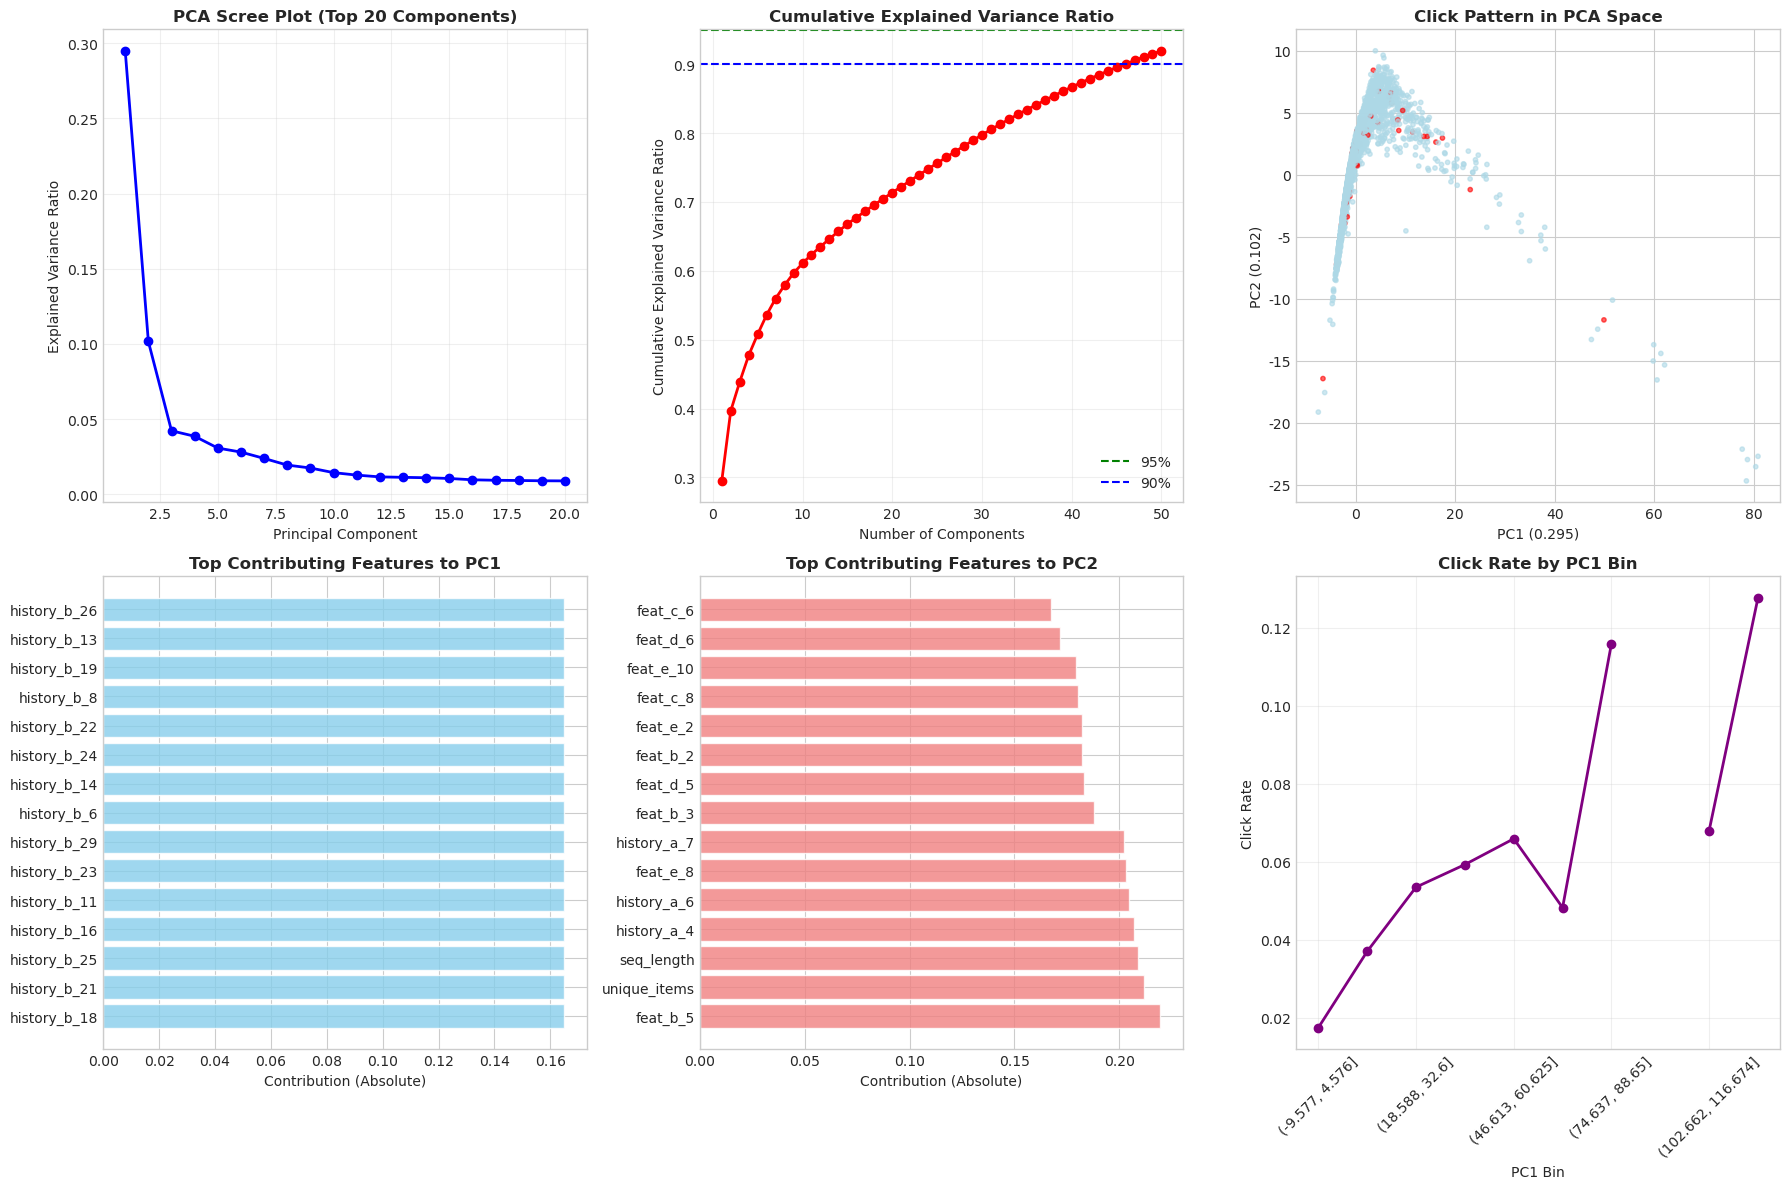

In [117]:
# ========================================
# 🎯 2. PCA 차원축소 및 패턴 발견
# ========================================

print("\n" + "="*70)
print("🎯 PCA 차원축소 및 패턴 발견")
print("="*70)

# 수치형 피처만 선택하고 결측값 처리
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['clicked']]

if len(numeric_cols) < 2:
    raise ValueError("PCA를 수행하려면 최소 2개 이상의 수치형 피처가 필요합니다.")

# PCA를 위한 데이터 준비
pca_data = df[numeric_cols].fillna(df[numeric_cols].median())
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

# PCA 수행
pca = PCA()
pca_result = pca.fit_transform(pca_data_scaled)

# 누적 분산 비율 계산
cumsum_var_ratio = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_var_ratio >= 0.95) + 1
n_components_90 = np.argmax(cumsum_var_ratio >= 0.90) + 1

summary_idx = min(9, len(cumsum_var_ratio) - 1)
print(f"📊 PCA 분석 결과:")
print(f"   95% 분산 설명하는 성분 수: {n_components_95}")
print(f"   90% 분산 설명하는 성분 수: {n_components_90}")
print(f"   처음 {summary_idx + 1}개 성분의 분산 설명율: {cumsum_var_ratio[summary_idx]:.4f}")

# 주성분별 피처 기여도 분석
feature_importance_pc1 = pd.DataFrame({
    'feature': numeric_cols,
    'importance': np.abs(pca.components_[0])
}).sort_values('importance', ascending=False)

feature_importance_pc2 = pd.DataFrame({
    'feature': numeric_cols,
    'importance': np.abs(pca.components_[1])
}).sort_values('importance', ascending=False)

print(f"\n🔍 PC1 (제1주성분) 주요 기여 피처 TOP 10:")
print(feature_importance_pc1.head(10))

print(f"\n🔍 PC2 (제2주성분) 주요 기여 피처 TOP 10:")
print(feature_importance_pc2.head(10))

# PCA 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 분산 설명율 스크리 플롯
scree_n = min(20, len(pca.explained_variance_ratio_))
axes[0,0].plot(range(1, scree_n + 1), pca.explained_variance_ratio_[:scree_n], 'bo-', linewidth=2)
axes[0,0].set_title('PCA Scree Plot (Top 20 Components)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Principal Component')
axes[0,0].set_ylabel('Explained Variance Ratio')
axes[0,0].grid(True, alpha=0.3)

# 2. 누적 분산 설명율
cum_n = min(50, len(cumsum_var_ratio))
axes[0,1].plot(range(1, cum_n + 1), cumsum_var_ratio[:cum_n], 'ro-', linewidth=2)
axes[0,1].axhline(y=0.95, color='green', linestyle='--', label='95%')
axes[0,1].axhline(y=0.90, color='blue', linestyle='--', label='90%')
axes[0,1].set_title('Cumulative Explained Variance Ratio', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Number of Components')
axes[0,1].set_ylabel('Cumulative Explained Variance Ratio')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. PC1 vs PC2 산점도 (클릭별 색상)
rng = np.random.default_rng(RANDOM_STATE if 'RANDOM_STATE' in globals() else 42)
sample_n = min(5000, len(pca_result))
sample_indices = rng.choice(len(pca_result), size=sample_n, replace=False)
clicked_colors = df.iloc[sample_indices]['clicked'].map({0: 'lightblue', 1: 'red'})
axes[0,2].scatter(pca_result[sample_indices, 0], pca_result[sample_indices, 1], 
                  c=clicked_colors, alpha=0.6, s=10)
axes[0,2].set_title('Click Pattern in PCA Space', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
axes[0,2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')

# 4. PC1 기여도 상위 피처들
top_pc1_features = feature_importance_pc1.head(15)
axes[1,0].barh(range(len(top_pc1_features)), top_pc1_features['importance'], color='skyblue', alpha=0.8)
axes[1,0].set_yticks(range(len(top_pc1_features)))
axes[1,0].set_yticklabels(top_pc1_features['feature'])
axes[1,0].set_title('Top Contributing Features to PC1', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Contribution (Absolute)')

# 5. PC2 기여도 상위 피처들
top_pc2_features = feature_importance_pc2.head(15)
axes[1,1].barh(range(len(top_pc2_features)), top_pc2_features['importance'], color='lightcoral', alpha=0.8)
axes[1,1].set_yticks(range(len(top_pc2_features)))
axes[1,1].set_yticklabels(top_pc2_features['feature'])
axes[1,1].set_title('Top Contributing Features to PC2', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Contribution (Absolute)')

# 6. 주성분별 클릭률 분석
pc1_bins = pd.cut(pca_result[:, 0], bins=10)
pc1_click_rate = df.groupby(pc1_bins, observed=False)['clicked'].mean()
pc1_click_rate.plot(kind='line', ax=axes[1,2], marker='o', color='purple', linewidth=2)
axes[1,2].set_title('Click Rate by PC1 Bin', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('PC1 Bin')
axes[1,2].set_ylabel('Click Rate')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🎨 클러스터링을 통한 사용자 세그먼트 발굴
Cluster Features :  ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour', 'l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4', 'l_feat_5', 'l_feat_6', 'l_feat_7', 'l_feat_8', 'l_feat_9', 'l_feat_10', 'l_feat_11', 'l_feat_12', 'l_feat_13', 'l_feat_14', 'l_feat_15', 'l_feat_16', 'l_feat_17', 'l_feat_18', 'l_feat_19', 'l_feat_20', 'l_feat_21', 'l_feat_22', 'l_feat_23', 'l_feat_24', 'l_feat_25', 'l_feat_26', 'l_feat_27', 'feat_e_1', 'feat_e_2', 'feat_e_3', 'feat_e_4', 'feat_e_5', 'feat_e_6', 'feat_e_7', 'feat_e_8', 'feat_e_9', 'feat_e_10', 'feat_d_1', 'feat_d_2', 'feat_d_3', 'feat_d_4', 'feat_d_5', 'feat_d_6', 'feat_c_1', 'feat_c_2', 'feat_c_3', 'feat_c_4', 'feat_c_5', 'feat_c_6', 'feat_c_7', 'feat_c_8', 'feat_b_1', 'feat_b_2', 'feat_b_3', 'feat_b_4', 'feat_b_5', 'feat_b_6', 'feat_a_1', 'feat_a_2', 'feat_a_3', 'feat_a_4', 'feat_a_5', 'feat_a_6', 'feat_a_7', 'feat_a_8', 'feat_a_9', 'feat_a_10', 'feat_a_11', 'feat_a_12', 'feat_a_13', 'feat_a_14', 'feat_a_15', 'fe

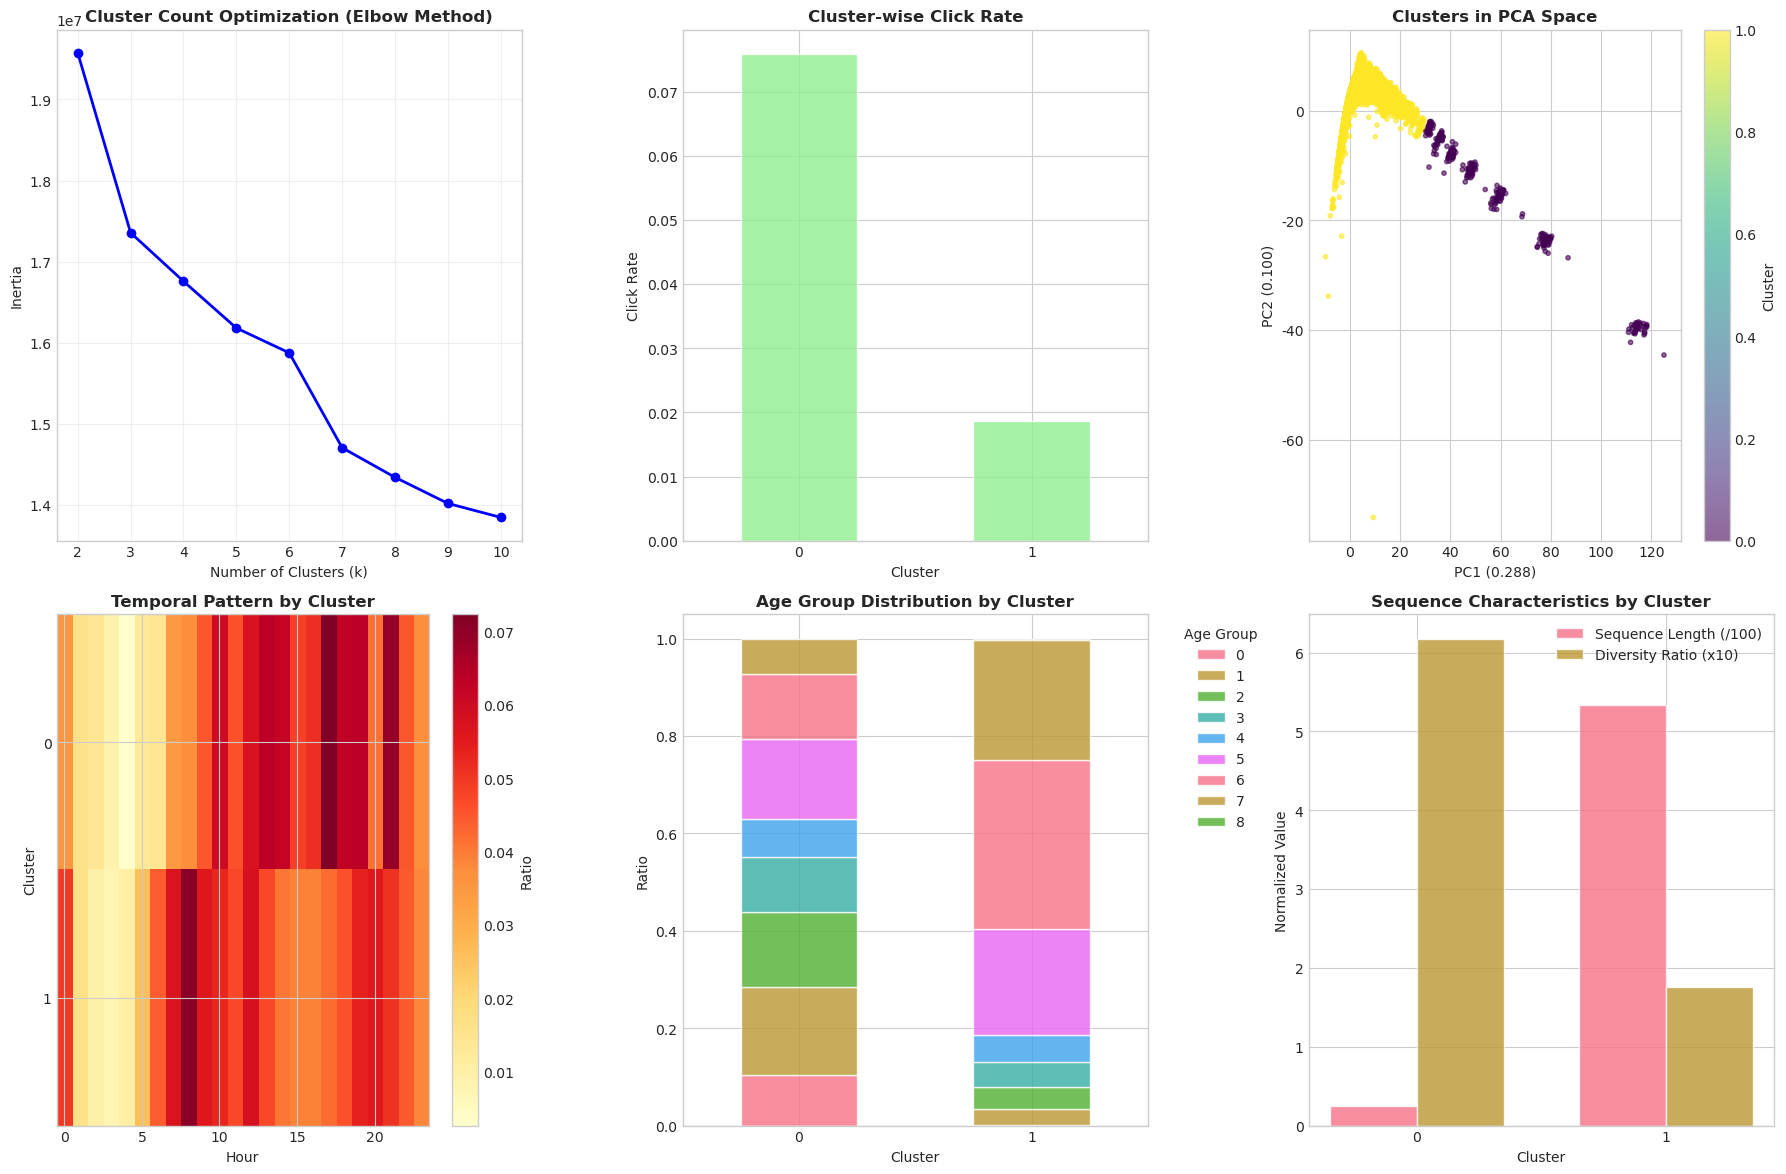

In [119]:
# ========================================
# 🎨 3. 클러스터링을 통한 사용자 세그먼트 발굴
# ========================================

print("\n" + "="*70)
print("🎨 클러스터링을 통한 사용자 세그먼트 발굴")
print("="*70)

# 클러스터링/요약에 사용하는 핵심 컬럼은 분석 전에 숫자형으로 정규화
cluster_base_cols = ['clicked', 'hour', 'day_of_week', 'gender', 'age_group', 'seq_length', 'diversity_ratio', 'inventory_id']
for col in cluster_base_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 수치형 피처만 선택하고 결측값 처리
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['clicked', 'cluster']]

if len(numeric_cols) < 2:
    raise ValueError("클러스터링을 수행하려면 최소 2개 이상의 수치형 피처가 필요합니다.")

pca_data = df[numeric_cols].fillna(df[numeric_cols].median())

print("Cluster Features : ", numeric_cols)

# 스케일링
scaler_cluster = StandardScaler()
clustering_data_scaled = scaler_cluster.fit_transform(pca_data)

# 최적 클러스터 수 찾기 (엘보우 방법)
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(clustering_data_scaled)
    inertias.append(kmeans.inertia_)

# 클러스터링 수행 (k=2로 설정)
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(clustering_data_scaled)

# 클러스터별 특성 분석
summary_cols = [col for col in ['clicked', 'hour', 'day_of_week', 'gender', 'age_group', 'seq_length', 'diversity_ratio', 'inventory_id'] if col in df.columns]
cluster_analysis = df.groupby('cluster').agg({
    'clicked': ['count', 'sum', 'mean'],
    **{col: 'mean' for col in summary_cols if col != 'clicked'}
}).round(3)

print(f"📊 클러스터별 특성 분석:")
print(cluster_analysis)

# 클러스터별 클릭률 분석
cluster_click_rates = df.groupby('cluster')['clicked'].mean().sort_values(ascending=False)
print(f"\n🎯 클러스터별 클릭률 랭킹:")
for i, (cluster, rate) in enumerate(cluster_click_rates.items()):
    print(f"   {i+1}. 클러스터 {cluster}: {rate:.4f} ({rate*100:.2f}%)")

# 클러스터링 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 엘보우 방법
axes[0,0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0,0].set_title('Cluster Count Optimization (Elbow Method)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Number of Clusters (k)')
axes[0,0].set_ylabel('Inertia')
axes[0,0].grid(True, alpha=0.3)

# 2. 클러스터별 클릭률
cluster_click_rates.plot(kind='bar', ax=axes[0,1], color='lightgreen', alpha=0.8)
axes[0,1].set_title('Cluster-wise Click Rate', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Cluster')
axes[0,1].set_ylabel('Click Rate')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. PCA 공간에서 클러스터 시각화
pca_2d = PCA(n_components=2)
pca_2d_result = pca_2d.fit_transform(clustering_data_scaled)
plot_n = min(50000, len(pca_2d_result))
rng = np.random.default_rng(RANDOM_STATE if 'RANDOM_STATE' in globals() else 42)
plot_idx = rng.choice(len(pca_2d_result), size=plot_n, replace=False)
scatter = axes[0,2].scatter(
    pca_2d_result[plot_idx, 0],
    pca_2d_result[plot_idx, 1],
    c=df.iloc[plot_idx]['cluster'],
    cmap='viridis',
    alpha=0.6,
    s=10
)
axes[0,2].set_title('Clusters in PCA Space', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.3f})')
axes[0,2].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.3f})')
plt.colorbar(scatter, ax=axes[0,2], label='Cluster')

# 4. 클러스터별 시간 패턴
if 'hour' in df.columns:
    cluster_hour = df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    cluster_hour_norm = cluster_hour.div(cluster_hour.sum(axis=1), axis=0)
    im5 = axes[1,0].imshow(cluster_hour_norm.values, cmap='YlOrRd', aspect='auto')
    axes[1,0].set_title('Temporal Pattern by Cluster', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Hour')
    axes[1,0].set_ylabel('Cluster')
    axes[1,0].set_yticks(range(len(cluster_hour_norm.index)))
    axes[1,0].set_yticklabels(cluster_hour_norm.index)
    plt.colorbar(im5, ax=axes[1,0], label='Ratio')
else:
    axes[1,0].set_visible(False)

# 5. 클러스터별 연령그룹 분포
if 'age_group' in df.columns:
    cluster_age = pd.crosstab(df['cluster'], df['age_group'], normalize='index')
    cluster_age.plot(kind='bar', ax=axes[1,1], stacked=True, alpha=0.8)
    axes[1,1].set_title('Age Group Distribution by Cluster', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Cluster')
    axes[1,1].set_ylabel('Ratio')
    axes[1,1].tick_params(axis='x', rotation=0)
    axes[1,1].legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    axes[1,1].set_visible(False)

# 6. 클러스터별 시퀀스 특성
if {'seq_length', 'diversity_ratio'}.issubset(df.columns):
    cluster_seq_stats = df.groupby('cluster')[['seq_length', 'diversity_ratio']].mean()
    x = np.arange(len(cluster_seq_stats.index))
    width = 0.35

    axes[1,2].bar(x - width/2, cluster_seq_stats['seq_length']/100, width, label='Sequence Length (/100)', alpha=0.8)
    axes[1,2].bar(x + width/2, cluster_seq_stats['diversity_ratio']*10, width, label='Diversity Ratio (x10)', alpha=0.8)
    axes[1,2].set_title('Sequence Characteristics by Cluster', fontsize=12, fontweight='bold')
    axes[1,2].set_xlabel('Cluster')
    axes[1,2].set_ylabel('Normalized Value')
    axes[1,2].set_xticks(x)
    axes[1,2].set_xticklabels(cluster_seq_stats.index)
    axes[1,2].legend()
else:
    axes[1,2].set_visible(False)

plt.tight_layout()
plt.show()

---
## 11. 보조 검증: 예측 파이프라인의 실무 적용 가능성 확인 <a id='sec8'></a>

# 과제: 보조 검증용 예측 데이터 준비

### 위치(논문 기준)
- 본 절은 **핵심 통계 결과를 대체하지 않는 보조 검증** 단계입니다.
- 목적은 모델 성능 경쟁이 아니라, 통계 분석에서 확인한 변수 구조가 실무 예측 파이프라인에서도 일관되게 작동하는지 확인하는 것입니다.

### 목표
- `test` DataFrame에 학습 시와 동일한 피처 엔지니어링 적용: `age_gender_interaction`, `time_of_day`, `weekday_weekend` 생성
- 학습에 사용한 피처와 동일하게 선정·원-핫 인코딩하여 `X_encoded`와 컬럼·순서 일치
- 결측치 처리 후 학습된 로지스틱 회귀 모델로 예측 가능하도록 준비

## 샘플 제출 포맷 확인 (실무 재현 절차)

### 목표
`sample_submission.csv`의 구조를 확인하여 결과 파일 생성 규격을 맞춥니다. 이 단계는 **재현 가능한 실무 적용 절차**를 문서화하기 위한 것입니다.

### 접근 방법
`sample` DataFrame의 상위 행과 컬럼명을 출력해 제출 포맷(`ID`, `clicked`)을 검증합니다.

- 이 확인 절차는 논문 본문에서는 간단히 요약하고, 상세 출력은 부록/재현 섹션에 배치하는 것을 권장합니다.

In [120]:
print("Sample Submission DataFrame Head:")
print(sample.head())

print("\nSample Submission DataFrame Columns:")
print(sample.columns)

Sample Submission DataFrame Head:
             ID  clicked
0  TEST_0000000        0
1  TEST_0000001        0
2  TEST_0000002        0
3  TEST_0000003        0
4  TEST_0000004        0

Sample Submission DataFrame Columns:
Index(['ID', 'clicked'], dtype='object')


## 테스트 데이터 피처 정합성 검증

### 목표
학습 데이터와 동일한 피처 엔지니어링(`age_gender_interaction`, `time_of_day`, `weekday_weekend`)을 `test` DataFrame에 적용하여 학습·예측 데이터 간 정합성을 확보합니다.

### 해석 관점
- 이 단계의 의미는 "최종 점수" 자체가 아니라, 통계 분석에서 사용한 변수 체계가 예측 단계에서도 일관되게 유지되는지 확인하는 데 있습니다.

### 접근 방법
`test` DataFrame 복사본 생성 후 컬럼 타입 확인, 학습 시 정의한 시간 기반 함수 적용. 신규 피처의 value_counts를 출력하여 생성 여부를 검증합니다.



In [121]:
import numpy as np
import pandas as pd

if 'test' not in globals():
    raise RuntimeError('test 데이터가 없습니다. 먼저 100번 셀을 실행하세요.')
if 'xgb_best_features' not in globals():
    raise RuntimeError('best feature 목록이 없습니다. 먼저 97번 셀까지 실행하세요.')

X_test_best = (
    test[xgb_best_features]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(np.float32)
)

print(f'X_test_best shape: {X_test_best.shape}')
print(f'사용 피처 수: {len(xgb_best_features)}')
print('상위 10개 피처:')
print(xgb_best_features[:10])
print(f'NaN 개수: {X_test_best.isnull().sum().sum()}')

X_test_best shape: (1527298, 100)
사용 피처 수: 100
상위 10개 피처:
['history_a_1', 'history_a_3', 'history_a_2', 'history_a_5', 'history_b_2', 'history_b_30', 'history_b_1', 'history_b_10', 'feat_b_4', 'history_b_17']
NaN 개수: 0


### 접근 방법
피처 엔지니어링이 완료된 `test`를 `X_encoded`(학습 데이터)와 동일한 구조로 전처리합니다. 동일 피처 선정, 범주형 원-핫 인코딩, 결측치 처리 후 로지스틱 회귀 모델로 예측 가능하도록 합니다.



In [123]:
import pandas as pd

# 테스트 원본 선택: test_processed가 있으면 우선 사용, 없으면 test 사용
if 'test_processed' in globals() and isinstance(test_processed, pd.DataFrame):
    test_base = test_processed.copy()
elif 'test' in globals() and isinstance(test, pd.DataFrame):
    test_base = test.copy()
else:
    raise NameError("test 또는 test_processed 데이터프레임이 필요합니다.")

# 수치형 변수와 범주형 변수 정의
# 원래 수치형이지만 원-핫 인코딩을 위해 범주형으로 처리해야 하는 변수들
categorical_features = ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour']

# 파생된 범주형 변수
derived_categorical = ['time_of_day', 'weekday_weekend', 'age_gender_interaction']
for col in derived_categorical:
    if col in test_base.columns:
        categorical_features.append(col)

# 모든 'l_feat_', 'feat_e_', 'history_b_' 컬럼은 수치형이며 그대로 포함
l_feat_cols = [col for col in test_base.columns if col.startswith('l_feat_')]
feat_e_cols = [col for col in test_base.columns if col.startswith('feat_e_')]
history_b_cols = [col for col in test_base.columns if col.startswith('history_b_')]

# 학습에 사용된 전체 feature 컬럼 결합 (타깃 변수 제외)
all_features = categorical_features + l_feat_cols + feat_e_cols + history_b_cols

# 순서를 유지한 채 중복 제거
all_features = list(dict.fromkeys(all_features))

# test_base에 실제 존재하는 컬럼만 선택
available_features = [c for c in all_features if c in test_base.columns]
X_test = test_base[available_features].copy()

# 원-핫 인코딩을 위해 지정된 범주형 컬럼을 'category' dtype으로 변환
categorical_features = [c for c in categorical_features if c in X_test.columns]
for col in categorical_features:
    X_test[col] = X_test[col].astype('category')

# 테스트 세트에 대해 범주형 변수 원-핫 인코딩 수행
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, dummy_na=False)

# 컬럼 정렬 - 학습된 모델 입력과 일치시키기 위해 매우 중요
if 'X_encoded' not in globals():
    raise NameError("X_encoded가 없습니다. 학습/전처리 셀을 먼저 실행해 주세요.")
training_columns = X_encoded.columns

# X_test_encoded에 없는 컬럼은 0으로 추가하고, 불필요한 컬럼은 제거
missing_cols = set(training_columns) - set(X_test_encoded.columns)
for c in missing_cols:
    X_test_encoded[c] = 0

extra_cols = set(X_test_encoded.columns) - set(training_columns)
if extra_cols:
    X_test_encoded = X_test_encoded.drop(columns=list(extra_cols))

# X_test_encoded의 컬럼 순서를 X_encoded와 동일하게 맞춤
X_test_encoded = X_test_encoded[training_columns]

# 결측값 대체는 TRAIN 분할의 통계량만 사용
if 'train_impute_means' not in globals():
    raise NameError("train_impute_means가 없습니다. 학습 전처리 셀을 먼저 실행해 주세요.")
aligned_means = train_impute_means.reindex(X_test_encoded.columns)
X_test_encoded = X_test_encoded.fillna(aligned_means)

print(f"테스트 원본 feature 수: {X_test.shape[1]}")
print(f"테스트 인코딩 후 feature 수: {X_test_encoded.shape[1]}")
print(f"인코딩된 테스트 feature 상위 5행:\n{X_test_encoded.head()}")
print(f"결측값 대체 후 X_test_encoded 내 NaN 개수: {X_test_encoded.isnull().sum().sum()}")
print(f"X_test_encoded의 shape: {X_test_encoded.shape}")

테스트 원본 feature 수: 72
테스트 인코딩 후 feature 수: 149
인코딩된 테스트 feature 상위 5행:
   l_feat_1  l_feat_2  l_feat_3  l_feat_4  l_feat_5  l_feat_6  l_feat_7  \
0       2.0       2.0       2.0      19.0    1047.0     161.0     265.0   
1       2.0       2.0       2.0       7.0    1024.0     297.0      47.0   
2       2.0       2.0       3.0       7.0     562.0     107.0      63.0   
3       2.0       2.0       2.0       7.0     444.0      56.0     212.0   
4       2.0       2.0       3.0       8.0     709.0     738.0      22.0   

   l_feat_8  l_feat_9  l_feat_10  ...  age_gender_interaction_4.0_2.0  \
0       2.0     232.0       96.0  ...                               0   
1       2.0     220.0       57.0  ...                               0   
2       2.0     118.0      157.0  ...                               0   
3       2.0     171.0       36.0  ...                               0   
4       2.0     338.0      100.0  ...                               0   

   age_gender_interaction_5.0_1.0  age_g

### 접근 방법
`X_test_encoded`가 준비되었으므로 학습된 `log_reg_model`로 클릭 확률을 예측하고, 이를 바탕으로 제출 파일을 생성합니다.



In [124]:
import pandas as pd

if 'xgb_best_model' not in globals():
    raise RuntimeError('Best XGBoost 모델이 없습니다. 먼저 97번 셀까지 실행하세요.')
if 'X_test_best' not in globals():
    raise RuntimeError('X_test_best가 없습니다. 먼저 112번 셀을 실행하세요.')
if 'sample' not in globals():
    sample = pd.read_csv(BASE_DIR / 'data' / 'sample_submission.csv')

y_test_pred_proba = xgb_best_model.predict_proba(X_test_best)[:, 1]
submission = sample.copy()
submission['clicked'] = y_test_pred_proba

out_path = BASE_DIR / 'notebooks' / 'submission_xgb_best.csv'
submission.to_csv(out_path, index=False)
pred_mean = submission['clicked'].mean()

print(f'Submission saved -> {out_path}')
print(submission.head())
print(f'Prediction mean CTR: {pred_mean:.6f}')

Submission saved -> ..\notebooks\submission_xgb_best.csv
             ID   clicked
0  TEST_0000000  0.205968
1  TEST_0000001  0.339826
2  TEST_0000002  0.388029
3  TEST_0000003  0.406483
4  TEST_0000004  0.361315
Prediction mean CTR: 0.326007


# Task: 전체 테스트 데이터 로드

`sample_submission.csv`의 행 수와 일치하도록 `test.parquet` 전체를 `test` DataFrame에 로드하여 최종 제출을 생성합니다.

## 전체 테스트 데이터 로드

### 목표
`test.parquet`에서 모든 행을 로드하여 `test` DataFrame을 초기화합니다. 샘플링 없이 전체를 로드하여 `sample_submission.csv` 길이와 일치시킵니다.


### 접근 방법
최종 제출을 위해 `test.parquet` 전체 데이터를 로드합니다.  
단, 로컬 환경에서는 파일 크기가 크므로 실행 시간이 걸릴 수 있습니다.  
> **주의:** 탐색/분석 단계에서는 `train_sample`을 사용했으므로, 이 셀은 제출 직전에만 실행하세요.


In [125]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np

# test.parquet 전체를 배치 단위로 읽어 메모리 효율 개선
print("Loading test.parquet in batches ...")
pf = pq.ParquetFile("C:/statistical_ctr_analysis/data/test.parquet")
batches = []
for batch in pf.iter_batches(batch_size=100_000):
    batches.append(batch.to_pandas())
test = pd.concat(batches, ignore_index=True)
print(f"test loaded: {test.shape}")


Loading test.parquet in batches ...
test loaded: (1527298, 119)


In [127]:
from pathlib import Path
import pandas as pd

candidate_paths = []

# 직전 셀에서 생성된 제출 경로가 있으면 최우선 사용
if 'out_path' in globals():
    candidate_paths.append(Path(out_path))

# 일반적인 후보 경로들
candidate_paths.extend([
    Path('submission.csv'),
    Path('../submission.csv'),
    Path('notebooks/submission_xgb_best.csv'),
    Path('notebooks/submission_xgb_best_calibrated.csv')
])

submission_path = next((p for p in candidate_paths if p.exists()), None)
if submission_path is None:
    searched = '\n'.join(str(p) for p in candidate_paths)
    raise FileNotFoundError(f"제출 파일을 찾지 못했습니다. 확인한 경로:\n{searched}")

sub = pd.read_csv(submission_path)
print(f"Loaded submission file: {submission_path}")
sub.shape

Loaded submission file: ..\notebooks\submission_xgb_best.csv


(1527298, 2)

## 최종 과제

### 목표
전체 테스트 데이터를 사용해 생성된 제출 파일을 경로 의존성 없이 안정적으로 확인하고, 후속 제출 단계로 연결합니다.

## 요약

### 데이터 분석 주요 결과
- **전체 로드:** `test.parquet`를 `test` DataFrame으로 로드 (1,527,298 × 119)
- **피처 엔지니어링:** `age_gender_interaction`, `time_of_day`, `weekday_weekend` 생성 완료
- **전처리:** 피처 선정·타입 변환·원-핫 인코딩 → `X_test_encoded` (1,527,298 × 149, 결측치 없음)
- **예측·제출 확인:** 제출 파일은 `out_path` 우선, 없으면 후보 경로(`submission.csv`, `../submission.csv`, `notebooks/submission_xgb_best.csv`, `notebooks/submission_xgb_best_calibrated.csv`)에서 자동 탐색하여 로드

### 이번 수정 반영 사항
- `test_processed` 미존재 시 `test`를 자동 사용하도록 전처리 셀 보강
- 제출 파일 로드 셀에서 고정 경로(`submission.csv`) 의존 제거
- 파일이 없을 때는 탐색한 경로 목록과 함께 명확한 에러 메시지 출력

## 핵심 결론 및 해석 (1~10번 세션 기준)

### 1) 논문체 서술
1~10번 세션 결과를 종합하면, 본 데이터의 CTR은 약 1.9% 수준으로 낮으며 클래스 불균형 특성이 뚜렷하다. 연령, 성별, 시간대, 요일 변수는 통계적으로 유의한 차이를 보였으나, 효과크기(eta², Cramer's V)는 매우 작아 실무 적용 시 영향력은 제한적인 것으로 해석된다. 즉, 통계적 유의성과 실질적 운영 효과는 구분하여 판단해야 한다.

예측 관점에서는 인구통계 단독 변수보다 과거 반응 이력 및 행동/속성 피처의 결합이 CTR 설명력에 더 크게 기여하였다. XGBoost 검증과 SHAP 해석을 함께 고려할 때, history_a_1, feat_d_4, feat_e_3가 핵심 설명 변수로 확인되며, 특히 history 계열 변수의 기여가 일관적으로 높게 관찰되었다. 이는 통계 분석에서 확인된 경향이 모델 기반 검증에서도 재현됨을 시사한다.

종합적으로, 본 분석의 핵심 기여는 단순 최고 성능 제시에 머무르지 않고 CTR 변동 요인을 통계 검정, 머신러닝 검증, SHAP 해석으로 교차 확인하여 운영 가능한 의사결정 프레임으로 연결한 데 있다.

### 2) 슬라이드형 요약
- 데이터 특성: 전체 CTR 약 1.90%, 강한 클래스 불균형
- 통계 결과: 유의성은 있으나 효과크기는 매우 작음
- 모델 결과: XGBoost 기준 성능 우수 (AUC 약 0.67, AP 약 0.05~0.06)
- 해석 결과: SHAP 상위 변수는 history_a_1(상승), feat_d_4(상승), feat_e_3(하락)
- 실무 시사점: 인구통계 단독 세분화보다 이력/행동 기반 세그먼트 전략이 효과적

---

### 참고 수치 (대표)
- 전체 CTR: 1.90% (train_sample 200,000 기준)
- 연령 효과: One-way ANOVA F=37.1173, p<0.001, eta²≈0.0008 (매우 작음)
- 성별 효과: Cramer's V≈0.0025 (매우 작음)
- 시간/요일 효과: 유의성은 확인되나 효과크기는 매우 작음 (eta² << 0.01)
- XGBoost 대표 성능: AUC 약 0.67, AP 약 0.05~0.06, LogLoss 약 0.50대
- SHAP 상위 변수: history_a_1(상승), feat_d_4(상승), feat_e_3(하락)